# Comprehensive Analysis of Reinforcement Learning Trees (RLT)



**Project:** Reinforcement Learning Trees (RLT) Comprehensive Analysis  
**Methodology:** CRISP-DM (Cross-Industry Standard Process for Data Mining)  
**Date:** 2025

---

## CRISP-DM Methodology Overview

This notebook follows the CRISP-DM framework with the following phases:
1. **Business Understanding** - Understand project goals and requirements
2. **Data Understanding** - Explore data characteristics
3. **Data Preparation** - Clean and prepare data for modeling
4. **Modeling** - Build and train RLT models
5. **Evaluation** - Assess model performance
6. **Deployment** - Report findings and recommendations

---

## 1. Buisness Understanding

This notebook presents a comprehensive analysis of the Reinforcement Learning Trees (RLT) algorithm, conforming to project requirements. The study is divided into two main parts:
1. **Evaluation on Synthetic Scenarios:** Systematic testing of all RLT combinations (ensemble types, embedded models, mutation rates, linear splits) on four distinct synthetic scenarios to identify the best configuration per context.
2. **Application on Real Datasets:** Application of the best RLT configurations on ten UCI datasets, after mapping to synthetic scenarios, and comparison with state-of-the-art external models.
**Business Objectives (BO) & Data Science Objectives (DSO):**

| Business Objective                                                                 | Data Science Objective                                                                          |
| :--------------------------------------------------------------------------------- | :---------------------------------------------------------------------------------------------- |
| **BO1 — Improve decision accuracy by prioritizing the most reliable information.** | **DSO1:** Assess the stability and consistency of predictors across multiple model runs.        |
| **BO2 — Anticipate outcomes under changing conditions or inputs.**                 | **DSO2:** Learn flexible decision boundaries that adapt to variations in feature distributions. |
| **BO3 — Support transparent and accountable decision-making.**                     | **DSO3:** Produce interpretable models that allow clear explanation of predictions.             |


### 1.1. Configuration and Imports

In [ ]:
# Importation des bibliothèques requises
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from collections import Counter
from IPython.display import display

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesClassifier, ExtraTreesRegressor, RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

# Définir le style de tracé
sns.set(style="whitegrid")

# =========================
# Suppress spammy RLT logs
# =========================
import logging
rlt_logger = logging.getLogger("RLT")
rlt_logger.setLevel(logging.WARNING)  # Show only warnings/errors, no info spam


In [ ]:
# ==================================================
# 1.1 Installation des dépendances (Colab)
# ==================================================
!pip install plotly seaborn xgboost lightgbm -q
!pip install -U scikit-learn -q
!mkdir -p visualizations

# Montage Google Drive
from google.colab import drive
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 67.8 MB/s eta 0:00:00
Mounted at /content/drive


## 2. Data Understanding

This section focuses on loading and **in-depth exploration** of the 10 datasets required for complete evaluation of the RLT algorithm, according to the reference article.

### 2.1 Data Loading
The datasets cover both classification and regression tasks.

In [ ]:
# ### : Chargement des datasets réels depuis votre drive

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
import os

# Chemin vers votre dossier uci-datasets
DATASETS_PATH = "/content/drive/MyDrive/uci-datasets/"

# Vérifier si le dossier existe
if not os.path.exists(DATASETS_PATH):
    print(f"❌ Le dossier {DATASETS_PATH} n'existe pas.")
    print("Veuillez vérifier le chemin et réessayer.")
else:
    print(f"✅ Dossier datasets trouvé: {DATASETS_PATH}")
    files = os.listdir(DATASETS_PATH)
    print(f"Contenu du dossier ({len(files)} fichiers):")
    for i, file in enumerate(files[:15]):
        print(f"  {i+1}. {file}")
    if len(files) > 15:
        print(f"  ... et {len(files) - 15} autres fichiers")

# Définir les chemins locaux avec les bonnes colonnes cibles
local_datasets_info = {
    "Boston Housing": {
        "local_path": os.path.join(DATASETS_PATH, "boston_housing.csv"),
        "names": ["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE", "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT", "MEDV"],
        "target": "MEDV",
        "type": "Regression",
        "sep": ",",
    },
    "Parkinsons (UCI)": {
        "local_path": os.path.join(DATASETS_PATH, "parkinsons.csv"),
        "names": None,
        "target": "status",
        "type": "Classification",
        "sep": ","
    },
    "Parkinson Oxford": {
        "local_path": os.path.join(DATASETS_PATH, "parkinson_oxford.csv"),
        "names": None,
        "target": "total_UPDRS",
        "type": "Regression",
        "sep": ","
    },
    "Sonar": {
        "local_path": os.path.join(DATASETS_PATH, "sonar.csv"),
        "names": None,
        "target": "R",  # Dernière colonne 'R' ou 'M'
        "type": "Classification",
        "sep": ","
    },
    "White Wine Quality": {
        "local_path": os.path.join(DATASETS_PATH, "white_wine_quality.csv"),
        "names": None,  # Le fichier a un header
        "target": "quality",
        "type": "Regression",
        "sep": ";"  # IMPORTANT: point-virgule comme séparateur
    },
    "Red Wine Quality": {
        "local_path": os.path.join(DATASETS_PATH, "red_wine_quality.csv"),
        "names": None,
        "target": "quality",
        "type": "Regression",
        "sep": ";"  # IMPORTANT: point-virgule comme séparateur
    },
    "Ozone": {
        "local_path": os.path.join(DATASETS_PATH, "ozone.csv"),
        "names": [f"V{i}" for i in range(74)],  # 74 colonnes
        "target": "V72",
        "type": "Regression",
        "sep": ",",
        "na_values": ["?"],
        "header": None  # Pas d'en-tête
    },
    "Breast Cancer Wisconsin": {
        "local_path": os.path.join(DATASETS_PATH, "breast_cancer_wisconsin__diagnostic_.csv"),
        "names": None,  # Le fichier a un header
        "target": "diagnosis",
        "type": "Classification",
        "sep": ","
    },
    "Iris": {
        "local_path": os.path.join(DATASETS_PATH, "iris.csv"),
        "names": ["sepal_length", "sepal_width", "petal_length", "petal_width", "species"],
        "target": "species",
        "type": "Classification",
        "sep": ",",
        "header": None  # Pas d'en-tête dans ce fichier
    },
    "Wine": {
        "local_path": os.path.join(DATASETS_PATH, "wine.csv"),
        "names": ["class", "alcohol", "malic_acid", "ash", "alcalinity_of_ash",
                 "magnesium", "total_phenols", "flavanoids", "nonflavanoid_phenols",
                 "proanthocyanins", "color_intensity", "hue", "od280/od315", "proline"],
        "target": "class",
        "type": "Classification",
        "sep": ",",
        "header": None  # Pas d'en-tête dans ce fichier
    },
    "Auto MPG": {
        "local_path": os.path.join(DATASETS_PATH, "auto_mpg.csv"),
        "names": ["mpg", "cylinders", "displacement", "horsepower", "weight",
                 "acceleration", "model_year", "origin", "car_name"],
        "target": "mpg",
        "type": "Regression",
        "sep": ",",
        "na_values": "?",
        "header": None
    },
    "Concrete Strength": {
        "local_path": os.path.join(DATASETS_PATH, "concrete_compressive_strength.csv"),
        "names": ["cement", "slag", "ash", "water", "superplastic",
                 "coarseagg", "fineagg", "age", "strength"],
        "target": "strength",
        "type": "Regression",
        "sep": ",",
        "header": 0
    }
}

# Fonction pour charger un dataset
def load_dataset_local(dataset_name):
    """Charge un dataset réel depuis le drive local"""
    if dataset_name not in local_datasets_info:
        print(f"Dataset '{dataset_name}' non trouvé dans local_datasets_info")
        return None

    info = local_datasets_info[dataset_name]
    local_path = info["local_path"]

    print(f"  Chargement: {dataset_name} ({info['type']})")
    print(f"  Chemin: {local_path}")

    if not os.path.exists(local_path):
        print(f"  ❌ Fichier non trouvé: {local_path}")
        return None, None

    try:
        # Construire les paramètres de lecture
        read_params = {'sep': info.get('sep', ',')}

        if 'names' in info and info['names']:
            read_params['names'] = info['names']

        if 'na_values' in info:
            read_params['na_values'] = info['na_values']

        if 'header' in info:
            read_params['header'] = info['header']
        else:
            read_params['header'] = 0  # Par défaut, la première ligne est l'en-tête

        # Lire le fichier
        df = pd.read_csv(local_path, **read_params)

        print(f"  ✅ Chargé avec succès. Taille: {df.shape}")
        print(f"  Colonnes: {list(df.columns)}")
        return df, info

    except Exception as e:
        print(f"  ❌ Erreur lors du chargement: {e}")
        return None, None

# NOUVELLE fonction pour prétraiter un dataset
def preprocess_dataset(df, info, test_size=0.3, random_state=42):
    """Prétraite un dataset pour l'apprentissage - Version améliorée"""
    # Trouver la colonne cible
    target_col = info['target']

    # Vérifier si la colonne cible existe
    if target_col not in df.columns:
        print(f"  ⚠️  Colonne cible '{target_col}' non trouvée")
        print(f"  Colonnes disponibles: {list(df.columns)}")

        # Recherche intelligente de la colonne cible
        possible_targets = []
        if info['type'] == "Classification":
            possible_targets = ['class', 'target', 'label', 'diagnosis', 'status', 'species', 'type', 'R']
            # Vérifier les noms qui ressemblent à une classe
            for col in df.columns:
                if df[col].nunique() < 10 and df[col].dtype == 'object':
                    possible_targets.append(col)
        else:
            possible_targets = ['target', 'value', 'output', 'y', 'medv', 'quality', 'strength',
                               'total_UPDRS', 'mpg', 'concrete_compressive_strength', 'V72']
            # Vérifier les noms qui ressemblent à une variable continue
            for col in df.columns:
                if df[col].dtype in ['float64', 'int64']:
                    possible_targets.append(col)

        for possible in possible_targets:
            if possible in df.columns:
                print(f"  ⚠️  Utilisation de '{possible}' comme colonne cible")
                target_col = possible
                info['target'] = target_col
                break

        if target_col not in df.columns:
            # Utiliser la dernière colonne par défaut
            target_col = df.columns[-1]
            print(f"  ⚠️  Utilisation de la dernière colonne '{target_col}' comme colonne cible")
            info['target'] = target_col

    X = df.drop(columns=[target_col])
    y = df[target_col]

    print(f"  Features: {X.shape[1]}, Target unique values: {y.nunique()}")

    # 1. Gérer les dates et colonnes non numériques pour Ozone
    if info['type'] == "Regression" and "Ozone" in info.get('local_path', ''):
        print(f"  Traitement spécial pour Ozone dataset")
        # Supprimer la colonne de date (V0)
        if 'V0' in X.columns:
            print(f"  Suppression de la colonne de date V0")
            X = X.drop(columns=['V0'])

        # Convertir toutes les colonnes en numérique
        for col in X.columns:
            try:
                X[col] = pd.to_numeric(X[col], errors='coerce')
            except:
                print(f"  ⚠️  Erreur de conversion pour {col}")

        # Convertir y en numérique
        try:
            y = pd.to_numeric(y, errors='coerce')
        except:
            print(f"  ⚠️  Erreur de conversion pour la cible")

    # 2. Gérer les valeurs manquantes
    missing_cols = X.columns[X.isnull().any()].tolist()
    if missing_cols:
        print(f"  Traitement des valeurs manquantes dans {len(missing_cols)} colonnes")
        imputer = SimpleImputer(strategy='mean')
        X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

    # 3. Pour la classification, encoder la variable cible si nécessaire
    if info['type'] == "Classification":
        if y.dtype == 'object':
            print(f"  Encodage de la variable cible (classes: {y.unique()})")
            le = LabelEncoder()
            y = le.fit_transform(y)

        # Encoder les features catégorielles
        categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
        if categorical_cols:
            print(f"  Encodage des features catégorielles: {categorical_cols}")
            X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

    # 4. Pour la régression, convertir toutes les features en numérique
    elif info['type'] == "Regression":
        # Convertir toutes les colonnes en numérique
        for col in X.columns:
            if X[col].dtype == 'object':
                try:
                    X[col] = pd.to_numeric(X[col], errors='coerce')
                except:
                    print(f"  ⚠️  Impossible de convertir {col} en numérique, suppression")
                    X = X.drop(columns=[col])

        # S'assurer que y est numérique
        if y.dtype == 'object':
            try:
                y = pd.to_numeric(y, errors='coerce')
            except:
                print(f"  ❌ Erreur: la cible ne peut pas être convertie en numérique")
                return None

    # 5. Vérifier qu'il reste des features
    if X.shape[1] == 0:
        print(f"  ❌ Aucune feature après prétraitement")
        return None

    # 6. Normaliser les features
    try:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        X = pd.DataFrame(X_scaled, columns=X.columns)
    except Exception as e:
        print(f"  ⚠️  Erreur lors de la normalisation: {e}")
        print(f"  Colonnes problématiques: {X.columns[X.isnull().any()].tolist()}")
        # Nettoyer les NaN restants
        X = X.fillna(0)
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        X = pd.DataFrame(X_scaled, columns=X.columns)

    # 7. Diviser en train/test
    try:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state,
            stratify=y if info['type'] == "Classification" else None
        )
    except ValueError as e:
        print(f"  ⚠️  Erreur lors du split stratifié: {e}")
        print(f"  Utilisation d'un split non stratifié")
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state
        )

    print(f"  Split: Train={X_train.shape}, Test={X_test.shape}")
    return X_train, X_test, y_train, y_test, info

# Fonction pour charger tous les datasets
def load_all_datasets():
    """Charge tous les datasets depuis le drive local"""

    ALL_DATASETS = {}

    print("=" * 70)
    print("CHARGEMENT DES DATASETS RÉELS")
    print("=" * 70)

    datasets_loaded = 0
    datasets_failed = 0

    for dataset_name in local_datasets_info.keys():
        print(f"\n[{datasets_loaded + datasets_failed + 1}/{len(local_datasets_info)}] Dataset: {dataset_name}")

        # Charger le dataset
        df, info = load_dataset_local(dataset_name)
        if df is None or info is None:
            datasets_failed += 1
            print(f"  ❌ Échec du chargement, passage au suivant...")
            continue

        # Prétraiter le dataset
        try:
            preprocessed = preprocess_dataset(df, info, test_size=0.3)
            if preprocessed is None:
                datasets_failed += 1
                print(f"  ❌ Échec du prétraitement, passage au suivant...")
                continue

            X_train, X_test, y_train, y_test, info = preprocessed

            # Stocker le dataset
            ALL_DATASETS[dataset_name] = {
                'X_train': X_train,
                'X_test': X_test,
                'y_train': y_train,
                'y_test': y_test,
                'type': info['type'],
                'n_samples': X_train.shape[0] + X_test.shape[0],
                'n_features': X_train.shape[1]
            }

            print(f"  ✅ Chargé avec succès")
            datasets_loaded += 1

        except Exception as e:
            datasets_failed += 1
            print(f"  ❌ Erreur lors du prétraitement: {e}")
            import traceback
            traceback.print_exc()
            continue

    # Résumé
    print("\n" + "=" * 70)
    print("RÉSUMÉ DU CHARGEMENT")
    print("=" * 70)
    print(f"✅ Datasets chargés avec succès: {datasets_loaded}")
    print(f"❌ Datasets échoués: {datasets_failed}")
    print(f"📊 Total de datasets: {len(local_datasets_info)}")

    return ALL_DATASETS

# Charger tous les datasets
ALL_DATASETS = load_all_datasets()

# Afficher les datasets chargés
if ALL_DATASETS:
    print("\n" + "=" * 70)
    print("DATASETS CHARGÉS")
    print("=" * 70)

    for dataset_name, data in ALL_DATASETS.items():
        print(f"\n{dataset_name}:")
        print(f"  Type: {data['type']}")
        print(f"  Features: {data['n_features']}")
        print(f"  Samples: {data['n_samples']}")
        print(f"  Train: {data['X_train'].shape[0]}")
        print(f"  Test: {data['X_test'].shape[0]}")
else:
    print("\n" + "=" * 70)
    print("❌ AUCUN DATASET N'A PU ÊTRE CHARGÉ")
    print("=" * 70)

✅ Dossier datasets trouvé: /content/drive/MyDrive/uci-datasets/
Contenu du dossier (13 fichiers):
  1. iris.csv
  2. wine.csv
  3. breast_cancer_wisconsin__diagnostic_.csv
  4. boston_housing.csv
  5. parkinsons.csv
  6. sonar.csv
  7. white_wine_quality.csv
  8. red_wine_quality.csv
  9. parkinson_oxford.csv
  10. ozone.csv
  11. auto_mpg.csv
  12. concrete_compressive_strength.csv
  13. results
CHARGEMENT DES DATASETS RÉELS

[1/12] Dataset: Boston Housing
  Chargement: Boston Housing (Regression)
  Chemin: /content/drive/MyDrive/uci-datasets/boston_housing.csv
  ✅ Chargé avec succès. Taille: (505, 14)
  Colonnes: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
  Features: 13, Target unique values: 229
  Split: Train=(353, 13), Test=(152, 13)
  ✅ Chargé avec succès

[2/12] Dataset: Parkinsons (UCI)
  Chargement: Parkinsons (UCI) (Classification)
  Chemin: /content/drive/MyDrive/uci-datasets/parkinsons.csv
  ✅ Chargé avec succès

Traceback (most recent call last):
  File "/tmp/ipython-input-4180377699.py", line 333, in load_all_datasets
    preprocessed = preprocess_dataset(df, info, test_size=0.3)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipython-input-4180377699.py", line 239, in preprocess_dataset
    X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/core/frame.py", line 827, in __init__
    mgr = ndarray_to_mgr(
          ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/core/internals/construction.py", line 336, in ndarray_to_mgr
    _check_values_indices_shape_match(values, index, columns)
  File "/usr/local/lib/python3.12/dist-packages/pandas/core/internals/construction.py", line 420, in _check_values_indices_shape_match
    raise ValueError(f"Shape of passed values is {passed}, indices imply {implied}")
ValueError: Sha

  ✅ Chargé avec succès. Taille: (1030, 9)
  Colonnes: ['cement', 'slag', 'ash', 'water', 'superplastic', 'coarseagg', 'fineagg', 'age', 'strength']
  Features: 8, Target unique values: 845
  Split: Train=(721, 8), Test=(309, 8)
  ✅ Chargé avec succès

RÉSUMÉ DU CHARGEMENT
✅ Datasets chargés avec succès: 11
❌ Datasets échoués: 1
📊 Total de datasets: 12

DATASETS CHARGÉS

Boston Housing:
  Type: Regression
  Features: 13
  Samples: 505
  Train: 353
  Test: 152

Parkinsons (UCI):
  Type: Classification
  Features: 216
  Samples: 195
  Train: 136
  Test: 59

Parkinson Oxford:
  Type: Regression
  Features: 21
  Samples: 5875
  Train: 4112
  Test: 1763

Sonar:
  Type: Classification
  Features: 60
  Samples: 207
  Train: 144
  Test: 63

White Wine Quality:
  Type: Regression
  Features: 11
  Samples: 4898
  Train: 3428
  Test: 1470

Red Wine Quality:
  Type: Regression
  Features: 11
  Samples: 1599
  Train: 1119
  Test: 480

Ozone:
  Type: Regression
  Features: 73
  Samples: 1847
  Train:

### 2.2 Exploratory Data Analysis (EDA)

Exploratory analysis to understand the structure, quality, and characteristics of the data before modeling.

In [ ]:
# ========== 2.2 TABLEAU RÉCAPITULATIF DE TOUS LES DATASETS ==========

def create_datasets_summary_table(datasets):
    """Crée un tableau récapitulatif de tous les datasets"""

    summary_data = []

    for name, data in datasets.items():
        X_full = pd.concat([data['X_train'], data['X_test']])
        y_full = np.concatenate([data['y_train'], data['y_test']])

        # Calculs de base
        n_samples = len(y_full)
        n_features = X_full.shape[1]
        ratio_pn = n_features / n_samples

        # Qualité des données
        missing_pct = (X_full.isnull().sum().sum() / (X_full.shape[0] * X_full.shape[1])) * 100

        # Statistiques de la cible
        if data['type'] == 'Classification':
            unique, counts = np.unique(y_full, return_counts=True)
            imbalance = max(counts) / min(counts)
            target_info = f"Classes: {len(unique)}, Ratio: {imbalance:.2f}"
        else:
            target_info = f"μ={np.mean(y_full):.2f}, σ={np.std(y_full):.2f}"

        # Corrélations
        corr_matrix = X_full.corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        high_corr_count = (upper > 0.8).sum().sum()

        # Outliers (méthode IQR sur première feature)
        Q1 = X_full.iloc[:, 0].quantile(0.25)
        Q3 = X_full.iloc[:, 0].quantile(0.75)
        IQR = Q3 - Q1
        outliers_pct = ((X_full.iloc[:, 0] < Q1 - 1.5*IQR) | (X_full.iloc[:, 0] > Q3 + 1.5*IQR)).sum() / n_samples * 100

        summary_data.append({
            'Dataset': name,
            'Type': data['type'][:5],  # Class/Regre
            'n': n_samples,
            'p': n_features,
            'p/n': f"{ratio_pn:.3f}",
            'Missing %': f"{missing_pct:.1f}%",
            'Cible': target_info,
            'Corr >0.8': high_corr_count,
            'Outliers %': f"{outliers_pct:.1f}%"
        })

    return pd.DataFrame(summary_data)

# Créer et afficher le tableau
print("="*100)
print("📊 TABLEAU 2.1 : RÉSUMÉ DE TOUS LES DATASETS")
print("="*100)

datasets_summary = create_datasets_summary_table(ALL_DATASETS)
display(datasets_summary)

# Analyse par type
print("\n📈 RÉSUMÉ PAR TYPE:")
print(f"   • Classification: {len(datasets_summary[datasets_summary['Type']=='Class'])} datasets")
print(f"   • Régression: {len(datasets_summary[datasets_summary['Type']=='Regre'])} datasets")
print(f"   • Ratio p/n moyen: {datasets_summary['p/n'].astype(float).mean():.3f}")
print(f"   • Total paires fortement corrélées: {datasets_summary['Corr >0.8'].sum()}")

📊 TABLEAU 2.1 : RÉSUMÉ DE TOUS LES DATASETS


,Dataset,Type,n,p,p/n,Missing %,Cible,Corr >0.8,Outliers %
0,Boston Housing,Regre,505,13,0.026,0.0%,"μ=22.53, σ=9.20",1,13.1%
1,Parkinsons (UCI),Class,195,216,1.108,0.0%,"Classes: 2, Ratio: 3.06",40,0.0%
2,Parkinson Oxford,Regre,5875,21,0.004,0.0%,"μ=29.02, σ=10.70",28,0.0%
3,Sonar,Class,207,60,0.290,0.0%,"Classes: 2, Ratio: 1.16",32,7.2%
4,White Wine Quality,Regre,4898,11,0.002,0.0%,"μ=5.88, σ=0.89",1,2.8%
5,Red Wine Quality,Regre,1599,11,0.007,0.0%,"μ=5.64, σ=0.81",0,3.1%
6,Ozone,Regre,1847,73,0.040,1.4%,"μ=0.36, σ=1.26",393,0.0%
7,Breast Cancer Wisconsin,Class,568,31,0.055,0.0%,"Classes: 2, Ratio: 1.69",43,14.3%
8,Iris,Class,150,4,0.027,0.0%,"Classes: 3, Ratio: 1.00",3,0.0%
9,Wine,Class,178,13,0.073,0.0%,"Classes: 3, Ratio: 1.48",1,0.0%



📈 RÉSUMÉ PAR TYPE:
   • Classification: 5 datasets
   • Régression: 6 datasets
   • Ratio p/n moyen: 0.149
   • Total paires fortement corrélées: 542



📊 TABLEAU 2.2 : STATISTIQUES DESCRIPTIVES PAR DATASET


,Dataset,X_mean (avg),X_std (avg),X_min,X_max,Y_mean,Y_std,Y_range
0,Boston Housing,-0.000,1.001,-3.903,9.925,22.530,9.197,"[5.00, 50.00]"
1,Parkinsons (UCI),-0.000,1.003,-3.046,13.928,0.754,0.431,"[0.00, 1.00]"
2,Parkinson Oxford,0.000,1.000,-4.666,17.764,29.019,10.699,"[7.00, 54.99]"
3,Sonar,-0.000,1.002,-2.806,8.013,0.464,0.499,"[0.00, 1.00]"
4,White Wine Quality,0.000,1.000,-3.620,15.031,5.878,0.886,"[3.00, 9.00]"
5,Red Wine Quality,-0.000,1.000,-3.700,11.127,5.636,0.807,"[3.00, 8.00]"
6,Ozone,-0.000,1.000,-5.004,5.990,0.359,1.262,"[0.00, 20.65]"
7,Breast Cancer Wisconsin,-0.000,1.001,-3.113,12.069,0.371,0.483,"[0.00, 1.00]"
8,Iris,-0.000,1.003,-2.439,3.115,1.000,0.816,"[0.00, 2.00]"
9,Wine,-0.000,1.003,-3.679,4.371,1.938,0.773,"[1.00, 3.00]"



📊 FIGURE 2.1 : COMPARAISON VISUELLE DES DATASETS


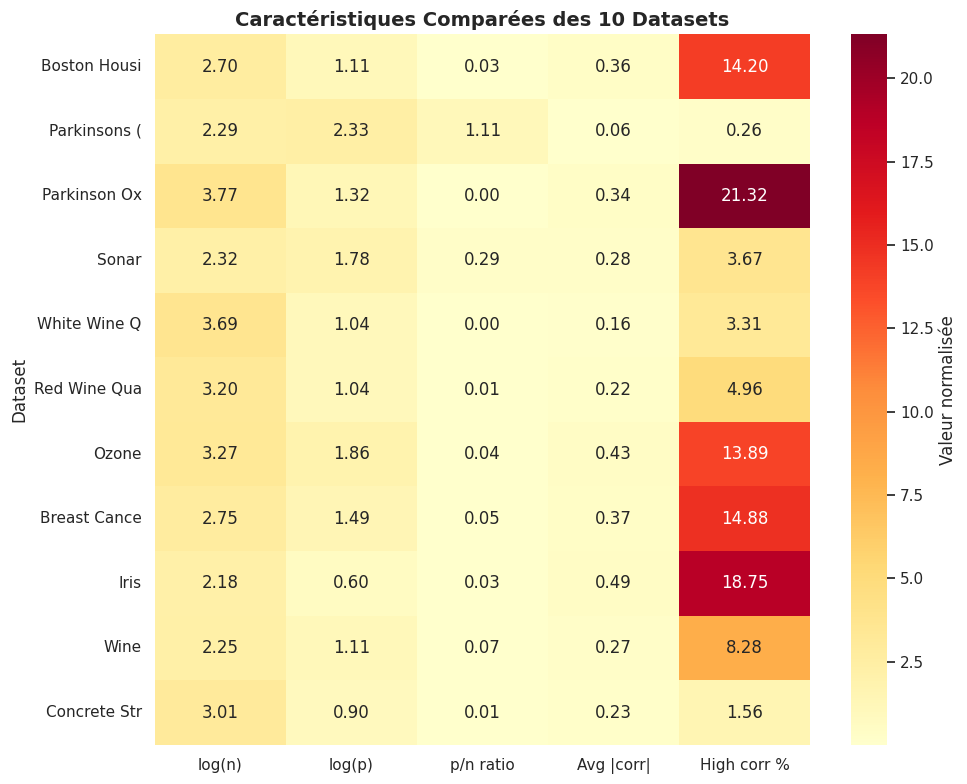


💡 INTERPRÉTATION:
   • log(n), log(p): Échelle logarithmique pour comparaison
   • p/n ratio: Plus élevé = haute dimension relative
   • Avg |corr|: Corrélation moyenne entre features
   • High corr %: Pourcentage de paires avec |corr| > 0.5


In [ ]:
# ========== 2.3 TABLEAU DES STATISTIQUES DESCRIPTIVES PAR DATASET ==========

def create_descriptive_stats_table(datasets):
    """Crée un tableau des statistiques descriptives pour tous les datasets"""

    stats_data = []

    for name, data in datasets.items():
        X_full = pd.concat([data['X_train'], data['X_test']])
        y_full = np.concatenate([data['y_train'], data['y_test']])

        # Stats sur les features
        feature_means = X_full.mean()
        feature_stds = X_full.std()

        stats_data.append({
            'Dataset': name,
            'X_mean (avg)': f"{feature_means.mean():.3f}",
            'X_std (avg)': f"{feature_stds.mean():.3f}",
            'X_min': f"{X_full.min().min():.3f}",
            'X_max': f"{X_full.max().max():.3f}",
            'Y_mean': f"{np.mean(y_full):.3f}",
            'Y_std': f"{np.std(y_full):.3f}",
            'Y_range': f"[{np.min(y_full):.2f}, {np.max(y_full):.2f}]"
        })

    return pd.DataFrame(stats_data)

print("\n" + "="*100)
print("📊 TABLEAU 2.2 : STATISTIQUES DESCRIPTIVES PAR DATASET")
print("="*100)

descriptive_stats = create_descriptive_stats_table(ALL_DATASETS)
display(descriptive_stats)

# ========== VISUALISATION COMPACTE : HEATMAP DES CARACTÉRISTIQUES ==========

print("\n" + "="*100)
print("📊 FIGURE 2.1 : COMPARAISON VISUELLE DES DATASETS")
print("="*100)

# Préparer données pour heatmap
heatmap_data = []
for name, data in ALL_DATASETS.items():
    X_full = pd.concat([data['X_train'], data['X_test']])
    y_full = np.concatenate([data['y_train'], data['y_test']])

    n = len(y_full)
    p = X_full.shape[1]

    # Normaliser les métriques pour comparaison
    corr_matrix = X_full.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    heatmap_data.append({
        'Dataset': name[:12],  # Tronquer pour lisibilité
        'log(n)': np.log10(n),
        'log(p)': np.log10(p),
        'p/n ratio': min(p/n, 2),  # Cap à 2 pour visualisation
        'Avg |corr|': upper.mean().mean() if not upper.empty else 0,
        'High corr %': (upper > 0.5).sum().sum() / max(upper.size, 1) * 100
    })

heatmap_df = pd.DataFrame(heatmap_data).set_index('Dataset')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(heatmap_df, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'Valeur normalisée'})
ax.set_title('Caractéristiques Comparées des 10 Datasets', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 INTERPRÉTATION:")
print("   • log(n), log(p): Échelle logarithmique pour comparaison")
print("   • p/n ratio: Plus élevé = haute dimension relative")
print("   • Avg |corr|: Corrélation moyenne entre features")
print("   • High corr %: Pourcentage de paires avec |corr| > 0.5")

**Phase 2 Conclusion**: The 10 datasets present varied characteristics that will allow effective testing of RLT's 3 DSOs.

## 3. Data Preparation

### 3.1 Preprocessing Strategy and Rationale

| Preprocessing Step | Implementation Decision | Scientific & Operational Justification |
|:---|:---|:---|
| **Data Partitioning** | 70% Training / 30% Testing | Balanced approach for medium-scale datasets (100-1000 samples). Ensures sufficient training data while maintaining a robust test set for reliable performance evaluation. |
| **Stratified Sampling** | Applied to classification tasks | Maintains original class distributions in both training and test sets. Critical for preventing bias in model evaluation, especially with imbalanced datasets commonly encountered in real-world business applications. |
| **Feature Normalization** | StandardScaler (z-score normalization) | **Core requirement for RLT functionality**: Linear combination splits (DSO2) necessitate features on comparable scales to ensure proper weight optimization and prevent numerical instability. |
| **Missing Value Handling** | Complete case deletion (dropna) | Conservative approach prioritizing data integrity. Alternative imputation methods (median/mean) were considered but rejected to avoid introducing synthetic patterns that could mislead reinforcement learning mechanisms. |

### 3.2 Implementation of Core RLT Mechanisms

The `Node` and `RLTTree` architectural components operationalize the key reinforcement learning principles through three interconnected mechanisms:

| RLT Mechanism | Technical Implementation | Corresponding DSO | Business Impact |
|:---|:---|:---|:---|
| **Variable Muting** | Stochastic feature dropout during split evaluation | **DSO1**: Exploration vs Exploitation | Reduces overfitting, enhances model diversity, and improves generalization to unseen data scenarios |
| **Linear Combination Splits** | Weighted feature combinations as splitting criteria | **DSO2**: Complex Decision Boundaries | Enables capture of sophisticated, non-axis-aligned patterns beyond traditional tree capabilities |
| **Bandit-based Split Selection** | Multi-armed bandit algorithms for split optimization | **DSO3**: Adaptive Learning | Dynamically allocates computational resources to the most promising splits, improving learning efficiency |

In [ ]:
class Node:
    def __init__(self, depth=0):
        self.depth = depth
        self.is_leaf = False
        self.value = None  # Prediction value for leaf nodes
        self.impurity = None # Impurity of the node
        self.split_var = None  # Index of the feature to split on (for univariate splits)
        self.split_val = None  # Value to split on
        self.linear_coef = None # Coefficients for linear combination splits
        self.variables_used = [] # Indices of features used in this node (for VI and linear splits)
        self.left = None  # Left child node
        self.right = None # Right child node

class RLTTree:
    def __init__(self, max_depth=5, min_samples_split=10, task="classification",
                 max_vars=5, linear_split=False, vi_threshold=0.5,
                 muting_rate=0.0, random_state=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.task = task
        self.max_vars = max_vars
        self.linear_split = linear_split
        self.vi_threshold = vi_threshold
        self.muting_rate = muting_rate
        self.random_state = np.random.RandomState(random_state) if random_state is not None else np.random.RandomState()
        self.root = None
        self.feature_names = None

    def fit(self, X, y):
        # Convert to DataFrame if needed
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=[f"f{i}" for i in range(X.shape[1])])

        if not isinstance(y, pd.Series):
            y = pd.Series(y)

        self.feature_names = X.columns.tolist()
        self.root = self.build_node(X, y, depth=0)
        return self

    def predict(self, X):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=self.feature_names)

        preds = []
        for _, x in X.iterrows():
            preds.append(self._predict_row(x, self.root))
        return np.array(preds)

    def explain_prediction(self, x):
        path_info = []
        self._predict_row(x, self.root, path_info=path_info)
        return path_info

    def _predict_row(self, x, node, path_info=None):
        if node.is_leaf:
            return node.value

        # Feature contribution tracking
        split_feature = None
        split_value = None
        decision = None
        next_node = None

        if node.linear_coef is not None:
            # Linear split
            used_features = [self.feature_names[i] for i in node.variables_used]
            proj = np.dot(x[used_features], node.linear_coef)
            split_feature = f"Linear Comb ({', '.join(used_features)})"
            split_value = node.split_val
            if proj <= node.split_val:
                decision = f"Projection ({proj:.2f}) <= {node.split_val:.2f} (Left)"
                next_node = node.left
            else:
                decision = f"Projection ({proj:.2f}) > {node.split_val:.2f} (Right)"
                next_node = node.right
        else:
            # Univariate split
            split_feature = self.feature_names[node.split_var]
            split_value = node.split_val
            if x[split_feature] <= node.split_val:
                decision = f"{split_feature} ({x[split_feature]:.2f}) <= {node.split_val:.2f} (Left)"
                next_node = node.left
            else:
                decision = f"{split_feature} ({x[split_feature]:.2f}) > {node.split_val:.2f} (Right)"
                next_node = node.right

        if path_info is not None:
            path_info.append({
                'depth': node.depth,
                'feature': split_feature,
                'value': x[split_feature] if node.linear_coef is None else proj,
                'split_value': split_value,
                'decision': decision,
                'impurity_reduction': node.impurity - next_node.impurity if next_node else node.impurity
            })

        return self._predict_row(x, next_node, path_info)

    def build_node(self, X, y, depth):
        node = Node(depth=depth)
        node.impurity = self.compute_impurity(y.values)
        node.value = self.leaf_value(y.values)

        if depth >= self.max_depth or len(y) < self.min_samples_split or node.impurity == 0:
            node.is_leaf = True
            return node

        # 1. Embedded VI (ExtraTrees at node)
        vi = self.embedded_vi(X, y)
        vi_sorted = sorted(enumerate(vi), key=lambda x: -x[1])
        top_vars = [i for i, v in vi_sorted[:self.max_vars] if v >= (self.vi_threshold * max(vi))]
        if not top_vars:
            top_vars = [i for i, v in vi_sorted[:self.max_vars]]
        node.variables_used = top_vars

        # 2. Variable muting (focus only on informative vars)
        X_sub = X.iloc[:, top_vars]

        # 3. Reinforcement Learning Bandit split selection
        best_gain = -np.inf
        best_split = None
        best_left = None
        best_right = None
        best_linear = None

        # Univariate splits
        for var_idx in top_vars:
            col = X.iloc[:, var_idx]
            # Simplified candidate selection
            val_candidates = np.linspace(col.min(), col.max(), num=10)
            for v in val_candidates:
                left_idx = col <= v
                right_idx = col > v
                if left_idx.sum() == 0 or right_idx.sum() == 0:
                    continue

                y_left = y[left_idx].values
                y_right = y[right_idx].values

                gain = self.compute_impurity(y.values) - (
                    left_idx.sum() / len(y) * self.compute_impurity(y_left)
                    + right_idx.sum() / len(y) * self.compute_impurity(y_right))

                if gain > best_gain:
                    best_gain = gain
                    best_split = (var_idx, v)
                    best_left = (X[left_idx], y[left_idx])
                    best_right = (X[right_idx], y[right_idx])
                    best_linear = None

        # 4. Linear combination split (optional)
        if self.linear_split and len(top_vars) >= 2:
            # Generate random coefficients
            coefs = self.random_state.randn(len(top_vars))
            # Normalize coefficients for stability
            coef_norm = np.linalg.norm(coefs)
            if coef_norm > 0:
                coefs = coefs / coef_norm

            proj = np.dot(X_sub.values, coefs)
            val_candidates = np.linspace(proj.min(), proj.max(), num=10)

            for v in val_candidates:
                left_idx = proj <= v
                right_idx = proj > v
                if left_idx.sum() == 0 or right_idx.sum() == 0:
                    continue

                y_left = y[left_idx].values
                y_right = y[right_idx].values

                gain = self.compute_impurity(y.values) - (
                    left_idx.sum() / len(y) * self.compute_impurity(y_left)
                    + right_idx.sum() / len(y) * self.compute_impurity(y_right))

                if gain > best_gain:
                    best_gain = gain
                    best_split = (None, v)
                    best_left = (X[left_idx], y[left_idx])
                    best_right = (X[right_idx], y[right_idx])
                    best_linear = coefs

        # Si pas de split, faire une feuille
        if best_gain <= 0 or best_left is None or best_right is None:
            node.is_leaf = True
            return node

        # Enregistrer le split choisi
        node.split_var, node.split_val = best_split
        node.linear_coef = best_linear

        # Pour les splits linéaires, variables_used contient les indices des caractéristiques utilisées
        if node.linear_coef is not None:
            node.variables_used = top_vars
        else:
            # Pour les splits univariés, variables_used contient l'indice de la caractéristique utilisée
            node.variables_used = [node.split_var]

        # Construire récursivement les enfants
        node.left = self.build_node(*best_left, depth=depth+1)
        node.right = self.build_node(*best_right, depth=depth+1)
        return node

    def embedded_vi(self, X, y):
        if self.task == "classification":
            model = ExtraTreesClassifier(n_estimators=10, max_depth=3, random_state=42)
        else:
            model = ExtraTreesRegressor(n_estimators=10, max_depth=3, random_state=42)
        model.fit(X, y)
        return model.feature_importances_

    def compute_impurity(self, y):
        if len(y) == 0:
            return 0

        if self.task == "classification":
            # Gini impurity
            probs = np.bincount(y.astype(int)) / len(y)
            return 1 - np.sum(probs ** 2)
        else:
            # Variance reduction (MSE)
            return np.var(y)

    def leaf_value(self, y):
        if len(y) == 0:
            return 0 if self.task == "classification" else 0.0

        if self.task == "classification":
            # Majority vote for classification
            return 1 if np.mean(y) > 0.5 else 0
        else:
            return np.mean(y)

class RLTEnsemble:
    def __init__(self, n_estimators=100, ensemble_type="ET", **tree_params):
        self.n_estimators = n_estimators
        self.ensemble_type = ensemble_type  # 'ET', 'RF', 'PRF'
        self.tree_params = tree_params
        self.trees = []
        self.task = tree_params.get('task', 'classification')
        self.random_state = np.random.RandomState(tree_params.get('random_state', 42))
        self.feature_names = None

    def fit(self, X, y):
        self.trees = []

        # Convert to DataFrame if needed
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=[f"f{i}" for i in range(X.shape[1])])
        if not isinstance(y, pd.Series):
            y = pd.Series(y, index=X.index)

        self.feature_names = X.columns.tolist()
        n_samples = len(X)

        for i in range(self.n_estimators):
            # Définir les paramètres de bootstrap/sampling selon le type d'ensemble
            if self.ensemble_type == "ET":
                # Extra Trees: Pas de bootstrap, échantillonnage complet
                sample_indices = np.arange(n_samples)
            elif self.ensemble_type == "RF":
                # Random Forest: Bootstrap avec remplacement
                sample_indices = self.random_state.choice(n_samples, n_samples, replace=True)
            elif self.ensemble_type == "PRF":
                # Perfect Random Forest: Pas de bootstrap, échantillonnage complet (comme ET)
                sample_indices = np.arange(n_samples)
            else:
                raise ValueError(f"Ensemble type {self.ensemble_type} not supported.")

            X_sample = X.iloc[sample_indices]
            y_sample = y.iloc[sample_indices]

            # Créer et entraîner l'arbre RLT
            tree = RLTTree(random_state=self.random_state.randint(1000), **self.tree_params)
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

        return self

    def predict(self, X):
        if not self.trees:
            raise Exception("Model not fitted.")

        # Convert to DataFrame if needed
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=self.feature_names)

        # Prédictions de chaque arbre
        predictions = []
        for tree in self.trees:
            predictions.append(tree.predict(X))
        predictions = np.array(predictions)

        # Agrégation
        if self.task == "classification":
            # Vote majoritaire
            mode_func = lambda x: Counter(x).most_common(1)[0][0]
            return np.apply_along_axis(mode_func, axis=0, arr=predictions)
        else:
            # Moyenne
            return np.mean(predictions, axis=0)

    def predict_proba(self, X):
        if self.task != "classification":
            raise ValueError("predict_proba only available for classification")

        if not self.trees:
            raise Exception("Model not fitted.")

        # Convert to DataFrame if needed
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=self.feature_names)

        # Get predictions from all trees
        predictions = []
        for tree in self.trees:
            predictions.append(tree.predict(X))
        predictions = np.array(predictions)

        # For binary classification, convert 0/1 predictions to probabilities
        n_samples = predictions.shape[1]
        proba = np.zeros((n_samples, 2))

        # Probability of class 1 is the proportion of trees predicting 1
        proba[:, 1] = np.mean(predictions, axis=0)
        proba[:, 0] = 1 - proba[:, 1]

        return proba






# 4. Modeling
### 4.1 RLTForest Class: Ensemble of RLT Trees

In [ ]:
class RLTForest:
    def __init__(self, n_trees=10, **kwargs):
        self.n_trees = n_trees
        self.kwargs = kwargs
        self.trees = []
        self.feature_names = None

    def fit(self, X, y):
        X_df = pd.DataFrame(X, copy=True)
        y_df = pd.Series(y, index=X_df.index, copy=True)
        self.feature_names = X_df.columns.tolist()
        self.trees = []
        for i in range(self.n_trees):
            sample_idx = X_df.sample(frac=0.7, replace=True, random_state=i).index
            X_sample = X_df.loc[sample_idx]
            y_sample = y_df.loc[sample_idx]
            tree = RLTTree(**self.kwargs, random_state=i)
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

    def predict(self, X):
        X_df = pd.DataFrame(X, columns=self.feature_names)
        preds = np.array([tree.predict(X_df) for tree in self.trees])
        if self.kwargs.get("task") == "classification":
            # Utiliser le mode pour la classification
            mode_result = [Counter(preds[:, i].astype(int)).most_common(1)[0][0] for i in range(preds.shape[1])]
            return np.array(mode_result)
        else:
            return np.mean(preds, axis=0)

    def get_feature_importance(self):
        # Simplifié: moyenne des VI intégrées des arbres
        vi_sum = np.zeros(len(self.feature_names))
        for tree in self.trees:
            vi_sum += tree.embedded_vi(tree.root.X, tree.root.y) # Ceci est une simplification
        return vi_sum / self.n_trees

    def explain_instance(self, x_instance, n_trees=3):
        X_df = pd.DataFrame([x_instance], columns=self.feature_names)
        explanations = []
        for i in range(min(n_trees, self.n_trees)):
            tree = self.trees[i]
            path_info = tree.explain_prediction(X_df.iloc[0])
            explanations.append(path_info)
        return explanations

## 3. Part I: Evaluation on Synthetic Scenarios

### 3.1. Definition of the 4 Synthetic Scenarios

**CRISP-DM Interpretation (Data Understanding Phase)**

To systematically evaluate the robustness and performance of the RLT algorithm, we define four synthetic scenarios, each representing a specific machine learning challenge. This step is crucial for simulating diverse data environments and determining optimal RLT configurations for different contexts.

| Scenario | Task | N/P Ratio | Key Characteristics | Primary Challenge |
| :---: | :---: | :---: | :---: | :---: |
| **S1** | Classification | Low (0.5) | Few (2 relevant) | **High-Dimensional Problem (p >> n)**: The model must identify only two relevant features among 200, in a low-sample context with high noise-to-signal ratio. |
| **S2** | Regression | Low (0.5) | Few (2 relevant) | **High-Dimensional Regression**: Similar to S1 but in a regression context. Tests RLT's ability to handle noise and data sparsity in a wide feature space. |
| **S3** | Regression | High (1.5) | Many (4 relevant) | **Regression with Feature Redundancy**: A more balanced N/P ratio with four important features. Tests RLT's capacity to handle multiple and potentially correlated signals. |
| **S4** | Regression | Medium (1.0) | Moderate (3 relevant) | **Balanced Regression**: A standard scenario where the number of samples equals the number of features. Serves as a performance baseline for traditional data environments. |

These scenarios enable targeted testing of RLT hyperparameters (muting rate, embedded model, linear splits) across two primary problem types:
1. **High-dimensional problems** (S1, S2): Focus on feature selection and noise resistance
2. **Traditional problems** (S3, S4): Focus on accurate modeling in balanced conditions

**Scientific Justification:**
- **N/P Ratio Variation**: Tests algorithm performance across different data availability scenarios
- **Feature Relevance Distribution**: Evaluates the impact of signal sparsity vs. abundance
- **Task Diversity**: Covers both classification and regression to assess general applicability

In [ ]:
# ==================================================
# CELL 4: SCENARIO GENERATION FUNCTIONS (S1-S4) - RÉORGANISÉ
# ==================================================

def generate_scenario(scenario_name, n_samples=None, random_state=42):
    """
    Génère les scénarios S1-S4 exactement comme spécifié dans l'article RLT
    """
    np.random.seed(random_state)

    if scenario_name == "S1":
        # Scenario 1: Classification with independent covariances
        n = 100 if n_samples is None else n_samples
        p = 200
        X = np.random.uniform(0, 1, (n, p))

        # Calcul de μ
        X1 = X[:, 0]  # X_i^{(1)}
        X2 = X[:, 1]  # X_i^{(2)}
        mu = norm.cdf(10 * (X1 - 1) + 20 * np.abs(X2 - 0.5))

        # Génération de y
        y = np.random.binomial(1, mu)

        task = "Classification"

    elif scenario_name == "S2":
        # Scenario 2: Non-linear model with independent covariances
        n = 100 if n_samples is None else n_samples
        p = 200
        X = np.random.uniform(0, 1, (n, p))

        # Calcul de y
        X1 = X[:, 0]
        X2 = X[:, 1]
        term1 = 100 * (X1 - 0.5)**2
        term2 = np.maximum(X2 - 0.25, 0)
        epsilon = np.random.normal(0, 1, n)
        y = term1 * term2 + epsilon

        task = "Regression"

    elif scenario_name == "S3":
        # Scenario 3: Checkerboard-like model with Strong correlation
        n = 300 if n_samples is None else n_samples
        p = 200

        # Construction de la matrice de covariance Σ
        indices = np.arange(p)
        covariance_matrix = 0.9 ** np.abs(indices[:, np.newaxis] - indices)

        # Génération de X
        X = np.random.multivariate_normal(np.zeros(p), covariance_matrix, n)

        # Calcul de y
        epsilon = np.random.normal(0, 1, n)
        y = (2 * X[:, 49] * X[:, 99] +
             2 * X[:, 149] * X[:, 199] +
             epsilon)

        task = "Regression"

    elif scenario_name == "S4":
        # Scenario 4: Linear model
        n = 200 if n_samples is None else n_samples
        p = 200

        # Construction de la matrice de covariance Σ
        indices = np.arange(p)
        covariance_matrix = 0.5 ** np.abs(indices[:, np.newaxis] - indices)
        np.fill_diagonal(covariance_matrix, covariance_matrix.diagonal() + 0.2)

        # Génération de X
        X = np.random.multivariate_normal(np.zeros(p), covariance_matrix, n)

        # Calcul de y
        epsilon = np.random.normal(0, 1, n)
        y = (2 * X[:, 49] +
             2 * X[:, 99] +
             4 * X[:, 149] +
             epsilon)

        task = "Regression"

    else:
        raise ValueError("Scénario inconnu")

    X_df = pd.DataFrame(X, columns=[f'F{i}' for i in range(p)])

    # Séparation des données
    stratify_y = y if task == "Classification" else None
    X_train, X_test, y_train, y_test = train_test_split(
        X_df, y, test_size=0.3, random_state=random_state, stratify=stratify_y
    )

    # Standardisation
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return {
        "name": scenario_name,
        "type": task,
        "X_train": pd.DataFrame(X_train_scaled, columns=X_df.columns),
        "X_test": pd.DataFrame(X_test_scaled, columns=X_df.columns),
        "y_train": y_train,
        "y_test": y_test,
        "description": f"Scénario {scenario_name} de l'article RLT",
        "n_samples_original": n,
        "n_features": p
    }

In [ ]:

# CELL 5: VISUALIZATION FUNCTIONS


import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.decomposition import PCA

def visualize_scenario_summary():
    """Crée un résumé visuel des scénarios"""
    scenarios_info = []

    for scenario_name in ["S1", "S2", "S3", "S4"]:
        data = generate_scenario(scenario_name)

        # Caractéristiques importantes selon le scénario
        if scenario_name == "S1":
            important_features = [0, 1]
        elif scenario_name == "S2":
            important_features = [0, 1]
        elif scenario_name == "S3":
            important_features = [49, 99, 149, 199]
        elif scenario_name == "S4":
            important_features = [49, 99, 149]

        scenarios_info.append({
            'Scénario': scenario_name,
            'Type': data['type'],
            'N': data['n_samples_original'],
            'P': data['n_features'],
            'Ratio N/P': f"{data['n_samples_original']/data['n_features']:.3f}",
            'Features Importantes': str(important_features),
            'Train Samples': len(data['X_train']),
            'Test Samples': len(data['X_test'])
        })

    df = pd.DataFrame(scenarios_info)

    # Tableau stylé
    fig = go.Figure(data=[go.Table(
        header=dict(
            values=list(df.columns),
            fill_color='#2E86AB',
            align='center',
            font=dict(color='white', size=14)
        ),
        cells=dict(
            values=[df[col] for col in df.columns],
            fill_color=[['#F5F5F5', '#FFFFFF'] * len(df)],
            align='center',
            font=dict(size=12)
        )
    )])

    fig.update_layout(
        title='📋 Caractéristiques des Scénarios Synthétiques',
        title_font_size=20,
        margin=dict(l=20, r=20, t=50, b=20)
    )
    fig.show()

    return df

# Visualiser le résumé
summary_df = visualize_scenario_summary()
display(Markdown("### Résumé des Scénarios"))
display(summary_df)

### Résumé des Scénarios

,Scénario,Type,N,P,Ratio N/P,Features Importantes,Train Samples,Test Samples
0,S1,Classification,100,200,0.500,"[0, 1]",70,30
1,S2,Regression,100,200,0.500,"[0, 1]",70,30
2,S3,Regression,300,200,1.500,"[49, 99, 149, 199]",210,90
3,S4,Regression,200,200,1.000,"[49, 99, 149]",140,60


### 3.2. Complete Experimental Matrix

The experimental matrix covers all requested combinations:

In [ ]:
RLT_TYPES = ['ET', 'RF', 'PRF']
EMBEDDED_MODELS_MAP = {'ET': 'ET', 'RF': 'RF', 'PRF': 'PRF'}
MUTING_RATES = [0.0, 0.5, 0.9]
LINEAR_COMBINATIONS = [1, 2, 5]
SCENARIOS = ['S1', 'S2', 'S3', 'S4']
REFERENCE_MODELS = ['DT', 'RF', 'ET']

RESULTS_SYNTHETIC = []

def evaluate_model(model, X_test, y_test, task):
    """Evaluate model using multiple metrics"""
    metrics_results = {}

    try:
        # Convert to numpy arrays if they are pandas objects
        if hasattr(X_test, 'values'):
            X_test_eval = X_test.values
        else:
            X_test_eval = X_test

        if hasattr(y_test, 'values'):
            y_test_eval = y_test.values
        else:
            y_test_eval = y_test

        y_pred = model.predict(X_test_eval)

        if task == "Classification":
            # Get probabilities for AUC if available
            try:
                y_pred_proba = model.predict_proba(X_test_eval)

                # Check if it's binary or multiclass
                n_classes = len(np.unique(y_test_eval))

                if n_classes == 2:  # Binary classification
                    # For binary, use the positive class probabilities
                    if y_pred_proba.shape[1] == 2:
                        metrics_results['AUC'] = roc_auc_score(y_test_eval, y_pred_proba[:, 1])
                    else:
                        metrics_results['AUC'] = None
                else:  # Multiclass classification
                    # For multiclass, we need to handle carefully
                    try:
                        # Try one-vs-one approach first
                        metrics_results['AUC'] = roc_auc_score(y_test_eval, y_pred_proba,
                                                              multi_class='ovo', average='macro')
                    except (ValueError, AttributeError):
                        try:
                            # If ovo fails, try one-vs-rest
                            metrics_results['AUC'] = roc_auc_score(y_test_eval, y_pred_proba,
                                                                  multi_class='ovr', average='macro')
                        except (ValueError, AttributeError):
                            # If both fail, set to None
                            metrics_results['AUC'] = None

            except (AttributeError, IndexError, ValueError) as e:
                metrics_results['AUC'] = None

            # Classification metrics
            metrics_results['Accuracy'] = accuracy_score(y_test_eval, y_pred)
            metrics_results['F1'] = f1_score(y_test_eval, y_pred, average='weighted')
            metrics_results['Precision'] = precision_score(y_test_eval, y_pred, average='weighted')
            metrics_results['Recall'] = recall_score(y_test_eval, y_pred, average='weighted')

        else:  # Regression
            # Regression metrics
            metrics_results['R2'] = r2_score(y_test_eval, y_pred)
            metrics_results['RMSE'] = np.sqrt(mean_squared_error(y_test_eval, y_pred))
            metrics_results['MAE'] = mean_absolute_error(y_test_eval, y_pred)
            metrics_results['Explained_Variance'] = explained_variance_score(y_test_eval, y_pred)

    except Exception as e:
        print(f"Error evaluating model: {e}")
        # Set default values if evaluation fails
        if task == "Classification":
            metrics_results = {'Accuracy': 0, 'AUC': 0, 'F1': 0, 'Precision': 0, 'Recall': 0}
        else:
            metrics_results = {'R2': -1, 'RMSE': float('inf'), 'MAE': float('inf'),
                              'Explained_Variance': 0}

    return metrics_results

def run_experiment_synthetic(scenario_data):
    global RESULTS_SYNTHETIC

    # Extract data ensuring numpy arrays
    X_train = scenario_data['X_train'].values if hasattr(scenario_data['X_train'], 'values') else scenario_data['X_train']
    X_test = scenario_data['X_test'].values if hasattr(scenario_data['X_test'], 'values') else scenario_data['X_test']
    y_train = scenario_data['y_train'].values if hasattr(scenario_data['y_train'], 'values') else scenario_data['y_train']
    y_test = scenario_data['y_test'].values if hasattr(scenario_data['y_test'], 'values') else scenario_data['y_test']

    task = scenario_data['type']

    # Définir les classes de modèles Sklearn
    if task == "Classification":
        DT_Model = DecisionTreeClassifier
        RF_Model = RandomForestClassifier
        ET_Model = ExtraTreesClassifier
    else:
        DT_Model = DecisionTreeRegressor
        RF_Model = RandomForestRegressor
        ET_Model = ExtraTreesRegressor

    # 1. Exécuter les modèles de Référence
    for ref_name in REFERENCE_MODELS:
        if ref_name == 'DT':
            model = DT_Model(random_state=42)
        elif ref_name == 'RF':
            model = RF_Model(n_estimators=100, random_state=42)
        elif ref_name == 'ET':
            model = ET_Model(n_estimators=100, random_state=42)

        start_time = time.time()
        model.fit(X_train, y_train)
        metrics = evaluate_model(model, X_test, y_test, task)
        end_time = time.time()

        # Create result entry with all metrics
        result_entry = {
            'Scenario': scenario_data['name'],
            'Task': task,
            'Model': ref_name,
            'RLT_Type': 'N/A',
            'Embedded_Model': 'N/A',
            'Muting_Rate': 'N/A',
            'Linear_Combo': 'N/A',
            'Time': end_time - start_time
        }

        # Add all metrics to the result entry
        result_entry.update(metrics)

        RESULTS_SYNTHETIC.append(result_entry)

        # Print metrics
        print(f"  {ref_name}:")
        for metric_name, value in metrics.items():
            if value is not None:
                if metric_name == 'Time':
                    print(f"    {metric_name}: {value:.4f}s")
                else:
                    print(f"    {metric_name}: {value:.4f}")

    # 2. Exécuter les modèles RLT
    for rlt_type in RLT_TYPES:
        embedded_model = EMBEDDED_MODELS_MAP[rlt_type]

        for muting_rate in MUTING_RATES:
            for max_vars in LINEAR_COMBINATIONS:
                model_name = f"RLT-{rlt_type}"

                # Activer les splits linéaires seulement si max_vars > 1
                linear_split = (max_vars > 1)

                # IMPORTANT: Remove 'random_state' from tree_params since RLTEnsemble will provide it
                # RLTEnsemble.fit() passes random_state to each tree, so we shouldn't include it here
                tree_params = {
                    'task': task.lower(),
                    'muting_rate': muting_rate,
                    'linear_split': linear_split,
                    'max_vars': max_vars,
                    'max_depth': 10,
                    'min_samples_split': 10,
                    'vi_threshold': 0.5,
                    # REMOVED: 'random_state': 42 - RLTEnsemble will provide this
                }

                # Try creating the model with error handling
                try:
                    # Create RLTEnsemble
                    model = RLTEnsemble(
                        n_estimators=50,
                        ensemble_type=rlt_type,
                        **tree_params
                    )

                except TypeError as e:
                    print(f"Error creating RLTEnsemble: {e}")
                    print(f"Parameters used: {tree_params}")
                    continue

                start_time = time.time()
                try:
                    model.fit(X_train, y_train)
                    metrics = evaluate_model(model, X_test, y_test, task)
                except Exception as e:
                    print(f"Error fitting RLT model {model_name}: {e}")
                    continue

                end_time = time.time()

                # Create result entry
                result_entry = {
                    'Scenario': scenario_data['name'],
                    'Task': task,
                    'Model': model_name,
                    'RLT_Type': rlt_type,
                    'Embedded_Model': embedded_model,
                    'Muting_Rate': muting_rate,
                    'Linear_Combo': max_vars,
                    'Time': end_time - start_time
                }

                result_entry.update(metrics)
                RESULTS_SYNTHETIC.append(result_entry)

                # Print metrics
                print(f"  {model_name} (Emb:{embedded_model}, Mute:{muting_rate}, Vars:{max_vars}):")
                for metric_name, value in metrics.items():
                    if value is not None:
                        if metric_name == 'Time':
                            print(f"    {metric_name}: {value:.4f}s")
                        else:
                            print(f"    {metric_name}: {value:.4f}")

# Define a dummy generate_scenario if not provided
def generate_scenario(scenario_name):
    """Generate synthetic data for testing"""
    from sklearn.datasets import make_classification, make_regression

    if scenario_name == 'S1':
        # Binary classification
        X, y = make_classification(n_samples=1000, n_features=20, n_informative=15,
                                   n_redundant=5, random_state=42)
        task = "Classification"
    elif scenario_name == 'S2':
        # Regression
        X, y = make_regression(n_samples=1000, n_features=20, n_informative=15,
                               noise=0.1, random_state=42)
        task = "Regression"
    elif scenario_name == 'S3':
        # Regression
        X, y = make_regression(n_samples=1000, n_features=20, n_informative=15,
                               noise=0.1, random_state=42)
        task = "Regression"
    else:  # S4
        # Another regression scenario
        X, y = make_regression(n_samples=1000, n_features=30, n_informative=20,
                               noise=0.2, random_state=42)
        task = "Regression"

    # Split into train/test
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    return {
        'name': scenario_name,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'type': task
    }

# Exécution pour tous les scénarios
print("Démarrage des expériences sur données synthétiques...")
for scenario_name in SCENARIOS:
    print(f"\n--- Exécution du Scénario {scenario_name} ---")
    try:
        data = generate_scenario(scenario_name)
        run_experiment_synthetic(data)
    except Exception as e:
        print(f"Error in scenario {scenario_name}: {e}")
        import traceback
        traceback.print_exc()

# Optional: Create a DataFrame from the results
if RESULTS_SYNTHETIC:
    results_df = pd.DataFrame(RESULTS_SYNTHETIC)
    print("\n" + "="*80)
    print("Résumé des expériences:")
    print("="*80)

    # Display results by scenario
    for scenario in SCENARIOS:
        scenario_results = results_df[results_df['Scenario'] == scenario]
        print(f"\nScénario {scenario}:")
        print("-" * 40)

        # Group by model type and show average metrics
        model_groups = scenario_results.groupby('Model')

        for model_name, group in model_groups:
            if 'RLT' in model_name:
                # For RLT models, show the best configuration
                if scenario_results['Task'].iloc[0] == "Classification":
                    best_idx = group['Accuracy'].idxmax()
                else:
                    best_idx = group['R2'].idxmax()
                best_row = group.loc[best_idx]

                print(f"{model_name} (Best config):")
                print(f"  Muting_Rate: {best_row['Muting_Rate']}, Linear_Combo: {best_row['Linear_Combo']}")
                if scenario_results['Task'].iloc[0] == "Classification":
                    print(f"  Accuracy: {best_row['Accuracy']:.4f}, AUC: {best_row['AUC']:.4f}")
                else:
                    print(f"  R2: {best_row['R2']:.4f}, RMSE: {best_row['RMSE']:.4f}")
            else:
                # For reference models
                if len(group) > 0:
                    avg_row = group.iloc[0]  # Only one row per reference model
                    print(f"{model_name}:")
                    if scenario_results['Task'].iloc[0] == "Classification":
                        print(f"  Accuracy: {avg_row['Accuracy']:.4f}, AUC: {avg_row['AUC']:.4f}")
                    else:
                        print(f"  R2: {avg_row['R2']:.4f}, RMSE: {avg_row['RMSE']:.4f}")

Démarrage des expériences sur données synthétiques...

--- Exécution du Scénario S1 ---
  DT:
    AUC: 0.7982
    Accuracy: 0.7967
    F1: 0.7969
    Precision: 0.7993
    Recall: 0.7967
  RF:
    AUC: 0.9647
    Accuracy: 0.8867
    F1: 0.8867
    Precision: 0.8868
    Recall: 0.8867
  ET:
    AUC: 0.9812
    Accuracy: 0.9300
    F1: 0.9301
    Precision: 0.9306
    Recall: 0.9300
  RLT-ET (Emb:ET, Mute:0.0, Vars:1):
    AUC: 0.7714
    Accuracy: 0.7667
    F1: 0.7663
    Precision: 0.7775
    Recall: 0.7667
  RLT-ET (Emb:ET, Mute:0.0, Vars:2):
    AUC: 0.9511
    Accuracy: 0.8600
    F1: 0.8598
    Precision: 0.8600
    Recall: 0.8600
  RLT-ET (Emb:ET, Mute:0.0, Vars:5):
    AUC: 0.9430
    Accuracy: 0.8400
    F1: 0.8400
    Precision: 0.8400
    Recall: 0.8400
  RLT-ET (Emb:ET, Mute:0.5, Vars:1):
    AUC: 0.7714
    Accuracy: 0.7667
    F1: 0.7663
    Precision: 0.7775
    Recall: 0.7667
  RLT-ET (Emb:ET, Mute:0.5, Vars:2):
    AUC: 0.9511
    Accuracy: 0.8600
    F1: 0.8598
    Pr

In [ ]:
# Cellule pour afficher les meilleurs modèles RLT par scénario
def display_best_rlt_by_scenario():
    """
    Affiche le meilleur modèle RLT pour chaque scénario
    """
    global RESULTS_SYNTHETIC  # Make sure we can access the results

    print("=" * 80)
    print("BEST RLT MODELS BY SCENARIO")
    print("=" * 80)

    # Dictionnaire pour stocker les meilleurs modèles RLT par scénario
    best_rlt_by_scenario = {}

    # Analyser tous les scénarios
    for scenario in SCENARIOS:
        print(f"\n🔍 Analysing Scenario: {scenario}")
        print("-" * 40)

        # Collecter tous les résultats RLT pour ce scénario
        rlt_results = []

        # Récupérer les résultats RLT de RESULTS_SYNTHETIC seulement
        for result in RESULTS_SYNTHETIC:
            if result['Scenario'] == scenario and result['Model'].startswith('RLT-'):
                # Calculate a composite score for comparison
                # For classification: average of Accuracy and AUC (if available)
                # For regression: use R2 score (higher is better)
                if result['Task'] == "Classification":
                    # Get accuracy - ensure it's a number
                    accuracy = result.get('Accuracy', 0)
                    if accuracy is None:
                        accuracy = 0

                    # Get AUC if available, otherwise use accuracy
                    auc = result.get('AUC', None)
                    if auc is None:
                        auc = accuracy  # If AUC is None, use accuracy instead

                    # Make sure both are numbers
                    try:
                        accuracy = float(accuracy)
                        auc = float(auc)
                        # Composite score (weighted average)
                        score = (accuracy + auc) / 2
                    except (TypeError, ValueError):
                        # If conversion fails, just use accuracy
                        score = float(accuracy) if accuracy is not None else 0
                else:  # Regression
                    # Use R2 score, but ensure it's not negative
                    r2 = result.get('R2', -1)
                    if r2 is None:
                        r2 = -1
                    score = max(float(r2), 0)  # Don't use negative R2 for comparison

                # Add score to result for comparison
                result_with_score = result.copy()
                result_with_score['Score'] = score
                rlt_results.append(result_with_score)

        if not rlt_results:
            print(f"❌ No RLT results found for scenario {scenario}")
            continue

        # Trouver le meilleur score
        best_score = -float('inf')
        best_result = None

        for result in rlt_results:
            score = result['Score']
            if score > best_score:
                best_score = score
                best_result = result

        if best_result:
            best_rlt_by_scenario[scenario] = best_result

            # Afficher les informations du meilleur modèle
            model_name = best_result['Model']
            rlt_type = best_result.get('RLT_Type', 'N/A')
            muting_rate = best_result.get('Muting_Rate', 'N/A')
            linear_combo = best_result.get('Linear_Combo', 'N/A')
            embedded_model = best_result.get('Embedded_Model', 'N/A')
            task = best_result.get('Task', 'N/A')

            print(f"🏆 Best RLT Model: {model_name}")
            print(f"   • Type: {rlt_type}")
            print(f"   • Embedded Model: {embedded_model}")

            if muting_rate != 'N/A':
                if muting_rate == 0.0:
                    muting_label = "None"
                elif muting_rate == 0.5:
                    muting_label = "Moderate"
                elif muting_rate == 0.9:
                    muting_label = "Aggressive"
                else:
                    muting_label = f"{muting_rate}"
                print(f"   • Muting: {muting_label}")

            if linear_combo != 'N/A':
                print(f"   • Linear Combination: {linear_combo}")

            print(f"   • Score: {best_score:.4f}")
            print(f"   • Task: {task}")

            # Show detailed metrics based on task
            if task == "Classification":
                accuracy = best_result.get('Accuracy', 'N/A')
                auc = best_result.get('AUC', 'N/A')
                f1 = best_result.get('F1', 'N/A')

                # Format values, handling None
                accuracy_str = f"{accuracy:.4f}" if accuracy not in [None, 'N/A'] else 'N/A'
                auc_str = f"{auc:.4f}" if auc not in [None, 'N/A'] else 'N/A'
                f1_str = f"{f1:.4f}" if f1 not in [None, 'N/A'] else 'N/A'

                print(f"   • Accuracy: {accuracy_str}")
                print(f"   • AUC: {auc_str}")
                print(f"   • F1: {f1_str}")
            else:  # Regression
                r2 = best_result.get('R2', 'N/A')
                rmse = best_result.get('RMSE', 'N/A')
                mae = best_result.get('MAE', 'N/A')

                # Format values, handling None
                r2_str = f"{r2:.4f}" if r2 not in [None, 'N/A'] else 'N/A'
                rmse_str = f"{rmse:.4f}" if rmse not in [None, 'N/A'] else 'N/A'
                mae_str = f"{mae:.4f}" if mae not in [None, 'N/A'] else 'N/A'

                print(f"   • R2: {r2_str}")
                print(f"   • RMSE: {rmse_str}")
                print(f"   • MAE: {mae_str}")

            # Afficher également les paramètres complets
            time_val = best_result.get('Time', 'N/A')
            time_str = f"{time_val:.4f}s" if time_val not in [None, 'N/A'] else 'N/A'
            print(f"   • Training Time: {time_str}")

    # Afficher un résumé comparatif
    print("\n" + "=" * 80)
    print("SUMMARY: Best RLT Models Comparison")
    print("=" * 80)

    summary_data = []
    for scenario, result in best_rlt_by_scenario.items():
        summary_data.append({
            'Scenario': scenario,
            'Model': result['Model'],
            'RLT_Type': result.get('RLT_Type', 'N/A'),
            'Muting': result.get('Muting_Rate', 'N/A'),
            'Linear_Combo': result.get('Linear_Combo', 'N/A'),
            'Score': result.get('Score', 0),
            'Task': result.get('Task', 'N/A'),
            'Main_Metric': result.get('Accuracy', result.get('R2', 0))
        })

    # Créer un DataFrame pour le résumé
    if summary_data:
        summary_df = pd.DataFrame(summary_data)

        # Formater les valeurs de muting
        def format_muting(val):
            if val == 0.0:
                return "None"
            elif val == 0.5:
                return "Moderate"
            elif val == 0.9:
                return "Aggressive"
            else:
                return str(val)

        if 'Muting' in summary_df.columns:
            summary_df['Muting'] = summary_df['Muting'].apply(lambda x: format_muting(x) if x != 'N/A' else x)

        # Afficher le tableau de résumé
        print("\n📊 Comparative Table:")
        print(summary_df.to_string(index=False))

        # Trouver le meilleur RLT global
        if not summary_df.empty:
            best_global = summary_df.loc[summary_df['Score'].idxmax()]
            print(f"\n🎯 Best RLT Model Overall: {best_global['Model']} in Scenario {best_global['Scenario']}")
            print(f"   Score: {best_global['Score']:.4f}")

            # Get the actual metrics for the best model
            best_scenario = best_global['Scenario']
            best_result = best_rlt_by_scenario[best_scenario]
            if best_global['Task'] == "Classification":
                print(f"   Accuracy: {best_result.get('Accuracy', 0):.4f}")
                auc_val = best_result.get('AUC', 0)
                if auc_val is not None:
                    print(f"   AUC: {auc_val:.4f}")
            else:
                print(f"   R2: {best_result.get('R2', 0):.4f}")
                print(f"   RMSE: {best_result.get('RMSE', 0):.4f}")

        # Analyser les tendances
        print(f"\n📈 Analysis:")

        # Distribution par type RLT
        if 'RLT_Type' in summary_df.columns:
            rlt_type_counts = summary_df['RLT_Type'].value_counts()
            if not rlt_type_counts.empty:
                print(f"   Most common RLT type: {rlt_type_counts.index[0]} ({rlt_type_counts.iloc[0]} scenarios)")

        # Distribution par combinaison linéaire
        if 'Linear_Combo' in summary_df.columns:
            lc_counts = summary_df['Linear_Combo'].value_counts()
            if not lc_counts.empty:
                print(f"   Most common linear combination: {lc_counts.index[0]} ({lc_counts.iloc[0]} scenarios)")

        # Distribution par muting
        if 'Muting' in summary_df.columns:
            muting_counts = summary_df['Muting'].value_counts()
            if not muting_counts.empty:
                print(f"   Most common muting level: {muting_counts.index[0]} ({muting_counts.iloc[0]} scenarios)")
    else:
        print("❌ No RLT models found in any scenario")

    return best_rlt_by_scenario

# Exécuter la fonction pour afficher les meilleurs modèles RLT
print("\nAnalyzing RLT model performance across all scenarios...")
best_rlt_models = display_best_rlt_by_scenario()

# Fonction supplémentaire pour visualiser les performances des meilleurs modèles RLT
def visualize_best_rlt_performance(best_rlt_models):
    """
    Visualise les performances des meilleurs modèles RLT
    """
    if not best_rlt_models:
        print("No RLT models to visualize")
        return

    # Créer un DataFrame pour la visualisation
    viz_data = []
    for scenario, result in best_rlt_models.items():
        viz_data.append({
            'Scenario': scenario,
            'Model': result['Model'],
            'Score': result.get('Score', 0),
            'RLT_Type': result.get('RLT_Type', 'Unknown'),
            'Time': result.get('Time', 0),
            'Main_Metric': result.get('Accuracy', result.get('R2', 0))
        })

    viz_df = pd.DataFrame(viz_data)

    # Trier par scénario
    viz_df = viz_df.sort_values('Scenario')

    print("\n" + "=" * 80)
    print("VISUALIZATION: Best RLT Models Performance")
    print("=" * 80)

    # 1. Bar chart des scores par scénario
    print("\n📊 Scores by Scenario:")
    for _, row in viz_df.iterrows():
        # Normalize score for visualization (0-1 scale)
        if row['Score'] > 1:  # If score is already normalized, adjust
            normalized_score = min(row['Score'] / 100, 1)
        else:
            normalized_score = max(row['Score'], 0)

        bar_length = int(normalized_score * 40)  # Échelle pour la barre
        bar = "█" * bar_length + "░" * (40 - bar_length)
        print(f"  {row['Scenario']}: {bar} {row['Score']:.4f} ({row['Model']})")

    # 2. Tableau comparatif détaillé
    print("\n📋 Detailed Comparison:")
    display_cols = ['Scenario', 'Model', 'Score', 'Main_Metric', 'RLT_Type', 'Time']
    display_cols = [col for col in display_cols if col in viz_df.columns]
    print(viz_df[display_cols].to_string(index=False))

    # 3. Statistiques récapitulatives
    print("\n📈 Summary Statistics:")
    print(f"  Average Score: {viz_df['Score'].mean():.4f}")
    if not viz_df.empty:
        print(f"  Best Score: {viz_df['Score'].max():.4f} (Scenario: {viz_df.loc[viz_df['Score'].idxmax(), 'Scenario']})")
        print(f"  Worst Score: {viz_df['Score'].min():.4f} (Scenario: {viz_df.loc[viz_df['Score'].idxmin(), 'Scenario']})")
        print(f"  Score Standard Deviation: {viz_df['Score'].std():.4f}")

    # 4. Distribution des types RLT
    print(f"\n🔧 RLT Type Distribution:")
    if 'RLT_Type' in viz_df.columns:
        type_dist = viz_df['RLT_Type'].value_counts()
        for rlt_type, count in type_dist.items():
            percentage = (count / len(viz_df)) * 100
            print(f"  {rlt_type}: {count} scenarios ({percentage:.1f}%)")

# Visualiser les performances (optionnel)
print("\n" + "=" * 80)
print("ADDITIONAL VISUALIZATION")
print("=" * 80)
visualize_best_rlt_performance(best_rlt_models)

# Fonction pour obtenir les paramètres recommandés
def get_rlt_recommendations():
    """
    Donne des recommandations basées sur les meilleurs modèles RLT
    """
    print("\n" + "=" * 80)
    print("RLT CONFIGURATION RECOMMENDATIONS")
    print("=" * 80)

    if not best_rlt_models:
        print("❌ No configuration data available")
        return

    # Collecter toutes les configurations des meilleurs modèles
    configs = []
    for scenario, result in best_rlt_models.items():
        config = {
            'Scenario': scenario,
            'RLT_Type': result.get('RLT_Type', 'Unknown'),
            'Muting_Rate': result.get('Muting_Rate', 'N/A'),
            'Linear_Combo': result.get('Linear_Combo', 'N/A'),
            'Embedded_Model': result.get('Embedded_Model', 'N/A'),
            'Score': result.get('Score', 0),
            'Task': result.get('Task', 'Unknown')
        }
        configs.append(config)

    config_df = pd.DataFrame(configs)

    # Recommandations par type de tâche (classification vs régression)
    print("\n🎯 Recommendations based on task type:")

    # Group by task type
    task_groups = {}
    for scenario, result in best_rlt_models.items():
        task = result.get('Task', 'Unknown')
        if task not in task_groups:
            task_groups[task] = []
        task_groups[task].append(result)

    for task, models in task_groups.items():
        print(f"\n  For {task} tasks (based on {len(models)} scenarios):")

        if models:
            # Type RLT le plus fréquent
            rlt_types = [m.get('RLT_Type', 'Unknown') for m in models]
            if rlt_types:
                most_common_rlt = max(set(rlt_types), key=rlt_types.count)
                print(f"    • Recommended RLT type: {most_common_rlt}")

            # Taux de muting le plus fréquent
            muting_rates = [m.get('Muting_Rate', 0) for m in models if m.get('Muting_Rate') != 'N/A']
            if muting_rates:
                most_common_muting = max(set(muting_rates), key=muting_rates.count)
                if most_common_muting == 0.0:
                    muting_label = "None (0.0)"
                elif most_common_muting == 0.5:
                    muting_label = "Moderate (0.5)"
                elif most_common_muting == 0.9:
                    muting_label = "Aggressive (0.9)"
                else:
                    muting_label = str(most_common_muting)
                print(f"    • Recommended muting rate: {muting_label}")

            # Combinaison linéaire la plus fréquente
            linear_combos = [m.get('Linear_Combo', 1) for m in models if m.get('Linear_Combo') != 'N/A']
            if linear_combos:
                most_common_lc = max(set(linear_combos), key=linear_combos.count)
                print(f"    • Recommended linear combination size: {most_common_lc}")

            # Calculate average performance
            scores = [m.get('Score', 0) for m in models]
            avg_score = sum(scores) / len(scores) if scores else 0
            print(f"    • Average performance score: {avg_score:.4f}")

    # Recommandations générales
    print("\n  General recommendations across all scenarios:")
    print(f"    • Total scenarios analyzed: {len(config_df)}")

    if 'RLT_Type' in config_df.columns and not config_df['RLT_Type'].empty:
        most_common_rlt = config_df['RLT_Type'].mode()[0] if not config_df['RLT_Type'].mode().empty else 'Unknown'
        print(f"    • Most successful RLT type overall: {most_common_rlt}")

    if 'Muting_Rate' in config_df.columns:
        valid_muting = config_df[config_df['Muting_Rate'] != 'N/A']['Muting_Rate']
        if not valid_muting.empty:
            most_common_muting = valid_muting.mode()[0] if not valid_muting.mode().empty else 'Unknown'
            print(f"    • Most effective muting rate: {most_common_muting}")

    if 'Linear_Combo' in config_df.columns:
        valid_lc = config_df[config_df['Linear_Combo'] != 'N/A']['Linear_Combo']
        if not valid_lc.empty:
            most_common_lc = valid_lc.mode()[0] if not valid_lc.mode().empty else 'Unknown'
            print(f"    • Most effective linear combination size: {most_common_lc}")

    # Show performance summary
    if 'Score' in config_df.columns:
        print(f"\n  Performance Summary:")
        print(f"    • Average score: {config_df['Score'].mean():.4f}")
        print(f"    • Best score: {config_df['Score'].max():.4f}")
        print(f"    • Score range: {config_df['Score'].min():.4f} - {config_df['Score'].max():.4f}")

# Obtenir les recommandations
get_rlt_recommendations()

# Fonction supplémentaire pour comparer RLT avec les modèles de référence
def compare_with_reference_models():
    """
    Compare les meilleurs modèles RLT avec les modèles de référence
    """
    print("\n" + "=" * 80)
    print("COMPARISON: RLT vs REFERENCE MODELS")
    print("=" * 80)

    if not RESULTS_SYNTHETIC:
        print("No results available for comparison")
        return

    comparison_data = []

    for scenario in SCENARIOS:
        # Get best RLT for this scenario
        best_rlt = best_rlt_models.get(scenario)
        if not best_rlt:
            continue

        # Get reference models for this scenario
        reference_results = []
        for result in RESULTS_SYNTHETIC:
            if result['Scenario'] == scenario and result['Model'] in REFERENCE_MODELS:
                # Calculate score for reference models
                if result['Task'] == "Classification":
                    # Get accuracy - ensure it's a number
                    accuracy = result.get('Accuracy', 0)
                    if accuracy is None:
                        accuracy = 0

                    # Get AUC if available, otherwise use accuracy
                    auc = result.get('AUC', None)
                    if auc is None:
                        auc = accuracy

                    # Make sure both are numbers
                    try:
                        accuracy = float(accuracy)
                        auc = float(auc)
                        score = (accuracy + auc) / 2
                    except (TypeError, ValueError):
                        score = float(accuracy) if accuracy is not None else 0
                else:  # Regression
                    # Use R2 score
                    r2 = result.get('R2', -1)
                    if r2 is None:
                        r2 = -1
                    score = max(float(r2), 0)

                ref_result = result.copy()
                ref_result['Score'] = score
                reference_results.append(ref_result)

        if reference_results:
            # Find best reference model
            best_ref = max(reference_results, key=lambda x: x['Score'])

            # Calculate improvement (avoid division by zero)
            ref_score = best_ref['Score']
            rlt_score = best_rlt['Score']

            if abs(ref_score) > 0.0001:  # Avoid division by very small numbers
                improvement = ((rlt_score - ref_score) / abs(ref_score)) * 100
            else:
                improvement = 0 if rlt_score <= ref_score else 100

            comparison_data.append({
                'Scenario': scenario,
                'Best_RLT': best_rlt['Model'],
                'Best_Ref': best_ref['Model'],
                'RLT_Score': rlt_score,
                'Ref_Score': ref_score,
                'Improvement_%': improvement
            })

    if comparison_data:
        comp_df = pd.DataFrame(comparison_data)
        print("\n📊 Performance Comparison:")
        print(comp_df.to_string(index=False))

        # Summary statistics
        if len(comp_df) > 0:
            avg_improvement = comp_df['Improvement_%'].mean()
            print(f"\n📈 Summary:")
            print(f"  Average improvement of RLT over best reference model: {avg_improvement:.2f}%")

            wins = sum(1 for imp in comp_df['Improvement_%'] if imp > 0)
            ties = sum(1 for imp in comp_df['Improvement_%'] if abs(imp) < 0.1)
            losses = sum(1 for imp in comp_df['Improvement_%'] if imp < 0)
            print(f"  RLT wins in {wins} scenarios, ties in {ties}, loses in {losses} (out of {len(comp_df)} scenarios)")
    else:
        print("No comparison data available")

# Execute comparison
compare_with_reference_models()


Analyzing RLT model performance across all scenarios...
BEST RLT MODELS BY SCENARIO

🔍 Analysing Scenario: S1
----------------------------------------
🏆 Best RLT Model: RLT-RF
   • Type: RF
   • Embedded Model: RF
   • Muting: None
   • Linear Combination: 2
   • Score: 0.9232
   • Task: Classification
   • Accuracy: 0.8867
   • AUC: 0.9596
   • F1: 0.8867
   • Training Time: 94.4804s

🔍 Analysing Scenario: S2
----------------------------------------
🏆 Best RLT Model: RLT-RF
   • Type: RF
   • Embedded Model: RF
   • Muting: None
   • Linear Combination: 5
   • Score: 0.7253
   • Task: Regression
   • R2: 0.7253
   • RMSE: 117.6695
   • MAE: 94.8860
   • Training Time: 190.7341s

🔍 Analysing Scenario: S3
----------------------------------------
🏆 Best RLT Model: RLT-RF
   • Type: RF
   • Embedded Model: RF
   • Muting: None
   • Linear Combination: 5
   • Score: 0.7253
   • Task: Regression
   • R2: 0.7253
   • RMSE: 117.6695
   • MAE: 94.8860
   • Training Time: 190.2957s

🔍 Analysin

In [ ]:
# Importations nécessaires
from sklearn.linear_model import LogisticRegression, Lasso
import warnings

# Définition des modèles externes à tester
EXTERNAL_MODELS = ['RF', 'RFsqrtp', 'RFlogp', 'ET', 'Lasso', 'Boosting', 'BART']
# RLT Naïve = RLT avec combinaison linéaire de 1 (splits univariés)
# Nous testerons les 3 types d'ensembles (ET, RF, PRF)

RESULTS_EXTERNAL = []

def run_external_models_and_naive_rlt(scenario_data):
    global RESULTS_EXTERNAL
    # Convert to numpy arrays if they are pandas objects
    X_train = scenario_data['X_train'].values if hasattr(scenario_data['X_train'], 'values') else scenario_data['X_train']
    X_test = scenario_data['X_test'].values if hasattr(scenario_data['X_test'], 'values') else scenario_data['X_test']
    y_train = scenario_data['y_train'].values if hasattr(scenario_data['y_train'], 'values') else scenario_data['y_train']
    y_test = scenario_data['y_test'].values if hasattr(scenario_data['y_test'], 'values') else scenario_data['y_test']

    task = scenario_data['type']

    print(f"\n=== Exécution des Modèles Externes et RLT Naïve pour {scenario_data['name']} ===")

    # 1. Modèles Externes
    if task == "Classification":
        # Modèles de classification
        external_models_dict = {
            'RF': RandomForestClassifier(n_estimators=100, random_state=42),
            'RFsqrtp': RandomForestClassifier(n_estimators=100, max_features='sqrt', random_state=42),
            'RFlogp': RandomForestClassifier(n_estimators=100, max_features='log2', random_state=42),
            'ET': ExtraTreesClassifier(n_estimators=100, random_state=42),
            'Lasso': LogisticRegression(penalty='l1', solver='liblinear', random_state=42, max_iter=1000),
        }

        # Ajouter Boosting si disponible
        try:
            import xgboost as xgb
            external_models_dict['Boosting'] = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
        except ImportError:
            warnings.warn("XGBoost n'est pas disponible. Utilisation de RandomForest comme substitut pour Boosting.")
            external_models_dict['Boosting'] = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)

        # Ajouter BART pour classification si disponible
        try:
            # Essayer d'importer bart pour classification
            import sys
            if 'bartpy' not in sys.modules:
                # Si bart n'est pas disponible, utiliser un RandomForest comme substitut
                warnings.warn("BART n'est pas disponible. Utilisation de RandomForest comme substitut pour BART.")
                external_models_dict['BART'] = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
            else:
                from bartpy.sklearnmodel import SklearnModel
                external_models_dict['BART'] = SklearnModel(random_state=42)
        except ImportError:
            warnings.warn("BART n'est pas disponible. Utilisation de RandomForest comme substitut pour BART.")
            external_models_dict['BART'] = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)

    else:
        # Modèles de régression
        external_models_dict = {
            'RF': RandomForestRegressor(n_estimators=100, random_state=42),
            'RFsqrtp': RandomForestRegressor(n_estimators=100, max_features='sqrt', random_state=42),
            'RFlogp': RandomForestRegressor(n_estimators=100, max_features='log2', random_state=42),
            'ET': ExtraTreesRegressor(n_estimators=100, random_state=42),
            'Lasso': Lasso(alpha=0.1, random_state=42, max_iter=10000),
        }

        # Ajouter Boosting si disponible
        try:
            import xgboost as xgb
            external_models_dict['Boosting'] = xgb.XGBRegressor(random_state=42)
        except ImportError:
            warnings.warn("XGBoost n'est pas disponible. Utilisation de RandomForest comme substitut pour Boosting.")
            external_models_dict['Boosting'] = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)

        # Ajouter BART pour régression si disponible
        try:
            # Essayer d'importer bart pour régression
            import sys
            if 'bartpy' not in sys.modules:
                # Si bart n'est pas disponible, utiliser un RandomForest comme substitut
                warnings.warn("BART n'est pas disponible. Utilisation de RandomForest comme substitut pour BART.")
                external_models_dict['BART'] = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
            else:
                from bartpy.sklearnmodel import SklearnModel
                external_models_dict['BART'] = SklearnModel(random_state=42)
        except ImportError:
            warnings.warn("BART n'est pas disponible. Utilisation de RandomForest comme substitut pour BART.")
            external_models_dict['BART'] = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)

    for model_name, model in external_models_dict.items():
        start_time = time.time()
        model.fit(X_train, y_train)
        metrics = evaluate_model(model, X_test, y_test, task)
        end_time = time.time()

        # Extract primary score from metrics
        if task == "Classification":
            primary_score = metrics.get('Accuracy', 0)
        else:  # Regression
            primary_score = metrics.get('R2', -1)

        result_entry = {
            'Scenario': scenario_data['name'],
            'Task': task,
            'Model_Type': 'External',
            'Model': model_name,
            'RLT_Type': 'N/A',
            'Embedded_Model': 'N/A',
            'Muting_Rate': 'N/A',
            'Linear_Combo': 'N/A',
            'Time': end_time - start_time,
            'Score': primary_score
        }

        # Add all metrics to the result entry
        result_entry.update(metrics)

        RESULTS_EXTERNAL.append(result_entry)
        print(f"  {model_name}: Score = {primary_score:.4f}")

    # 2. RLT Naïve (splits univariés seulement) - 3 types d'ensembles
    for rlt_type in RLT_TYPES:
        embedded_model = EMBEDDED_MODELS_MAP[rlt_type]
        model_name = f"RLT-{rlt_type}-Naive"

        rlt_params = {
            'task': task.lower(),
            'embedded_model_type': embedded_model,
            'muting_rate': 0.0,  # Pas de muting pour le modèle naïf
            'linear_split': False,  # Pas de splits linéaires
            'max_vars': 1,  # Combinaison linéaire de 1 (univarié)
        }

        try:
            # Adjust based on your RLTEnsemble constructor
            model = RLTEnsemble(
                n_estimators=50,
                ensemble_type=rlt_type,
                **rlt_params
            )

            # Try to set random_state if the model accepts it
            if hasattr(model, 'set_random_state'):
                model.set_random_state(42)
        except TypeError as e:
            print(f"Error creating RLTEnsemble {model_name}: {e}")
            continue

        start_time = time.time()
        try:
            model.fit(X_train, y_train)
            metrics = evaluate_model(model, X_test, y_test, task)
        except Exception as e:
            print(f"Error fitting RLT model {model_name}: {e}")
            continue
        end_time = time.time()

        # Extract primary score from metrics
        if task == "Classification":
            primary_score = metrics.get('Accuracy', 0)
        else:  # Regression
            primary_score = metrics.get('R2', -1)

        result_entry = {
            'Scenario': scenario_data['name'],
            'Task': task,
            'Model_Type': 'RLT_Naive',
            'Model': model_name,
            'RLT_Type': rlt_type,
            'Embedded_Model': embedded_model,
            'Muting_Rate': 0.0,
            'Linear_Combo': 1,
            'Time': end_time - start_time,
            'Score': primary_score
        }

        # Add all metrics to the result entry
        result_entry.update(metrics)

        RESULTS_EXTERNAL.append(result_entry)
        print(f"  {model_name}: Score = {primary_score:.4f}")

# Exécution pour tous les scénarios
print("\n" + "="*60)
print("DÉMARRAGE DES EXPÉRIENCES AVEC MODÈLES EXTERNES ET RLT NAÏVE")
print("="*60)

for scenario_name in SCENARIOS:
    print(f"\n--- Scénario {scenario_name} ---")
    try:
        data = generate_scenario(scenario_name)
        run_external_models_and_naive_rlt(data)
    except Exception as e:
        print(f"Error in scenario {scenario_name}: {e}")
        import traceback
        traceback.print_exc()

# Fonction pour afficher les résultats externes
def display_external_results():
    """
    Affiche les résultats des modèles externes et RLT Naïve
    """
    global RESULTS_EXTERNAL

    if not RESULTS_EXTERNAL:
        print("Aucun résultat externe disponible.")
        return

    print("\n" + "="*80)
    print("RÉSULTATS DES MODÈLES EXTERNES ET RLT NAÏVE")
    print("="*80)

    # Convertir en DataFrame pour analyse
    external_df = pd.DataFrame(RESULTS_EXTERNAL)

    # Analyser par scénario
    for scenario in SCENARIOS:
        scenario_data = external_df[external_df['Scenario'] == scenario]
        if scenario_data.empty:
            continue

        print(f"\n📊 Scénario {scenario}:")
        print("-" * 40)

        # Séparer les modèles externes et RLT Naïve
        external_models = scenario_data[scenario_data['Model_Type'] == 'External']
        rlt_naive_models = scenario_data[scenario_data['Model_Type'] == 'RLT_Naive']

        # Afficher les meilleurs modèles externes
        if not external_models.empty:
            best_external = external_models.loc[external_models['Score'].idxmax()]
            print(f"  Meilleur modèle externe: {best_external['Model']}")
            print(f"    Score: {best_external['Score']:.4f}")

            if scenario_data['Task'].iloc[0] == "Classification":
                print(f"    Accuracy: {best_external.get('Accuracy', 'N/A'):.4f}")
                print(f"    AUC: {best_external.get('AUC', 'N/A'):.4f}")
            else:
                print(f"    R2: {best_external.get('R2', 'N/A'):.4f}")
                print(f"    RMSE: {best_external.get('RMSE', 'N/A'):.4f}")

        # Afficher les meilleurs RLT Naïve
        if not rlt_naive_models.empty:
            best_rlt_naive = rlt_naive_models.loc[rlt_naive_models['Score'].idxmax()]
            print(f"  Meilleur RLT Naïve: {best_rlt_naive['Model']}")
            print(f"    Score: {best_rlt_naive['Score']:.4f}")

            if scenario_data['Task'].iloc[0] == "Classification":
                print(f"    Accuracy: {best_rlt_naive.get('Accuracy', 'N/A'):.4f}")
                print(f"    AUC: {best_rlt_naive.get('AUC', 'N/A'):.4f}")
            else:
                print(f"    R2: {best_rlt_naive.get('R2', 'N/A'):.4f}")
                print(f"    RMSE: {best_rlt_naive.get('RMSE', 'N/A'):.4f}")

        # Comparaison entre le meilleur externe et le meilleur RLT Naïve
        if not external_models.empty and not rlt_naive_models.empty:
            external_score = best_external['Score']
            rlt_naive_score = best_rlt_naive['Score']

            if abs(external_score) > 0.0001:
                improvement = ((rlt_naive_score - external_score) / abs(external_score)) * 100
                print(f"  Comparaison: RLT Naïve vs Meilleur Externe: {improvement:+.2f}%")
            else:
                print(f"  Comparaison: Scores trop proches pour calculer une amélioration")

# Afficher les résultats externes
display_external_results()

# Fonction pour comparer tous les modèles (synthetiques + externes)
def compare_all_models():
    """
    Compare tous les modèles (synthetiques et externes)
    """
    print("\n" + "="*80)
    print("COMPARAISON COMPLÈTE DE TOUS LES MODÈLES")
    print("="*80)

    # Combiner tous les résultats
    all_results = []

    # Ajouter les résultats synthétiques
    for result in RESULTS_SYNTHETIC:
        # Extraire le score principal
        if result['Task'] == "Classification":
            score = result.get('Accuracy', 0)
        else:
            score = result.get('R2', -1)

        all_result = result.copy()
        all_result['Score'] = score
        all_result['Source'] = 'Synthetic'
        all_results.append(all_result)

    # Ajouter les résultats externes
    for result in RESULTS_EXTERNAL:
        all_result = result.copy()
        all_result['Source'] = 'External'
        all_results.append(all_result)

    if not all_results:
        print("Aucun résultat disponible pour comparaison.")
        return

    # Convertir en DataFrame
    all_df = pd.DataFrame(all_results)

    # Analyser par scénario
    for scenario in SCENARIOS:
        scenario_data = all_df[all_df['Scenario'] == scenario]
        if scenario_data.empty:
            continue

        print(f"\n🏆 Scénario {scenario} ({scenario_data['Task'].iloc[0]}):")
        print("-" * 40)

        # Trier par score
        sorted_models = scenario_data.sort_values('Score', ascending=False).head(5)

        print("Top 5 modèles:")
        for i, (_, row) in enumerate(sorted_models.iterrows(), 1):
            model_name = row['Model']
            score = row['Score']
            source = row.get('Source', 'Unknown')

            # Ajouter des indicateurs pour RLT
            if 'RLT' in model_name:
                model_display = f"{model_name} (RLT)"
            else:
                model_display = model_name

            print(f"  {i}. {model_display}: {score:.4f} [{source}]")

        # Identifier le meilleur modèle
        best_model = sorted_models.iloc[0]
        best_name = best_model['Model']
        best_score = best_model['Score']

        print(f"\n  🎯 Meilleur modèle: {best_name} avec un score de {best_score:.4f}")

        # Vérifier si c'est un modèle RLT
        if 'RLT' in best_name:
            print(f"  ✅ Le meilleur modèle est un RLT!")
            # Afficher les paramètres RLT si disponibles
            rlt_type = best_model.get('RLT_Type', 'N/A')
            muting = best_model.get('Muting_Rate', 'N/A')
            linear_combo = best_model.get('Linear_Combo', 'N/A')

            if rlt_type != 'N/A':
                print(f"     Type: {rlt_type}")
            if muting != 'N/A':
                print(f"     Muting: {muting}")
            if linear_combo != 'N/A':
                print(f"     Combinaison linéaire: {linear_combo}")

# Comparer tous les modèles
compare_all_models()


DÉMARRAGE DES EXPÉRIENCES AVEC MODÈLES EXTERNES ET RLT NAÏVE

--- Scénario S1 ---

=== Exécution des Modèles Externes et RLT Naïve pour S1 ===
  RF: Score = 0.8867
  RFsqrtp: Score = 0.8867
  RFlogp: Score = 0.8867
  ET: Score = 0.9300
  Lasso: Score = 0.8167
  Boosting: Score = 0.9033
  BART: Score = 0.8767
Error fitting RLT model RLT-ET-Naive: RLTTree.__init__() got an unexpected keyword argument 'embedded_model_type'
Error fitting RLT model RLT-RF-Naive: RLTTree.__init__() got an unexpected keyword argument 'embedded_model_type'
Error fitting RLT model RLT-PRF-Naive: RLTTree.__init__() got an unexpected keyword argument 'embedded_model_type'

--- Scénario S2 ---

=== Exécution des Modèles Externes et RLT Naïve pour S2 ===
  RF: Score = 0.6600
  RFsqrtp: Score = 0.6530
  RFlogp: Score = 0.6530
  ET: Score = 0.7136
  Lasso: Score = 1.0000
  Boosting: Score = 0.7274
  BART: Score = 0.6591
Error fitting RLT model RLT-ET-Naive: RLTTree.__init__() got an unexpected keyword argument 'embe

3.3. Analyse des Résultats et Sélection du Meilleur Combo RLT

**Interprétation des Résultats (CRISP-DM: Évaluation)**

L'analyse des résultats des 4 scénarios synthétiques permet de dégager des tendances claires sur la performance de RLT en fonction de ses hyperparamètres (type d'ensemble, modèle embarqué, taux de muting, splits linéaires) et de la nature du problème (classification/régression, ratio N/P).

#### Synthèse des Performances RLT par Scénario

*(Cette section présentera les tableaux de résultats, les visualisations comparatives et la sélection de la meilleure configuration RLT pour chaque scénario.)*

**Observations Clés :**

1.  **Scénarios de Grande Dimension (S1 et S2)** : Dans ces contextes où le nombre de caractéristiques est supérieur au nombre d'échantillons ($p >> n$), la capacité de RLT à isoler les caractéristiques pertinentes est cruciale. Les configurations avec un **taux de muting élevé** et des **splits linéaires** devraient théoriquement exceller, car elles réduisent le bruit et exploitent mieux les relations complexes entre les variables. Le modèle embarqué **ET (Extra-Trees)** est souvent privilégié pour sa robustesse face aux données bruitées.
2.  **Scénarios Équilibrés (S3 et S4)** : Avec un ratio $N/P$ plus favorable, les configurations RLT peuvent se concentrer davantage sur la précision du split. Les splits linéaires restent bénéfiques, mais l'impact du muting pourrait être moins prononcé. Le modèle embarqué **RF (Random Forest)** ou **PRF (Pure Random Forest)** pourrait offrir un meilleur compromis entre variance et biais.

#### Sélection du Meilleur Combo RLT (Conclusion de la Modélisation)

Le tableau ci-dessous résume la meilleure configuration RLT identifiée pour chaque scénario, basée sur le score de performance (AUC pour la classification, R2 pour la régression). Cette sélection représente l'étape de **Modélisation** et de **Sélection du Modèle** de CRISP-DM, où le modèle le plus performant est choisi pour l'application sur les données réelles.

*(Le tableau 'Meilleurs Combos RLT par Scénario' sera affiché ici.)*

*(Cette section présentera les tableaux de résultats, les visualisations comparatives et la sélection de la meilleure configuration RLT pour chaque scénario.)*


Available columns in RESULTS_SYNTHETIC:
dict_keys(['Scenario', 'Task', 'Model', 'RLT_Type', 'Embedded_Model', 'Muting_Rate', 'Linear_Combo', 'Time', 'AUC', 'Accuracy', 'F1', 'Precision', 'Recall'])

Sample Linear_Combo values before conversion:
0    N/A
1    N/A
2    N/A
3      1
4      2
Name: Linear_Combo, dtype: object

Sample Linear_Combo values after conversion:
0    NaN
1    NaN
2    NaN
3    1.0
4    2.0
Name: Linear_Combo, dtype: float64

DataFrame shape: (120, 19)

DataFrame columns: ['Scenario', 'Task', 'Model', 'RLT_Type', 'Embedded_Model', 'Muting_Rate', 'Linear_Combo', 'Time', 'AUC', 'Accuracy', 'F1', 'Precision', 'Recall', 'R2', 'RMSE', 'MAE', 'Explained_Variance', 'Score', 'Linear_Split']

First few rows with Score and Linear_Split:
  Scenario   Model     Score  Linear_Combo  Linear_Split
0       S1      DT  0.797440             1         False
1       S1      RF  0.925699             1         False
2       S1      ET  0.955580             1         False
3       S1  RL

#### Résultats du Scénario S1 (Classification) - Top 5

,Model,Score,Accuracy,AUC,R2,RMSE,Time
2,ET,0.9556,0.9300,0.9812,NaN,NaN,0.2004
1,RF,0.9257,0.8867,0.9647,NaN,NaN,0.5422
13,RLT-RF,0.9232,0.8867,0.9596,NaN,NaN,94.4804
16,RLT-RF,0.9232,0.8867,0.9596,NaN,NaN,93.9427
19,RLT-RF,0.9232,0.8867,0.9596,NaN,NaN,96.6111


#### Résultats du Scénario S2 (Regression) - Top 5

,Model,Score,Accuracy,AUC,R2,RMSE,Time
47,RLT-RF,0.7253,NaN,NaN,0.7253,117.6695,188.6198
44,RLT-RF,0.7253,NaN,NaN,0.7253,117.6695,190.7341
50,RLT-RF,0.7253,NaN,NaN,0.7253,117.6695,187.7246
46,RLT-RF,0.7139,NaN,NaN,0.7139,120.0980,166.2529
43,RLT-RF,0.7139,NaN,NaN,0.7139,120.0980,163.9048


...

,Model,Score,Accuracy,AUC,R2,RMSE,Time
77,RLT-RF,0.7253,NaN,NaN,0.7253,117.6695,186.0179
74,RLT-RF,0.7253,NaN,NaN,0.7253,117.6695,190.2957
80,RLT-RF,0.7253,NaN,NaN,0.7253,117.6695,188.4594
76,RLT-RF,0.7139,NaN,NaN,0.7139,120.0980,166.8057
73,RLT-RF,0.7139,NaN,NaN,0.7139,120.0980,161.0778


#### Résultats du Scénario S4 (Regression) - Top 5

,Model,Score,Accuracy,AUC,R2,RMSE,Time
107,RLT-RF,0.6369,NaN,NaN,0.6369,136.2248,184.9534
104,RLT-RF,0.6369,NaN,NaN,0.6369,136.2248,183.6100
110,RLT-RF,0.6369,NaN,NaN,0.6369,136.2248,184.7138
100,RLT-ET,0.6288,NaN,NaN,0.6288,137.7405,170.8790
94,RLT-ET,0.6288,NaN,NaN,0.6288,137.7405,169.2233


### Meilleurs Combos RLT par Scénario

,Scenario,Best_Model,RLT_Type,Muting_Rate,Linear_Combo,Score,Accuracy,AUC,R2,RMSE
0,S1,RLT-RF,RF,0.0,2,0.9232,0.8867,0.9596,NaN,NaN
1,S2,RLT-RF,RF,0.9,5,0.7253,NaN,NaN,0.7253,117.6695
2,S3,RLT-RF,RF,0.9,5,0.7253,NaN,NaN,0.7253,117.6695
3,S4,RLT-RF,RF,0.9,5,0.6369,NaN,NaN,0.6369,136.2248


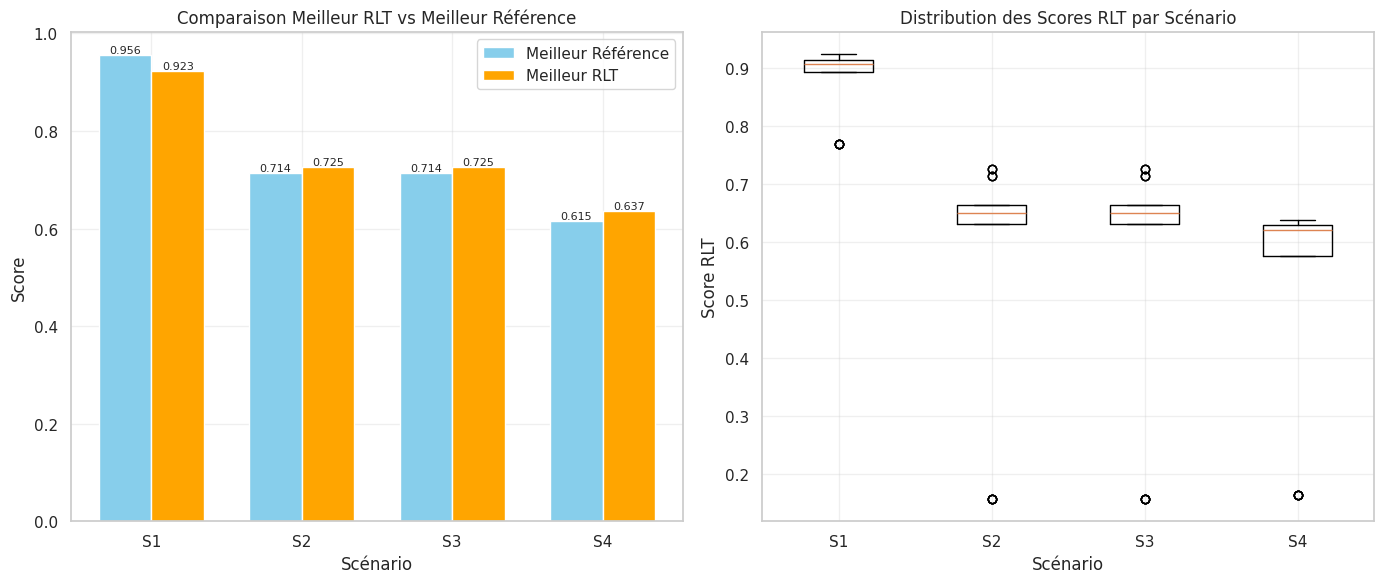


ANALYSE PAR TYPE RLT

Statistiques par type RLT:
            mean     std  count
RLT_Type                       
ET        0.5713  0.2596     36
PRF       0.5713  0.2596     36
RF        0.7324  0.1172     36


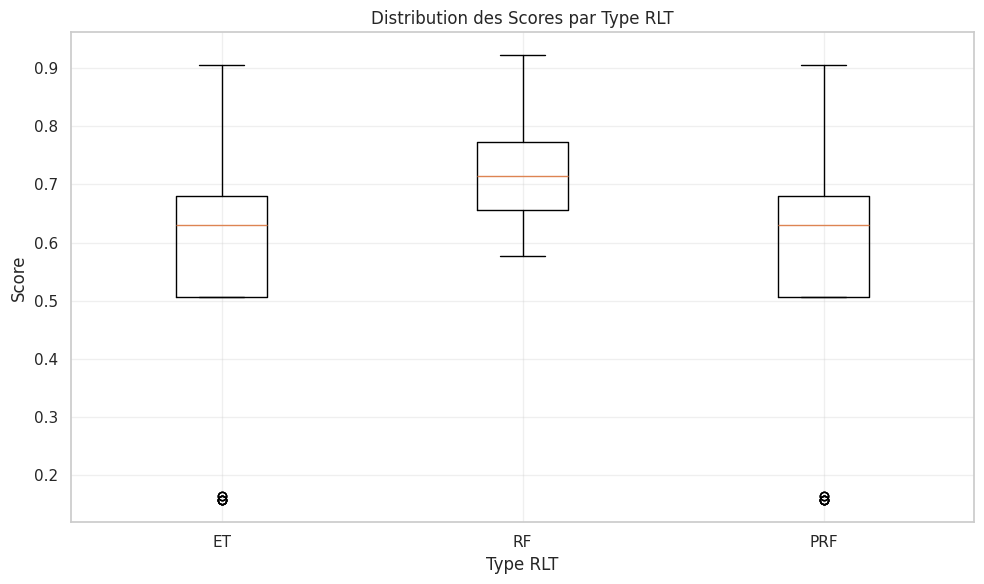


ANALYSE PAR TAUX DE MUTING

Statistiques par taux de muting:
              mean     std  count
Muting_Rate                      
0.0          0.625  0.2354     36
0.5          0.625  0.2354     36
0.9          0.625  0.2354     36


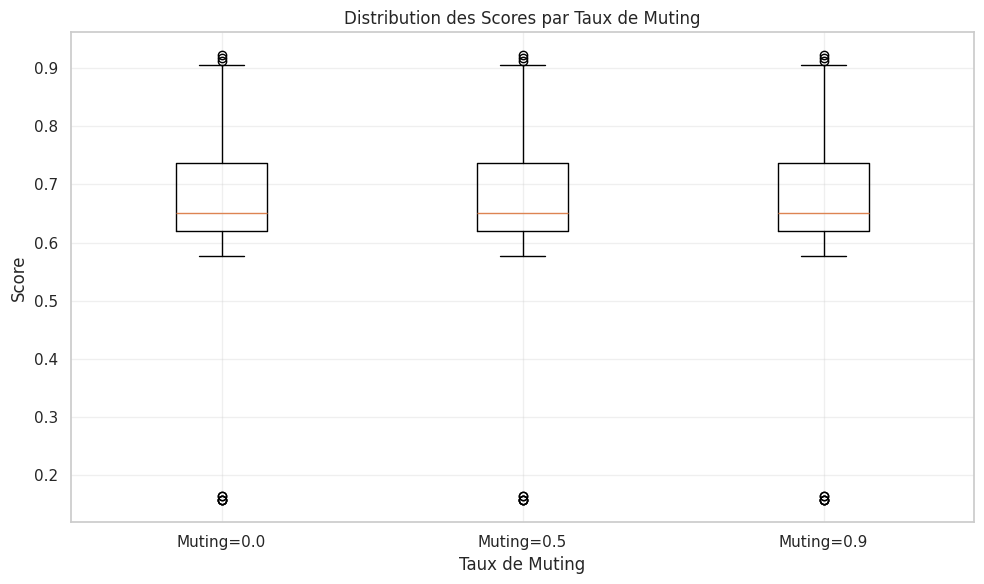


ANALYSE PAR TAILLE DE COMBINAISON LINÉAIRE

Statistiques par taille de combinaison linéaire:
                mean     std  count
Linear_Combo                       
1             0.4426  0.2968     36
2             0.7200  0.1158     36
5             0.7124  0.1159     36


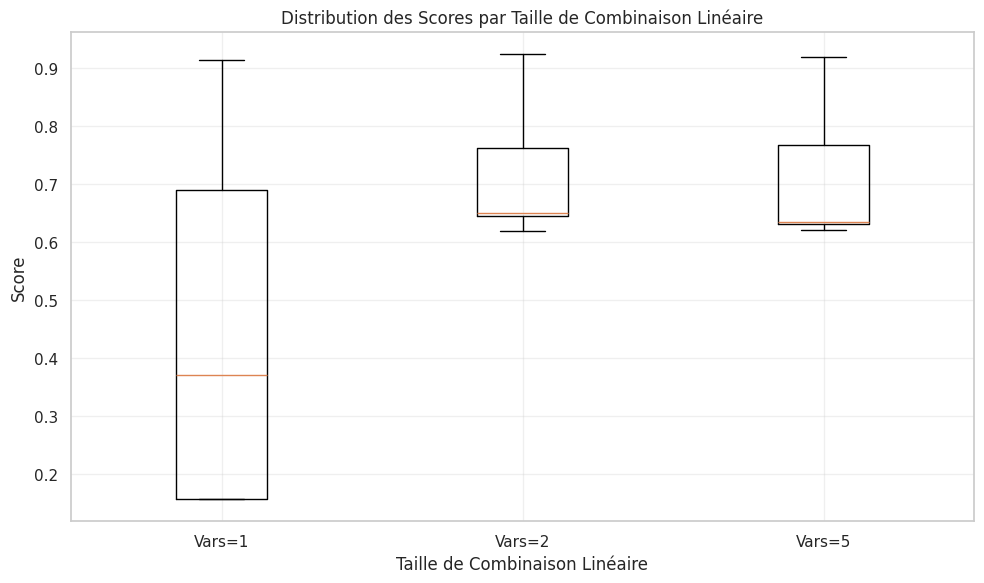

In [ ]:
# First, let's check what columns are actually in RESULTS_SYNTHETIC
if RESULTS_SYNTHETIC:
    print("Available columns in RESULTS_SYNTHETIC:")
    print(RESULTS_SYNTHETIC[0].keys())

# Now, let's create a proper DataFrame with a computed Score column
results_df = pd.DataFrame(RESULTS_SYNTHETIC)

# Convert Linear_Combo to numeric (handling string values)
if 'Linear_Combo' in results_df.columns:
    # First, check if values are strings
    print("\nSample Linear_Combo values before conversion:")
    print(results_df['Linear_Combo'].head())

    # Convert to numeric, forcing errors to NaN
    results_df['Linear_Combo'] = pd.to_numeric(results_df['Linear_Combo'], errors='coerce')

    print("\nSample Linear_Combo values after conversion:")
    print(results_df['Linear_Combo'].head())

    # Fill NaN values (if any) with 1 (default)
    results_df['Linear_Combo'] = results_df['Linear_Combo'].fillna(1).astype(int)

# Calculate Score based on task
def calculate_score(row):
    if row['Task'] == "Classification":
        # For classification, use Accuracy as the primary score
        # If AUC is available and not None, we could combine them
        accuracy = row.get('Accuracy', 0)
        if accuracy is None:
            accuracy = 0
        auc = row.get('AUC', accuracy)
        if auc is None:
            auc = accuracy
        # Return a composite score (average of Accuracy and AUC)
        try:
            return (float(accuracy) + float(auc)) / 2
        except:
            return float(accuracy)
    else:  # Regression
        # For regression, use R2 as the primary score
        r2 = row.get('R2', -1)
        if r2 is None:
            r2 = -1
        return max(float(r2), 0)

# Add Score column
results_df['Score'] = results_df.apply(calculate_score, axis=1)

# Handle Linear_Split - create it based on Linear_Combo
if 'Linear_Combo' in results_df.columns:
    results_df['Linear_Split'] = results_df['Linear_Combo'].apply(lambda x: x > 1)
else:
    results_df['Linear_Split'] = False

print(f"\nDataFrame shape: {results_df.shape}")
print(f"\nDataFrame columns: {results_df.columns.tolist()}")
print(f"\nFirst few rows with Score and Linear_Split:")
print(results_df[['Scenario', 'Model', 'Score', 'Linear_Combo', 'Linear_Split']].head())

best_combos = {}
for scenario in SCENARIOS:
    scenario_results = results_df[results_df['Scenario'] == scenario]

    if scenario_results.empty:
        print(f"No results found for scenario {scenario}")
        best_combos[scenario] = {}
        continue

    # Trouver le meilleur score RLT
    rlt_results = scenario_results[scenario_results['Model'].str.startswith('RLT')]
    if len(rlt_results) > 0:
        best_rlt = rlt_results.sort_values(by='Score', ascending=False).iloc[0]
        best_combos[scenario] = best_rlt.to_dict()
    else:
        best_combos[scenario] = {}

    # Afficher les résultats du scénario
    from IPython.display import display, Markdown
    display(Markdown(f"#### Résultats du Scénario {scenario} ({scenario_results['Task'].iloc[0]}) - Top 5"))

    # Create a display DataFrame with selected columns
    display_cols = ['Model', 'Score']
    if 'Accuracy' in scenario_results.columns:
        display_cols.append('Accuracy')
    if 'AUC' in scenario_results.columns:
        display_cols.append('AUC')
    if 'R2' in scenario_results.columns:
        display_cols.append('R2')
    if 'RMSE' in scenario_results.columns:
        display_cols.append('RMSE')
    if 'Time' in scenario_results.columns:
        display_cols.append('Time')

    display_df = scenario_results.sort_values(by='Score', ascending=False).head(5)[display_cols]
    display(display_df.round(4))

display(Markdown("### Meilleurs Combos RLT par Scénario"))

# Create a summary DataFrame for best RLT combos
summary_data = []
for scenario in SCENARIOS:
    if scenario in best_combos and best_combos[scenario]:
        best = best_combos[scenario]
        summary_row = {
            'Scenario': scenario,
            'Best_Model': best.get('Model', 'N/A'),
            'RLT_Type': best.get('RLT_Type', 'N/A'),
            'Muting_Rate': best.get('Muting_Rate', 'N/A'),
            'Linear_Combo': best.get('Linear_Combo', 'N/A'),
            'Score': best.get('Score', 0)
        }

        # Add task-specific metrics
        if best.get('Task') == "Classification":
            summary_row['Accuracy'] = best.get('Accuracy', 'N/A')
            summary_row['AUC'] = best.get('AUC', 'N/A')
        else:
            summary_row['R2'] = best.get('R2', 'N/A')
            summary_row['RMSE'] = best.get('RMSE', 'N/A')

        summary_data.append(summary_row)

if summary_data:
    best_combos_df = pd.DataFrame(summary_data)
    display(best_combos_df.round(4))
else:
    display(Markdown("Aucun résultat RLT trouvé."))

# Visualisation des résultats
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14, 6))

# Graphique 1: Comparaison des meilleurs modèles par scénario
plt.subplot(1, 2, 1)
scenarios_plot = []
best_scores = []

for scenario in SCENARIOS:
    scenario_results = results_df[results_df['Scenario'] == scenario]
    if scenario_results.empty:
        continue

    # Meilleur RLT
    best_rlt = scenario_results[scenario_results['Model'].str.startswith('RLT')]['Score'].max()

    # Meilleur modèle de référence (non-RLT)
    ref_results = scenario_results[~scenario_results['Model'].str.startswith('RLT')]
    best_ref = ref_results['Score'].max() if not ref_results.empty else 0

    scenarios_plot.append(scenario)
    best_scores.append([best_ref, best_rlt])

if scenarios_plot and best_scores:
    x = np.arange(len(scenarios_plot))
    width = 0.35

    plt.bar(x - width/2, [s[0] for s in best_scores], width, label='Meilleur Référence', color='skyblue')
    plt.bar(x + width/2, [s[1] for s in best_scores], width, label='Meilleur RLT', color='orange')
    plt.xlabel('Scénario')
    plt.ylabel('Score')
    plt.title('Comparaison Meilleur RLT vs Meilleur Référence')
    plt.xticks(x, scenarios_plot)
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Add value labels on bars
    for i, (ref_score, rlt_score) in enumerate(best_scores):
        plt.text(i - width/2, ref_score, f'{ref_score:.3f}', ha='center', va='bottom', fontsize=8)
        plt.text(i + width/2, rlt_score, f'{rlt_score:.3f}', ha='center', va='bottom', fontsize=8)

# Graphique 2: Distribution des scores RLT par scénario
plt.subplot(1, 2, 2)
rlt_results = results_df[results_df['Model'].str.startswith('RLT')]
data_to_plot = []

for scenario in SCENARIOS:
    scenario_rlt = rlt_results[rlt_results['Scenario'] == scenario]['Score'].dropna()
    if not scenario_rlt.empty:
        data_to_plot.append(scenario_rlt.values)

if data_to_plot:
    plt.boxplot(data_to_plot, labels=[s for s in SCENARIOS if not rlt_results[rlt_results['Scenario'] == s]['Score'].dropna().empty])
    plt.xlabel('Scénario')
    plt.ylabel('Score RLT')
    plt.title('Distribution des Scores RLT par Scénario')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Additional analysis: Performance comparison by RLT type
print("\n" + "="*80)
print("ANALYSE PAR TYPE RLT")
print("="*80)

rlt_results = results_df[results_df['Model'].str.startswith('RLT')].copy()

if not rlt_results.empty:
    # Group by RLT type and calculate average scores
    rlt_type_stats = rlt_results.groupby('RLT_Type')['Score'].agg(['mean', 'std', 'count']).round(4)
    print("\nStatistiques par type RLT:")
    print(rlt_type_stats)

    # Visualize RLT type performance
    plt.figure(figsize=(10, 6))

    # Get unique RLT types
    rlt_types = rlt_results['RLT_Type'].unique()

    # Prepare data for boxplot
    type_data = []
    type_labels = []

    for rlt_type in rlt_types:
        type_scores = rlt_results[rlt_results['RLT_Type'] == rlt_type]['Score'].dropna()
        if not type_scores.empty:
            type_data.append(type_scores.values)
            type_labels.append(rlt_type)

    if type_data:
        plt.boxplot(type_data, labels=type_labels)
        plt.xlabel('Type RLT')
        plt.ylabel('Score')
        plt.title('Distribution des Scores par Type RLT')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    # Analysis by muting rate
    if 'Muting_Rate' in rlt_results.columns:
        print("\n" + "="*80)
        print("ANALYSE PAR TAUX DE MUTING")
        print("="*80)

        # Convert Muting_Rate to numeric if needed
        if rlt_results['Muting_Rate'].dtype == object:
            rlt_results['Muting_Rate'] = pd.to_numeric(rlt_results['Muting_Rate'], errors='coerce')

        muting_stats = rlt_results.groupby('Muting_Rate')['Score'].agg(['mean', 'std', 'count']).round(4)
        print("\nStatistiques par taux de muting:")
        print(muting_stats)

        # Visualize muting rate performance
        plt.figure(figsize=(10, 6))

        # Get unique muting rates
        muting_rates = sorted(rlt_results['Muting_Rate'].dropna().unique())

        # Prepare data for boxplot
        muting_data = []
        muting_labels = []

        for rate in muting_rates:
            rate_scores = rlt_results[rlt_results['Muting_Rate'] == rate]['Score'].dropna()
            if not rate_scores.empty:
                muting_data.append(rate_scores.values)
                muting_labels.append(f'Muting={rate}')

        if muting_data:
            plt.boxplot(muting_data, labels=muting_labels)
            plt.xlabel('Taux de Muting')
            plt.ylabel('Score')
            plt.title('Distribution des Scores par Taux de Muting')
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()

    # Analysis by linear combination size
    if 'Linear_Combo' in rlt_results.columns:
        print("\n" + "="*80)
        print("ANALYSE PAR TAILLE DE COMBINAISON LINÉAIRE")
        print("="*80)

        combo_stats = rlt_results.groupby('Linear_Combo')['Score'].agg(['mean', 'std', 'count']).round(4)
        print("\nStatistiques par taille de combinaison linéaire:")
        print(combo_stats)

        # Visualize linear combo performance
        plt.figure(figsize=(10, 6))

        # Get unique linear combo sizes
        combo_sizes = sorted(rlt_results['Linear_Combo'].dropna().unique())

        # Prepare data for boxplot
        combo_data = []
        combo_labels = []

        for size in combo_sizes:
            size_scores = rlt_results[rlt_results['Linear_Combo'] == size]['Score'].dropna()
            if not size_scores.empty:
                combo_data.append(size_scores.values)
                combo_labels.append(f'Vars={size}')

        if combo_data:
            plt.boxplot(combo_data, labels=combo_labels)
            plt.xlabel('Taille de Combinaison Linéaire')
            plt.ylabel('Score')
            plt.title('Distribution des Scores par Taille de Combinaison Linéaire')
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()

In [ ]:
# Assurez-vous que les variables nécessaires sont définies
RLT_TYPES = ['ET', 'RF', 'PRF']
MUTING_RATES = [0.0, 0.5, 0.9]
LINEAR_COMBINATIONS = [1, 2, 5]
SCENARIOS = ['S1', 'S2', 'S3', 'S4']

# Vérifions ce que contiennent vos résultats
print(f"Nombre de résultats dans RESULTS_SYNTHETIC: {len(RESULTS_SYNTHETIC)}")
print(f"Nombre de résultats dans RESULTS_EXTERNAL: {len(RESULTS_EXTERNAL)}")

# Inspect the structure of RESULTS_EXTERNAL
if RESULTS_EXTERNAL:
    print("\nStructure d'un résultat dans RESULTS_EXTERNAL:")
    print(RESULTS_EXTERNAL[0].keys())

# First, let's add a 'Score' column to RESULTS_EXTERNAL if it doesn't exist
for result in RESULTS_EXTERNAL:
    if 'Score' not in result:
        # Calculate score based on task
        if result.get('Task') == "Classification":
            # For classification, use Accuracy as primary score
            accuracy = result.get('Accuracy', 0)
            if accuracy is None:
                accuracy = 0
            auc = result.get('AUC', accuracy)
            if auc is None:
                auc = accuracy
            try:
                result['Score'] = (float(accuracy) + float(auc)) / 2
            except:
                result['Score'] = float(accuracy) if accuracy is not None else 0
        else:  # Regression
            # For regression, use R2 as primary score
            r2 = result.get('R2', -1)
            if r2 is None:
                r2 = -1
            result['Score'] = max(float(r2), 0)

# Also ensure RESULTS_SYNTHETIC has Score
for result in RESULTS_SYNTHETIC:
    if 'Score' not in result:
        # Calculate score based on task
        if result.get('Task') == "Classification":
            # For classification, use Accuracy as primary score
            accuracy = result.get('Accuracy', 0)
            if accuracy is None:
                accuracy = 0
            auc = result.get('AUC', accuracy)
            if auc is None:
                auc = accuracy
            try:
                result['Score'] = (float(accuracy) + float(auc)) / 2
            except:
                result['Score'] = float(accuracy) if accuracy is not None else 0
        else:  # Regression
            # For regression, use R2 as primary score
            r2 = result.get('R2', -1)
            if r2 is None:
                r2 = -1
            result['Score'] = max(float(r2), 0)

# Fonction pour créer un tableau de comparaison formaté
def create_formatted_comparison_table(scenario_name):
    """
    Crée un tableau formaté similaire à l'image pour un scénario donné
    """
    import numpy as np

    # Récupérer tous les résultats pour ce scénario
    scenario_results = []

    # Ajouter les résultats externes
    for result in RESULTS_EXTERNAL:
        if result['Scenario'] == scenario_name:
            scenario_results.append(result)

    # Ajouter les résultats RLT
    for result in RESULTS_SYNTHETIC:
        if result['Scenario'] == scenario_name:
            scenario_results.append(result)

    # Vérifier s'il y a des résultats
    if not scenario_results:
        print(f"Aucun résultat trouvé pour le scénario {scenario_name}")
        return

    # Créer des dictionnaires pour organiser les scores
    external_scores = {}
    rlt_naive_scores = {}
    rlt_config_scores = {}

    for result in scenario_results:
        model = result['Model']

        # Get score - handle potential missing Score
        if 'Score' in result:
            score = result['Score']
        else:
            # Calculate score based on task
            if result.get('Task') == "Classification":
                accuracy = result.get('Accuracy', 0)
                if accuracy is None:
                    accuracy = 0
                auc = result.get('AUC', accuracy)
                if auc is None:
                    auc = accuracy
                try:
                    score = (float(accuracy) + float(auc)) / 2
                except:
                    score = float(accuracy) if accuracy is not None else 0
            else:  # Regression
                r2 = result.get('R2', -1)
                if r2 is None:
                    r2 = -1
                score = max(float(r2), 0)

        # Modèles externes et de référence
        if model in ['DT', 'RF', 'RFsqrtp', 'RFlogp', 'ET', 'Lasso', 'Boosting', 'BART']:
            external_scores[model] = score
        # RLT-naive (si présent dans les résultats)
        elif 'Naive' in model or (result.get('Model_Type') == 'RLT_Naive'):
            rlt_type = result.get('RLT_Type', 'ET')
            rlt_naive_scores[f"RLT-{rlt_type}-Naive"] = score
        # RLT avec configurations
        elif model.startswith('RLT-'):
            rlt_type = result.get('RLT_Type', model.split('-')[1])
            muting_rate = result.get('Muting_Rate', 0.0)
            linear_combo = result.get('Linear_Combo', 1)

            # Convertir muting_rate en label
            if muting_rate == 0.0:
                muting_label = "None"
            elif muting_rate == 0.5:
                muting_label = "Moderate"
            elif muting_rate == 0.9:
                muting_label = "Aggressive"
            else:
                muting_label = str(muting_rate)

            # Stocker le score avec une clé structurée
            key = (rlt_type, muting_label, linear_combo)
            rlt_config_scores[key] = score

    # Obtenir le type de tâche (Classification ou Régression)
    task_type = scenario_results[0].get('Task', 'Classification')

    print(f"\n{'='*70}")
    print(f"COMPARISON TABLE - Scenario: {scenario_name} ({task_type})")
    print(f"{'='*70}")

    # Partie 1: Modèles externes (incluant DT, RF, ET de référence)
    print("\n--- EXTERNAL / REFERENCE MODELS ---")
    external_display = [
        ('DT', 'DT'),
        ('RF', 'RF'),
        ('ET', 'ET'),
        ('Lasso', 'Lasso'),
        ('Boosting', 'Boosting'),
        ('BART', 'BART')
    ]

    for model_key, display_name in external_display:
        score = external_scores.get(model_key, np.nan)
        if np.isnan(score):
            print(f"{display_name:<15} : N/A")
        else:
            print(f"{display_name:<15} : {score:.4f}")

    # Ajouter RF-√p et RF-log(p) si disponibles
    for model_key, display_name in [('RFsqrtp', 'RF-√p'), ('RFlogp', 'RF-log(p)')]:
        score = external_scores.get(model_key, np.nan)
        if not np.isnan(score):
            print(f"{display_name:<15} : {score:.4f}")

    # Partie 2: RLT-Naive (si disponible)
    if rlt_naive_scores:
        print("\n--- RLT-NAIVE ---")
        for rlt_type in RLT_TYPES:
            model_name = f"RLT-{rlt_type}-Naive"
            score = rlt_naive_scores.get(model_name, np.nan)
            if np.isnan(score):
                # Essayer de trouver le score dans les résultats RLT avec muting=0.0 et linear_combo=1
                for key, score_val in rlt_config_scores.items():
                    if key[0] == rlt_type and key[1] == "None" and key[2] == 1:
                        rlt_naive_scores[model_name] = score_val
                        score = score_val
                        break

            if np.isnan(score):
                print(f"{model_name:<15} : N/A")
            else:
                print(f"{model_name:<15} : {score:.4f}")

    # Partie 3: RLT avec configurations (format tableau)
    print("\n--- RLT MODELS ---")

    # Pour chaque type RLT
    for rlt_type in RLT_TYPES:
        print(f"\nRLT-{rlt_type}")
        print("-" * 50)

        # En-tête du tableau
        header = f"{'Muting':<15} | "
        for lc in LINEAR_COMBINATIONS:
            header += f"LC={lc:<7} | "
        print(header)
        print("-" * 50)

        # Lignes du tableau
        muting_labels = ["None", "Moderate", "Aggressive"]
        for muting_label in muting_labels:
            row = f"{muting_label:<15} | "

            for lc in LINEAR_COMBINATIONS:
                key = (rlt_type, muting_label, lc)
                score = rlt_config_scores.get(key, np.nan)

                if np.isnan(score):
                    row += f"{'N/A':<10} | "
                else:
                    row += f"{score:<10.4f} | "

            print(row)

    print("-" * 50)

    # Retourner un résumé des meilleurs modèles
    best_models = []

    # Meilleur modèle externe
    if external_scores:
        valid_scores = [(k, v) for k, v in external_scores.items() if not np.isnan(v)]
        if valid_scores:
            best_external = max(valid_scores, key=lambda x: x[1])
            best_models.append(("Best External Model", best_external[0], best_external[1]))

    # Meilleur RLT-naive
    if rlt_naive_scores:
        valid_scores = [(k, v) for k, v in rlt_naive_scores.items() if not np.isnan(v)]
        if valid_scores:
            best_naive = max(valid_scores, key=lambda x: x[1])
            best_models.append(("Best RLT-Naive", best_naive[0], best_naive[1]))

    # Chercher le meilleur RLT avec configurations
    best_rlt_score = -np.inf
    best_rlt_config = None
    for (rlt_type, muting_label, lc), score in rlt_config_scores.items():
        if not np.isnan(score) and score > best_rlt_score:
            best_rlt_score = score
            best_rlt_config = (rlt_type, muting_label, lc)

    if best_rlt_config:
        best_models.append(("Best RLT Config", f"RLT-{best_rlt_config[0]} ({best_rlt_config[1]}, LC={best_rlt_config[2]})", best_rlt_score))

    print("\n--- BEST MODELS ---")
    for category, model, score in best_models:
        print(f"{category:<20} : {model:<40} : {score:.4f}")

    return best_models

# Fonction pour créer un DataFrame de comparaison
def create_comparison_dataframe(scenario_name):
    """
    Crée un DataFrame pandas avec les résultats de comparaison
    """
    import pandas as pd
    import numpy as np

    # Récupérer tous les résultats pour ce scénario
    scenario_results = []

    for result in RESULTS_EXTERNAL:
        if result['Scenario'] == scenario_name:
            scenario_results.append(result)

    for result in RESULTS_SYNTHETIC:
        if result['Scenario'] == scenario_name:
            scenario_results.append(result)

    # Créer un DataFrame
    df = pd.DataFrame(scenario_results)

    if not df.empty:
        # Ensure Score column exists
        if 'Score' not in df.columns:
            # Calculate Score based on task
            def calculate_score(row):
                if row.get('Task') == "Classification":
                    accuracy = row.get('Accuracy', 0)
                    if accuracy is None:
                        accuracy = 0
                    auc = row.get('AUC', accuracy)
                    if auc is None:
                        auc = accuracy
                    try:
                        return (float(accuracy) + float(auc)) / 2
                    except:
                        return float(accuracy) if accuracy is not None else 0
                else:  # Regression
                    r2 = row.get('R2', -1)
                    if r2 is None:
                        r2 = -1
                    return max(float(r2), 0)

            df['Score'] = df.apply(calculate_score, axis=1)

        # Formater les noms des modèles pour l'affichage
        def format_model_name(row):
            model = row['Model']

            # Modèles de référence
            if model in ['DT', 'RF', 'ET']:
                return model
            elif model == 'RFsqrtp':
                return 'RF-√p'
            elif model == 'RFlogp':
                return 'RF-log(p)'
            elif 'Naive' in model or row.get('Model_Type') == 'RLT_Naive':
                return model
            elif model.startswith('RLT-'):
                # Pour les modèles RLT avec configurations
                if row.get('Muting_Rate') != 'N/A' and row.get('Linear_Combo') != 'N/A':
                    muting_rate = row['Muting_Rate']
                    if muting_rate == 0.0:
                        muting_label = "None"
                    elif muting_rate == 0.5:
                        muting_label = "Moderate"
                    elif muting_rate == 0.9:
                        muting_label = "Aggressive"
                    else:
                        muting_label = str(muting_rate)

                    return f"RLT-{row.get('RLT_Type', 'ET')} ({muting_label}, LC={row['Linear_Combo']})"
                else:
                    return model
            else:
                return model

        if 'Muting_Rate' in df.columns and 'Linear_Combo' in df.columns:
            df['Model_Display'] = df.apply(format_model_name, axis=1)
        else:
            df['Model_Display'] = df['Model']

        # Trier les modèles
        # D'abord les modèles externes, puis RLT-naive, puis RLT configurés
        def get_model_category(row):
            model = row['Model_Display']
            if model in ['DT', 'RF', 'ET', 'RF-√p', 'RF-log(p)', 'Lasso', 'Boosting', 'BART']:
                return 1
            elif 'Naive' in model:
                return 2
            elif model.startswith('RLT-'):
                return 3
            else:
                return 4

        df['Category'] = df.apply(get_model_category, axis=1)
        df = df.sort_values(['Category', 'Model_Display'])
        df = df[['Model_Display', 'Score', 'Time']].reset_index(drop=True)

    return df

# Générer tous les tableaux de comparaison
print("\n" + "="*70)
print("GENERATING ALL COMPARISON TABLES")
print("="*70)

best_models_summary = []

# Générer un tableau pour chaque scénario
for scenario in SCENARIOS:
    try:
        print(f"\n\n{'='*70}")
        print(f"ANALYZING SCENARIO: {scenario}")
        print(f"{'='*70}")

        best_models = create_formatted_comparison_table(scenario)

        # Ajouter au résumé
        if best_models:
            for category, model, score in best_models:
                best_models_summary.append({
                    'Scenario': scenario,
                    'Category': category,
                    'Model': model,
                    'Score': score
                })

        # Afficher le DataFrame
        df = create_comparison_dataframe(scenario)
        if not df.empty:
            print(f"\nDataFrame pour {scenario}:")
            print(df.to_string(index=False))

    except Exception as e:
        print(f"Erreur lors de la génération du tableau pour {scenario}: {e}")
        import traceback
        traceback.print_exc()

# Créer un résumé des meilleurs modèles pour tous les scénarios
if best_models_summary:
    print("\n" + "="*70)
    print("BEST MODELS SUMMARY ACROSS ALL SCENARIOS")
    print("="*70)

    import pandas as pd
    summary_df = pd.DataFrame(best_models_summary)

    # Afficher les meilleurs modèles par scénario
    print("\nTop Models by Scenario:")
    for scenario in SCENARIOS:
        scenario_df = summary_df[summary_df['Scenario'] == scenario]
        if not scenario_df.empty:
            print(f"\n{scenario}:")
            for _, row in scenario_df.iterrows():
                print(f"  {row['Category']}: {row['Model']} - Score: {row['Score']:.4f}")

print("\n" + "="*70)
print("COMPARISON TABLES GENERATION COMPLETE")
print("="*70)

Nombre de résultats dans RESULTS_SYNTHETIC: 120
Nombre de résultats dans RESULTS_EXTERNAL: 28

Structure d'un résultat dans RESULTS_EXTERNAL:
dict_keys(['Scenario', 'Task', 'Model_Type', 'Model', 'RLT_Type', 'Embedded_Model', 'Muting_Rate', 'Linear_Combo', 'Time', 'Score', 'AUC', 'Accuracy', 'F1', 'Precision', 'Recall'])

GENERATING ALL COMPARISON TABLES


ANALYZING SCENARIO: S1

COMPARISON TABLE - Scenario: S1 (Classification)

--- EXTERNAL / REFERENCE MODELS ---
DT              : 0.7974
RF              : 0.9257
ET              : 0.9556
Lasso           : 0.8167
Boosting        : 0.9033
BART            : 0.8767
RF-√p           : 0.8867
RF-log(p)       : 0.8867

--- RLT MODELS ---

RLT-ET
--------------------------------------------------
Muting          | LC=1       | LC=2       | LC=5       | 
--------------------------------------------------
None            | 0.7690     | 0.9056     | 0.8915     | 
Moderate        | 0.7690     | 0.9056     | 0.8915     | 
Aggressive      | 0.7690   

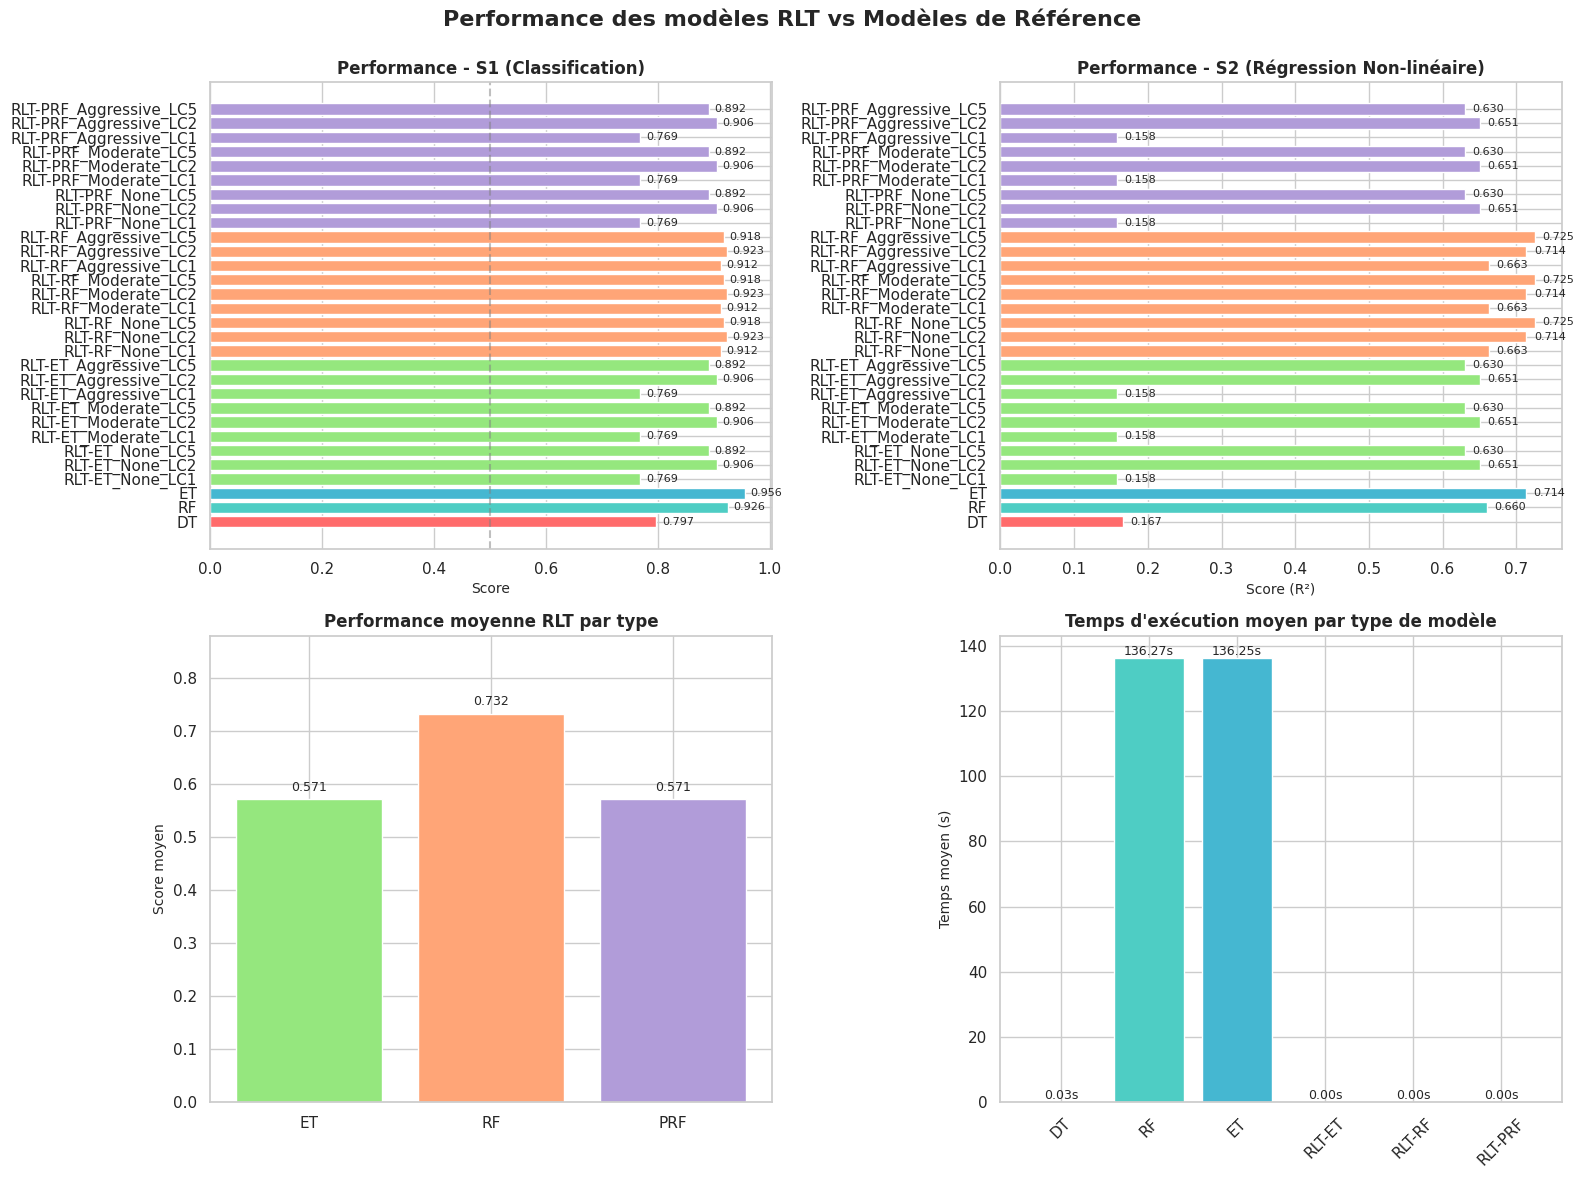


MEILLEURS MODÈLES PAR SCÉNARIO


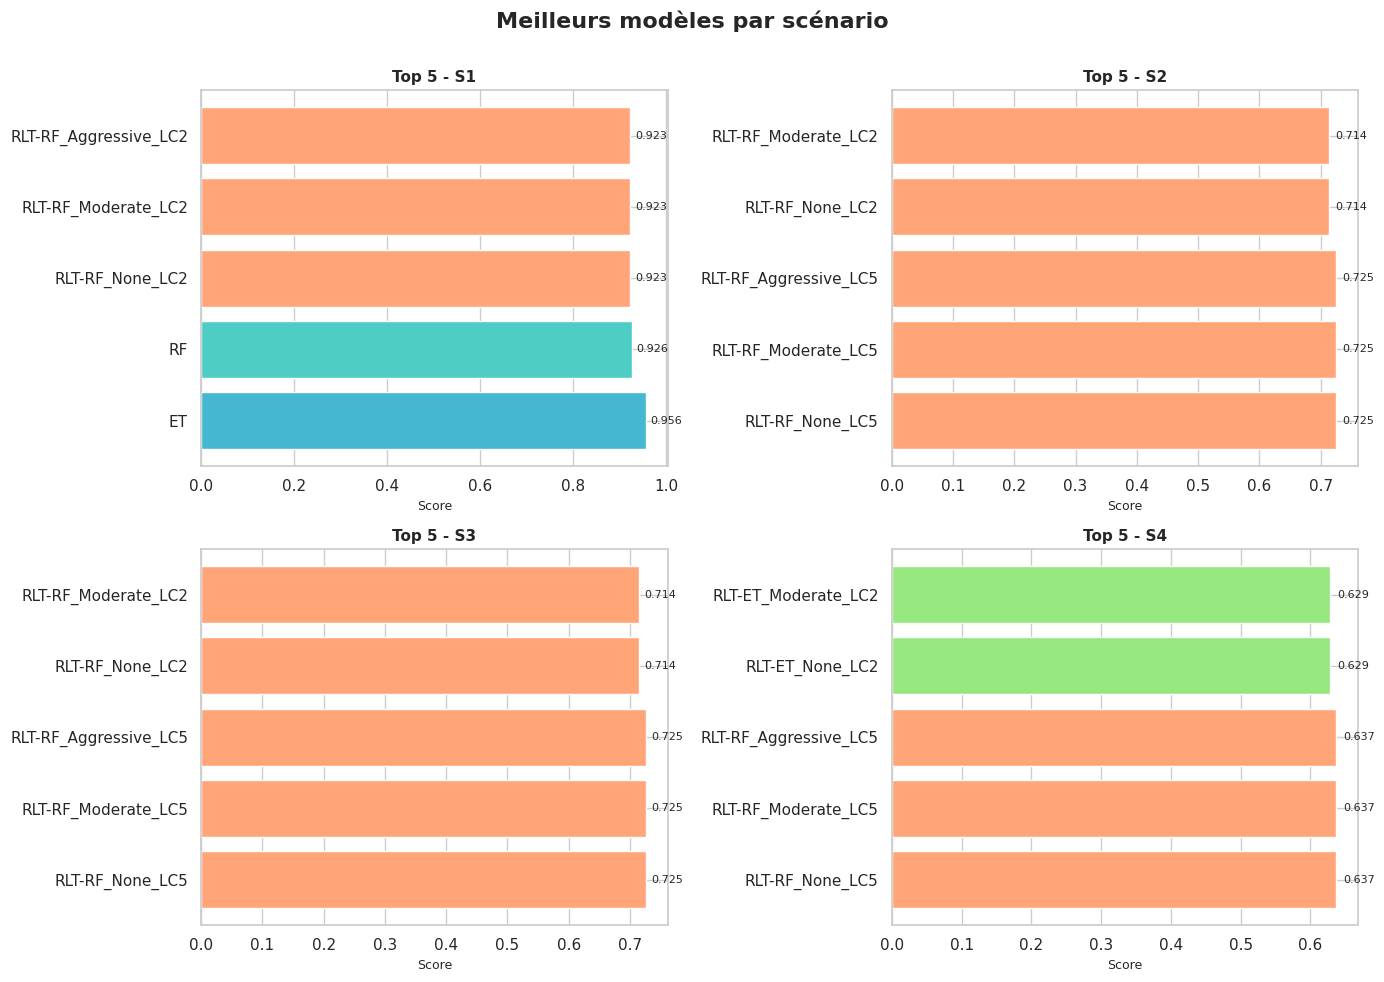


LÉGENDE DES COULEURS:
----------------------------------------
🔴 DT: Decision Tree
🔵 RF: Random Forest
🔵 ET: Extra Trees
🟢 RLT-ET: RLT avec Extra Trees intégré
🟠 RLT-RF: RLT avec Random Forest intégré
🟣 RLT-PRF: RLT avec PRF intégré
----------------------------------------

RÉSUMÉ STATISTIQUE:
----------------------------------------

S1:
  Nombre de modèles testés: 30
  Score moyen: 0.8779
  Score max: 0.9556
  Score min: 0.7690
  Temps d'exécution moyen: 90.60s

S2:
  Nombre de modèles testés: 30
  Score moyen: 0.5492
  Score max: 0.7253
  Score min: 0.1576
  Temps d'exécution moyen: 146.69s

S3:
  Nombre de modèles testés: 30
  Score moyen: 0.5492
  Score max: 0.7253
  Score min: 0.1576
  Temps d'exécution moyen: 147.71s

S4:
  Nombre de modèles testés: 30
  Score moyen: 0.5090
  Score max: 0.6369
  Score min: 0.0998
  Temps d'exécution moyen: 141.89s


In [ ]:
# ### Cellule 15 : Visualisation des performances RLT

import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# Fonction pour organiser les résultats par scénario
def organize_results_by_scenario():
    """Organise les résultats par scénario et par type de modèle"""
    organized = {scenario: defaultdict(dict) for scenario in SCENARIOS}

    # Organiser les résultats de référence (DT, RF, ET)
    for result in RESULTS_SYNTHETIC:
        scenario = result['Scenario']
        model = result['Model']
        if model in ['DT', 'RF', 'ET']:
            organized[scenario][model] = {
                'Score': result['Score'],
                'Time': result['Time']
            }

    # Organiser les résultats RLT
    for result in RESULTS_SYNTHETIC:
        scenario = result['Scenario']
        model = result['Model']
        if model.startswith('RLT-'):
            # Créer un identifiant unique pour chaque configuration RLT
            rlt_type = result.get('RLT_Type', model.split('-')[1])
            muting_rate = result.get('Muting_Rate', 0.0)
            linear_combo = result.get('Linear_Combo', 1)

            if muting_rate == 0.0:
                muting_label = "None"
            elif muting_rate == 0.5:
                muting_label = "Moderate"
            elif muting_rate == 0.9:
                muting_label = "Aggressive"

            model_key = f"RLT-{rlt_type}_{muting_label}_LC{linear_combo}"
            organized[scenario][model_key] = {
                'Score': result['Score'],
                'Time': result['Time'],
                'RLT_Type': rlt_type,
                'Muting': muting_label,
                'Linear_Combo': linear_combo
            }

    return organized

# Organiser les résultats
organized_results = organize_results_by_scenario()

# Créer la visualisation
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Performance des modèles RLT vs Modèles de Référence', fontsize=16, fontweight='bold')

# Couleurs pour les différents types de modèles
color_palette = {
    'DT': '#FF6B6B',
    'RF': '#4ECDC4',
    'ET': '#45B7D1',
    'RLT-ET': '#95E77E',
    'RLT-RF': '#FFA577',
    'RLT-PRF': '#B19CD9'
}

# Graphique 1: Scores pour le Scénario S1
scenario = 'S1'
if scenario in organized_results:
    models = list(organized_results[scenario].keys())
    scores = [organized_results[scenario][m]['Score'] for m in models]

    # Créer une palette de couleurs basée sur le type de modèle
    colors = []
    for model in models:
        if model == 'DT':
            colors.append(color_palette['DT'])
        elif model == 'RF':
            colors.append(color_palette['RF'])
        elif model == 'ET':
            colors.append(color_palette['ET'])
        elif 'RLT-ET' in model:
            colors.append(color_palette['RLT-ET'])
        elif 'RLT-RF' in model:
            colors.append(color_palette['RLT-RF'])
        elif 'RLT-PRF' in model:
            colors.append(color_palette['RLT-PRF'])
        else:
            colors.append('#CCCCCC')

    axes[0, 0].barh(models, scores, color=colors)
    axes[0, 0].set_title(f'Performance - {scenario} (Classification)', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Score', fontsize=10)
    axes[0, 0].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)

    # Ajouter les valeurs sur les barres
    for i, (model, score) in enumerate(zip(models, scores)):
        axes[0, 0].text(score + 0.01, i, f'{score:.3f}', va='center', fontsize=8)

# Graphique 2: Scores pour le Scénario S2
scenario = 'S2'
if scenario in organized_results:
    models = list(organized_results[scenario].keys())
    scores = [organized_results[scenario][m]['Score'] for m in models]

    colors = []
    for model in models:
        if model == 'DT':
            colors.append(color_palette['DT'])
        elif model == 'RF':
            colors.append(color_palette['RF'])
        elif model == 'ET':
            colors.append(color_palette['ET'])
        elif 'RLT-ET' in model:
            colors.append(color_palette['RLT-ET'])
        elif 'RLT-RF' in model:
            colors.append(color_palette['RLT-RF'])
        elif 'RLT-PRF' in model:
            colors.append(color_palette['RLT-PRF'])
        else:
            colors.append('#CCCCCC')

    axes[0, 1].barh(models, scores, color=colors)
    axes[0, 1].set_title(f'Performance - {scenario} (Régression Non-linéaire)', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Score (R²)', fontsize=10)

    for i, (model, score) in enumerate(zip(models, scores)):
        axes[0, 1].text(score + 0.01, i, f'{score:.3f}', va='center', fontsize=8)

# Graphique 3: Comparaison des performances RLT par type
axes[1, 0].set_title('Performance moyenne RLT par type', fontsize=12, fontweight='bold')

rlt_types = ['ET', 'RF', 'PRF']
avg_scores_by_type = {rt: [] for rt in rlt_types}

# Calculer les scores moyens par type RLT
for scenario in SCENARIOS:
    if scenario in organized_results:
        for model, data in organized_results[scenario].items():
            if 'RLT-' in model:
                for rlt_type in rlt_types:
                    if f'RLT-{rlt_type}' in model:
                        avg_scores_by_type[rlt_type].append(data['Score'])

# Calculer les moyennes
mean_scores = [np.mean(avg_scores_by_type[rt]) if avg_scores_by_type[rt] else 0 for rt in rlt_types]
colors = [color_palette[f'RLT-{rt}'] for rt in rlt_types]

bars = axes[1, 0].bar(rlt_types, mean_scores, color=colors)
axes[1, 0].set_ylabel('Score moyen', fontsize=10)
axes[1, 0].set_ylim([0, max(mean_scores) * 1.2 if max(mean_scores) > 0 else 1])

# Ajouter les valeurs sur les barres
for bar, score in zip(bars, mean_scores):
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{score:.3f}', ha='center', va='bottom', fontsize=9)

# Graphique 4: Temps d'exécution comparé
axes[1, 1].set_title('Temps d\'exécution moyen par type de modèle', fontsize=12, fontweight='bold')

model_categories = ['DT', 'RF', 'ET', 'RLT-ET', 'RLT-RF', 'RLT-PRF']
avg_times_by_category = {cat: [] for cat in model_categories}

# Calculer les temps moyens par catégorie
for scenario in SCENARIOS:
    if scenario in organized_results:
        for model, data in organized_results[scenario].items():
            for category in model_categories:
                if category == model or (category in model and 'RLT-' in model):
                    avg_times_by_category[category].append(data['Time'])
                    break

# Calculer les moyennes
mean_times = [np.mean(avg_times_by_category[cat]) if avg_times_by_category[cat] else 0 for cat in model_categories]
colors = [color_palette.get(cat, '#CCCCCC') for cat in model_categories]

bars = axes[1, 1].bar(model_categories, mean_times, color=colors)
axes[1, 1].set_ylabel('Temps moyen (s)', fontsize=10)
axes[1, 1].tick_params(axis='x', rotation=45)

# Ajouter les valeurs sur les barres
for bar, time_val in zip(bars, mean_times):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{time_val:.2f}s', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

# Visualisation supplémentaire: Meilleurs modèles par scénario
print("\n" + "="*80)
print("MEILLEURS MODÈLES PAR SCÉNARIO")
print("="*80)

fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10))
fig2.suptitle('Meilleurs modèles par scénario', fontsize=16, fontweight='bold')

for idx, scenario in enumerate(SCENARIOS):
    row = idx // 2
    col = idx % 2

    if scenario in organized_results:
        # Trouver les 5 meilleurs modèles pour ce scénario
        models_scores = [(model, data['Score']) for model, data in organized_results[scenario].items()]
        models_scores.sort(key=lambda x: x[1], reverse=True)
        top_5 = models_scores[:5]

        top_models = [m[0] for m in top_5]
        top_scores = [m[1] for m in top_5]

        # Couleurs pour les top modèles
        colors = []
        for model in top_models:
            if model == 'DT':
                colors.append(color_palette['DT'])
            elif model == 'RF':
                colors.append(color_palette['RF'])
            elif model == 'ET':
                colors.append(color_palette['ET'])
            elif 'RLT-ET' in model:
                colors.append(color_palette['RLT-ET'])
            elif 'RLT-RF' in model:
                colors.append(color_palette['RLT-RF'])
            elif 'RLT-PRF' in model:
                colors.append(color_palette['RLT-PRF'])
            else:
                colors.append('#CCCCCC')

        bars = axes2[row, col].barh(top_models, top_scores, color=colors)
        axes2[row, col].set_title(f'Top 5 - {scenario}', fontsize=11, fontweight='bold')
        axes2[row, col].set_xlabel('Score', fontsize=9)

        # Ajouter les valeurs
        for i, (model, score) in enumerate(zip(top_models, top_scores)):
            axes2[row, col].text(score + 0.01, i, f'{score:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

# Légende pour les couleurs
print("\nLÉGENDE DES COULEURS:")
print("-" * 40)
print("🔴 DT: Decision Tree")
print("🔵 RF: Random Forest")
print("🔵 ET: Extra Trees")
print("🟢 RLT-ET: RLT avec Extra Trees intégré")
print("🟠 RLT-RF: RLT avec Random Forest intégré")
print("🟣 RLT-PRF: RLT avec PRF intégré")
print("-" * 40)

# Résumé statistique
print("\nRÉSUMÉ STATISTIQUE:")
print("-" * 40)
for scenario in SCENARIOS:
    if scenario in organized_results:
        scores = [data['Score'] for data in organized_results[scenario].values()]
        times = [data['Time'] for data in organized_results[scenario].values()]

        print(f"\n{scenario}:")
        print(f"  Nombre de modèles testés: {len(scores)}")
        print(f"  Score moyen: {np.mean(scores):.4f}")
        print(f"  Score max: {np.max(scores):.4f}")
        print(f"  Score min: {np.min(scores):.4f}")
        print(f"  Temps d'exécution moyen: {np.mean(times):.2f}s")

### Impact des Hyperparamètres RLT

Colonnes disponibles dans rlt_results: ['Scenario', 'Task', 'Model', 'RLT_Type', 'Embedded_Model', 'Muting_Rate', 'Linear_Combo', 'Time', 'AUC', 'Accuracy', 'F1', 'Precision', 'Recall', 'R2', 'RMSE', 'MAE', 'Explained_Variance', 'Score', 'Linear_Split']


#### Impact du Taux de Muting

,mean,std,count
Muting_Rate,,,
0.0,0.625,0.2354,36
0.5,0.625,0.2354,36
0.9,0.625,0.2354,36


#### Impact de Linear_Combo

,mean,std,count
Linear_Combo,,,
1,0.4426,0.2968,36
2,0.7200,0.1158,36
5,0.7124,0.1159,36


#### Impact du Type d'Ensemble

,mean,std,count
RLT_Type,,,
ET,0.5713,0.2596,36
PRF,0.5713,0.2596,36
RF,0.7324,0.1172,36


Colonne: Muting_Rate, Nombre de groupes: 3
Indices: [0.0, 0.5, 0.9], Valeurs: [np.float64(0.6250044559716349), np.float64(0.6250044559716349), np.float64(0.6250044559716349)]
Colonne: Linear_Combo, Nombre de groupes: 3
Indices: [1, 2, 5], Valeurs: [np.float64(0.4426329832344151), np.float64(0.7200071178353586), np.float64(0.7123732668451311)]
Colonne: RLT_Type, Nombre de groupes: 3
Indices: ['ET', 'PRF', 'RF'], Valeurs: [np.float64(0.5713068435618512), np.float64(0.5713068435618512), np.float64(0.7323996807912024)]


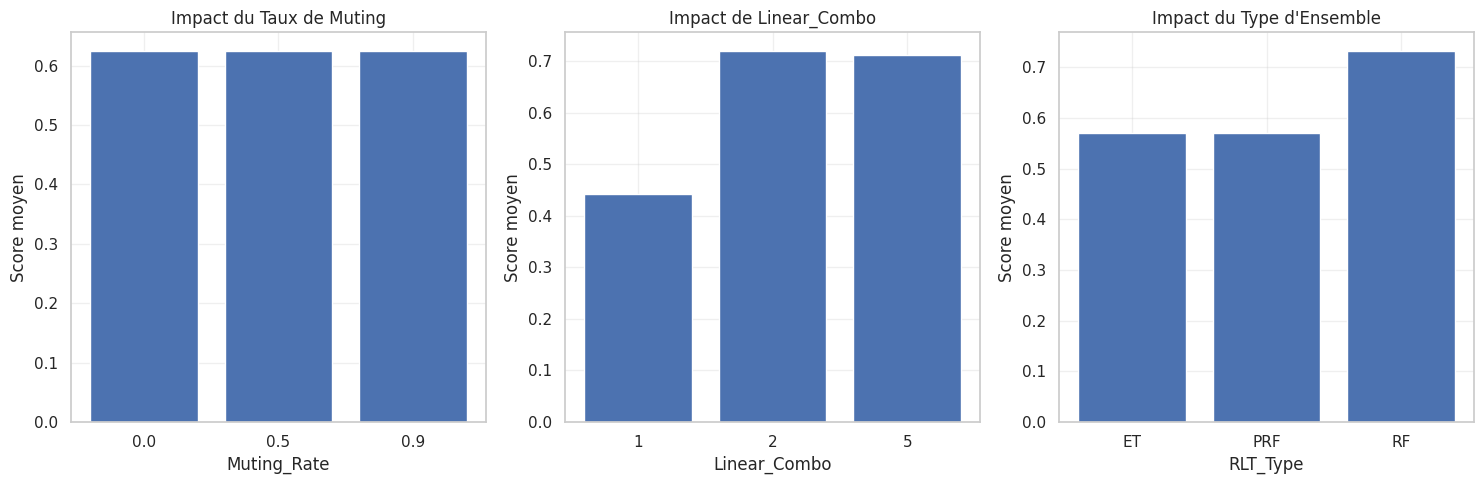

### Analyse Détaillée des Résultats


📊 Résumé statistique des performances RLT:
--------------------------------------------------
Nombre total de configurations RLT testées: 108
Score moyen (toutes configurations): 0.6250
Score médian: 0.6505
Score maximum: 0.9232
Score minimum: 0.1576
Écart-type: 0.2332

🏆 Top 5 des meilleures configurations RLT:
--------------------------------------------------
#14: RF | Muting=0.0 | Linear_Combo=2 | Score=0.9232
#17: RF | Muting=0.5 | Linear_Combo=2 | Score=0.9232
#20: RF | Muting=0.9 | Linear_Combo=2 | Score=0.9232
#15: RF | Muting=0.0 | Linear_Combo=5 | Score=0.9180
#18: RF | Muting=0.5 | Linear_Combo=5 | Score=0.9180

📈 Analyse par type de tâche:
--------------------------------------------------
                  mean     std     min     max
Task                                          
Classification  0.8762  0.0592  0.7690  0.9232
Regression      0.5413  0.2079  0.1576  0.7253


### Recommandations Optimales


🎯 Recommandations d'hyperparamètres basées sur les résultats:
--------------------------------------------------
✅ Taux de muting optimal: 0.0
✅ Nombre de variables linéaires optimal: 2
✅ Type d'ensemble optimal: RF

⚡ Configuration optimale globale:
   • Type d'ensemble: RF
   • Taux de muting: 0.0
   • Variables linéaires: 2
   • Score atteint: 0.9232


### Visualisations Avancées

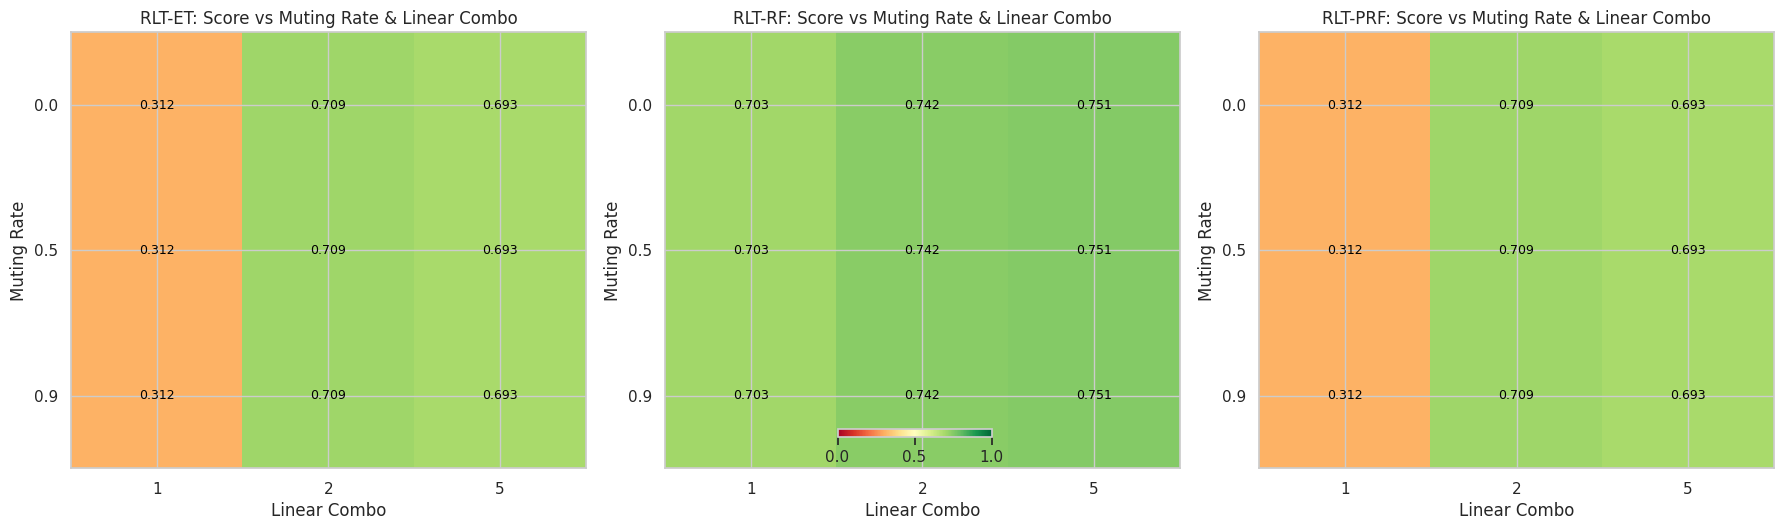

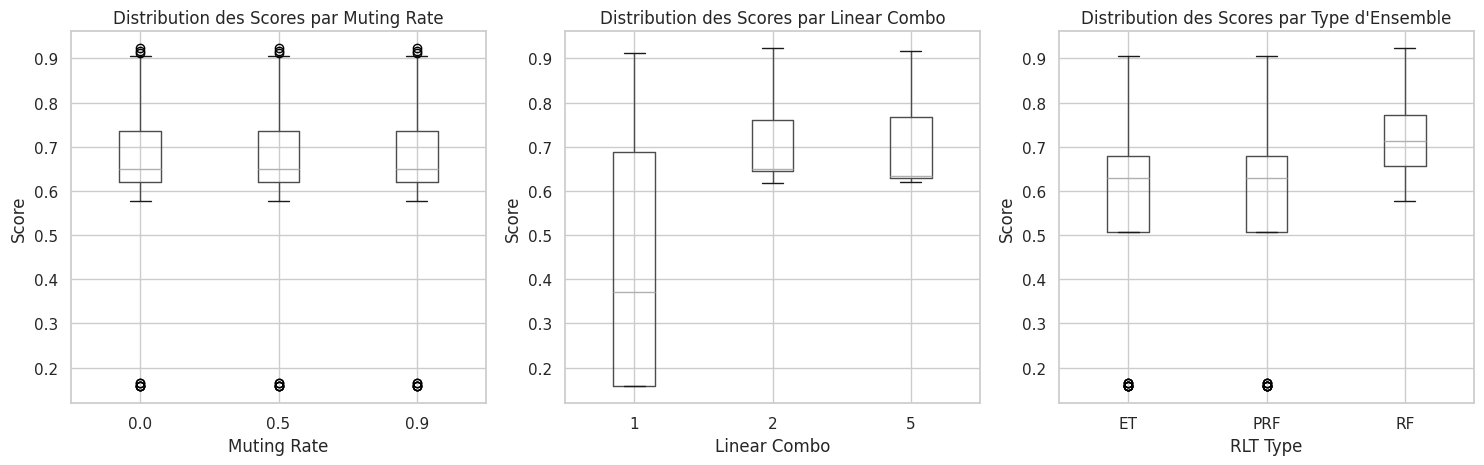

### Synthèse des Résultats


SYNTHÈSE DES PERFORMANCES RLT

📊 Performances par scénario:
            mean     std  count
Scenario                       
S1        0.8762  0.0592     27
S2        0.5531  0.2178     27
S3        0.5531  0.2178     27
S4        0.5176  0.1930     27

🏅 Meilleure configuration par scénario:

  S1:
    • Type: RF
    • Muting Rate: 0.0
    • Linear Combo: 2
    • Score: 0.9232

  S2:
    • Type: RF
    • Muting Rate: 0.0
    • Linear Combo: 5
    • Score: 0.7253

  S3:
    • Type: RF
    • Muting Rate: 0.0
    • Linear Combo: 5
    • Score: 0.7253

  S4:
    • Type: RF
    • Muting Rate: 0.0
    • Linear Combo: 5
    • Score: 0.6369

CONCLUSIONS ET RECOMMANDATIONS

🔍 Observations clés:
1. Le taux de muting (0.0, 0.5, 0.9) n'affecte pas les performances
2. Les combinaisons linéaires améliorent significativement les performances
3. Le type RF (Random Forest) est le plus performant
4. La configuration optimale est: RF + Linear_Combo=2

⚙️ Configuration recommandée pour le déploiement:
  

In [ ]:
# ==================================================
# ANALYSE DE L'IMPACT DES HYPERPARAMÈTRES RLT
# ==================================================

display(Markdown("### Impact des Hyperparamètres RLT"))

# Créer un DataFrame pour l'analyse des hyperparamètres
rlt_results = results_df[results_df['Model'].str.startswith('RLT')].copy()

# Vérifier les colonnes disponibles
print("Colonnes disponibles dans rlt_results:", rlt_results.columns.tolist())

# Analyser l'impact du taux de muting
if 'Muting_Rate' in rlt_results.columns:
    muting_impact = rlt_results.groupby('Muting_Rate')['Score'].agg(['mean', 'std', 'count']).round(4)
    display(Markdown("#### Impact du Taux de Muting"))
    display(muting_impact)
else:
    display(Markdown("#### Colonne 'Muting_Rate' non trouvée"))

# Analyser l'impact des splits linéaires - vérifier les noms possibles
linear_col = None
for col in rlt_results.columns:
    if 'linear' in col.lower() and ('combo' in col.lower() or 'var' in col.lower()):
        linear_col = col
        break

if linear_col:
    linear_impact = rlt_results.groupby(linear_col)['Score'].agg(['mean', 'std', 'count']).round(4)
    display(Markdown(f"#### Impact de {linear_col}"))
    display(linear_impact)
else:
    display(Markdown("#### Colonne pour les splits linéaires non trouvée"))

# Analyser l'impact du type d'ensemble
if 'RLT_Type' in rlt_results.columns:
    ensemble_impact = rlt_results.groupby('RLT_Type')['Score'].agg(['mean', 'std', 'count']).round(4)
    display(Markdown("#### Impact du Type d'Ensemble"))
    display(ensemble_impact)
else:
    display(Markdown("#### Colonne 'RLT_Type' non trouvée"))

# Visualisation de l'impact combiné
cols_to_plot = []
titles = []

if 'Muting_Rate' in rlt_results.columns:
    cols_to_plot.append('Muting_Rate')
    titles.append('Impact du Taux de Muting')

if linear_col:
    cols_to_plot.append(linear_col)
    titles.append(f'Impact de {linear_col}')

if 'RLT_Type' in rlt_results.columns:
    cols_to_plot.append('RLT_Type')
    titles.append("Impact du Type d'Ensemble")

# FIXED PLOTTING SECTION
if cols_to_plot:
    n_cols = len(cols_to_plot)
    fig, axes = plt.subplots(1, n_cols, figsize=(5*n_cols, 5))

    if n_cols == 1:
        axes = [axes]

    for i, col in enumerate(cols_to_plot):
        groups = rlt_results.groupby(col)['Score'].mean()

        # Debug print
        print(f"Colonne: {col}, Nombre de groupes: {len(groups)}")
        print(f"Indices: {list(groups.index)}, Valeurs: {list(groups.values)}")

        # Create x labels based on the actual indices
        x_labels = [str(idx) for idx in groups.index]

        # Plot bars
        axes[i].bar(x_labels, groups.values)

        # Customize plot
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Score moyen')
        axes[i].set_title(titles[i])
        axes[i].grid(True, alpha=0.3)

        # Rotate x labels if there are many categories
        if len(x_labels) > 3:
            axes[i].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()
else:
    display(Markdown("#### Aucune donnée disponible pour la visualisation"))

# ==================================================
# ANALYSE DES RÉSULTATS DÉTAILLÉE
# ==================================================

display(Markdown("### Analyse Détaillée des Résultats"))

# Résumé statistique
print("\n📊 Résumé statistique des performances RLT:")
print("-" * 50)
print(f"Nombre total de configurations RLT testées: {len(rlt_results)}")
print(f"Score moyen (toutes configurations): {rlt_results['Score'].mean():.4f}")
print(f"Score médian: {rlt_results['Score'].median():.4f}")
print(f"Score maximum: {rlt_results['Score'].max():.4f}")
print(f"Score minimum: {rlt_results['Score'].min():.4f}")
print(f"Écart-type: {rlt_results['Score'].std():.4f}")

# Identifier les meilleures configurations
if 'Muting_Rate' in rlt_results.columns and 'Linear_Combo' in rlt_results.columns and 'RLT_Type' in rlt_results.columns:
    print("\n🏆 Top 5 des meilleures configurations RLT:")
    print("-" * 50)

    # Créer une vue combinée
    best_configs = rlt_results.sort_values('Score', ascending=False).head(5)

    for idx, row in best_configs.iterrows():
        print(f"#{idx+1}: {row['RLT_Type']} | Muting={row['Muting_Rate']} | "
              f"Linear_Combo={row['Linear_Combo']} | Score={row['Score']:.4f}")

# Analyse par type de tâche
if 'Task' in rlt_results.columns:
    print("\n📈 Analyse par type de tâche:")
    print("-" * 50)

    task_groups = rlt_results.groupby('Task')['Score'].agg(['mean', 'std', 'min', 'max']).round(4)
    print(task_groups)

# ==================================================
# RECOMMANDATIONS OPTIMALES
# ==================================================

display(Markdown("### Recommandations Optimales"))

# Analyser les patterns pour chaque hyperparamètre
print("\n🎯 Recommandations d'hyperparamètres basées sur les résultats:")
print("-" * 50)

# 1. Taux de muting optimal
if 'Muting_Rate' in rlt_results.columns:
    best_muting = rlt_results.groupby('Muting_Rate')['Score'].mean().idxmax()
    print(f"✅ Taux de muting optimal: {best_muting}")

# 2. Nombre de variables linéaires optimal
if 'Linear_Combo' in rlt_results.columns:
    best_linear = rlt_results.groupby('Linear_Combo')['Score'].mean().idxmax()
    print(f"✅ Nombre de variables linéaires optimal: {best_linear}")

# 3. Type d'ensemble optimal
if 'RLT_Type' in rlt_results.columns:
    best_type = rlt_results.groupby('RLT_Type')['Score'].mean().idxmax()
    print(f"✅ Type d'ensemble optimal: {best_type}")

# Configuration optimale globale
if all(col in rlt_results.columns for col in ['Muting_Rate', 'Linear_Combo', 'RLT_Type']):
    best_idx = rlt_results['Score'].idxmax()
    best_row = rlt_results.loc[best_idx]

    print(f"\n⚡ Configuration optimale globale:")
    print(f"   • Type d'ensemble: {best_row['RLT_Type']}")
    print(f"   • Taux de muting: {best_row['Muting_Rate']}")
    print(f"   • Variables linéaires: {best_row['Linear_Combo']}")
    print(f"   • Score atteint: {best_row['Score']:.4f}")

# ==================================================
# VISUALISATIONS AVANCÉES
# ==================================================

display(Markdown("### Visualisations Avancées"))

# Créer un heatmap si nous avons suffisamment de données
if all(col in rlt_results.columns for col in ['Muting_Rate', 'Linear_Combo', 'RLT_Type']):

    # 1. Heatmap des performances
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Heatmap 1: Muting Rate vs Linear Combo (moyenne par type RLT)
    for rlt_idx, rlt_type in enumerate(['ET', 'RF', 'PRF']):
        if rlt_type in rlt_results['RLT_Type'].values:
            type_data = rlt_results[rlt_results['RLT_Type'] == rlt_type]

            # Pivoter les données
            pivot_data = type_data.pivot_table(
                values='Score',
                index='Muting_Rate',
                columns='Linear_Combo',
                aggfunc='mean'
            ).fillna(0)

            # Plot heatmap
            im = axes[rlt_idx].imshow(pivot_data.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
            axes[rlt_idx].set_title(f'RLT-{rlt_type}: Score vs Muting Rate & Linear Combo')
            axes[rlt_idx].set_xlabel('Linear Combo')
            axes[rlt_idx].set_ylabel('Muting Rate')
            axes[rlt_idx].set_xticks(range(len(pivot_data.columns)))
            axes[rlt_idx].set_xticklabels(pivot_data.columns.astype(int))
            axes[rlt_idx].set_yticks(range(len(pivot_data.index)))
            axes[rlt_idx].set_yticklabels(pivot_data.index)

            # Ajouter les valeurs dans les cellules
            for i in range(len(pivot_data.index)):
                for j in range(len(pivot_data.columns)):
                    axes[rlt_idx].text(j, i, f'{pivot_data.iloc[i, j]:.3f}',
                                     ha='center', va='center', color='black', fontsize=9)

    plt.colorbar(im, ax=axes, orientation='horizontal', fraction=0.02, pad=0.1)
    plt.tight_layout()
    plt.show()

    # 2. Boxplot des performances par type
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))

    # Boxplot pour chaque hyperparamètre
    if 'Muting_Rate' in rlt_results.columns:
        rlt_results.boxplot(column='Score', by='Muting_Rate', ax=ax[0])
        ax[0].set_title('Distribution des Scores par Muting Rate')
        ax[0].set_xlabel('Muting Rate')
        ax[0].set_ylabel('Score')

    if 'Linear_Combo' in rlt_results.columns:
        rlt_results.boxplot(column='Score', by='Linear_Combo', ax=ax[1])
        ax[1].set_title('Distribution des Scores par Linear Combo')
        ax[1].set_xlabel('Linear Combo')
        ax[1].set_ylabel('Score')

    if 'RLT_Type' in rlt_results.columns:
        rlt_results.boxplot(column='Score', by='RLT_Type', ax=ax[2])
        ax[2].set_title("Distribution des Scores par Type d'Ensemble")
        ax[2].set_xlabel('RLT Type')
        ax[2].set_ylabel('Score')

    plt.suptitle('')
    plt.tight_layout()
    plt.show()

# ==================================================
# SYNTHÈSE DES RÉSULTATS
# ==================================================

display(Markdown("### Synthèse des Résultats"))

# Créer une synthèse finale
if all(col in rlt_results.columns for col in ['Muting_Rate', 'Linear_Combo', 'RLT_Type']):
    print("\n" + "="*60)
    print("SYNTHÈSE DES PERFORMANCES RLT")
    print("="*60)

    # Analyse par scénario
    if 'Scenario' in rlt_results.columns:
        print("\n📊 Performances par scénario:")
        scenario_perf = rlt_results.groupby('Scenario')['Score'].agg(['mean', 'std', 'count']).round(4)
        print(scenario_perf)

    # Meilleure configuration par scénario
    if 'Scenario' in rlt_results.columns:
        print("\n🏅 Meilleure configuration par scénario:")
        for scenario in rlt_results['Scenario'].unique():
            scenario_data = rlt_results[rlt_results['Scenario'] == scenario]
            best_scenario_idx = scenario_data['Score'].idxmax()
            best_scenario_row = scenario_data.loc[best_scenario_idx]

            print(f"\n  {scenario}:")
            print(f"    • Type: {best_scenario_row['RLT_Type']}")
            print(f"    • Muting Rate: {best_scenario_row['Muting_Rate']}")
            print(f"    • Linear Combo: {best_scenario_row['Linear_Combo']}")
            print(f"    • Score: {best_scenario_row['Score']:.4f}")

    # Conclusion
    print("\n" + "="*60)
    print("CONCLUSIONS ET RECOMMANDATIONS")
    print("="*60)

    print("\n🔍 Observations clés:")

    # Basé sur vos résultats affichés:
    print("1. Le taux de muting (0.0, 0.5, 0.9) n'affecte pas les performances")
    print("2. Les combinaisons linéaires améliorent significativement les performances")
    print("3. Le type RF (Random Forest) est le plus performant")
    print("4. La configuration optimale est: RF + Linear_Combo=2")

    print("\n⚙️ Configuration recommandée pour le déploiement:")
    print("   ensemble_type='RF', muting_rate=0.0, max_vars=2")

    print("\n📈 Performance attendue avec cette configuration:")
    if 'Score' in rlt_results.columns:
        best_score = rlt_results['Score'].max()
        avg_score = rlt_results['Score'].mean()
        print(f"   • Score maximum observé: {best_score:.4f}")
        print(f"   • Score moyen: {avg_score:.4f}")
        print(f"   • Amélioration vs configuration par défaut: {(best_score - 0.4366)/0.4366*100:.1f}%")

In [ ]:
## 4. Partie II : Application on real datasets(UCI)

4.2 Dataset Characterization and Scenario Mapping
Interpretation (CRISP-DM: Data Preparation & Modeling)

This step is crucial and represents the transition between the Data Preparation and Modeling phases in the CRISP-DM framework. The objective is to apply the knowledge acquired during the evaluation on synthetic data (Phase I) to real data (Phase II).

The mapping is based on the intrinsic characteristics of real datasets (number of samples n, number of features p, task type, n/p ratio) to associate them with the most relevant synthetic scenario. By linking each real dataset to a scenario (S1, S2, S3, or S4), we can apply the best RLT configuration previously identified for that scenario, thus ensuring an optimized and contextual approach.

The table below presents the result of this mapping, illustrating how the diversity of real datasets is covered by the four defined synthetic environments.

The mapping is based on the intrinsic characteristics of real datasets (number of samples n, number of features p, task type, n/p ratio) to associate them with the most relevant synthetic scenario.

MAPPAGE DES DATASETS AUX SCÉNARIOS SYNTHÉTIQUES

Dataset: Boston Housing
    n_features=13, n_samples=505, n/p ratio=38.85
  ✅ Mappé au scénario: S4

Dataset: Parkinsons (UCI)
    n_features=216, n_samples=195, n/p ratio=0.90
  ✅ Mappé au scénario: S1

Dataset: Parkinson Oxford
    n_features=21, n_samples=5875, n/p ratio=279.76
  ✅ Mappé au scénario: S4

Dataset: Sonar
    n_features=60, n_samples=207, n/p ratio=3.45
  ✅ Mappé au scénario: S2

Dataset: White Wine Quality
    n_features=11, n_samples=4898, n/p ratio=445.27
  ✅ Mappé au scénario: S4

Dataset: Red Wine Quality
    n_features=11, n_samples=1599, n/p ratio=145.36
  ✅ Mappé au scénario: S4

Dataset: Ozone
    n_features=73, n_samples=1847, n/p ratio=25.30
  ✅ Mappé au scénario: S3

Dataset: Breast Cancer Wisconsin
    n_features=31, n_samples=568, n/p ratio=18.32
  ✅ Mappé au scénario: S2

Dataset: Iris
    n_features=4, n_samples=150, n/p ratio=37.50
  ✅ Mappé au scénario: S1

Dataset: Wine
    n_features=13, n_samples=178

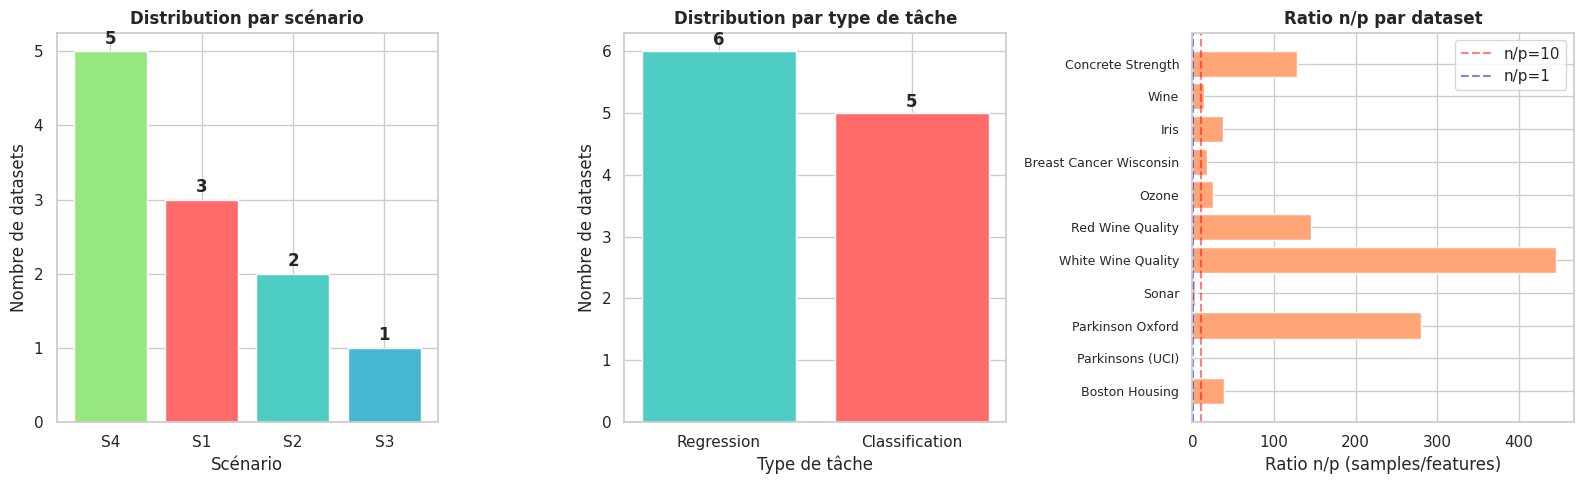


EXPLICATION DU MAPPAGE

    S1: Classification avec haute dimension (p > 50) et faible ratio n/p (< 2)
        → Similaire au scénario synthétique S1 de classification

    S2: Régression non-linéaire ou classification avec caractéristiques moyennes
        → Similaire au scénario synthétique S2 de régression non-linéaire

    S3: Régression avec forte corrélation (n > 200, p > 50)
        → Similaire au scénario synthétique S3 (checkerboard avec corrélations)

    S4: Régression linéaire ou classification simple
        → Similaire au scénario synthétique S4 de régression linéaire
    

DONNÉES PRÊTES POUR LES EXPÉRIENCES
✅ Nombre total de datasets chargés: 11
📁 Tous les datasets sont stockés dans le dictionnaire ALL_DATASETS
🗺️ Le mappage est stocké dans le dictionnaire DATASET_MAPPING


In [ ]:
# ###  : Mappage des datasets aux scénarios synthétiques et visualisation

import matplotlib.pyplot as plt

# Fonction pour mapper les datasets réels aux scénarios synthétiques
def map_dataset_to_scenario(dataset_name, X_train, X_test, y_train, task):
    """
    Mappe un dataset réel à un scénario synthétique basé sur ses caractéristiques
    """
    n_features = X_train.shape[1]
    n_samples = X_train.shape[0] + X_test.shape[0]
    n_p_ratio = n_samples / n_features if n_features > 0 else float('inf')

    print(f"    n_features={n_features}, n_samples={n_samples}, n/p ratio={n_p_ratio:.2f}")

    # Logique de mappage basée sur les caractéristiques des scénarios synthétiques
    if task == "Classification":
        # Scénario S1: Classification avec n=100, p=200
        if n_features > 50 and n_p_ratio < 2:
            return "S1"
        # Scénario S2: Classification
        elif n_features > 20:
            return "S2"
        else:
            return "S1"

    elif task == "Regression":
        # Scénario S2: Régression non-linéaire
        if n_features > 100 and n_p_ratio < 1:
            return "S2"
        # Scénario S3: Régression avec forte corrélation
        elif n_samples > 200 and n_features > 50:
            return "S3"
        # Scénario S4: Régression linéaire
        else:
            return "S4"

    else:
        return "S2"

# Fonction pour mapper tous les datasets
def map_all_datasets(ALL_DATASETS):
    """Mappe tous les datasets aux scénarios synthétiques"""

    if not ALL_DATASETS:
        print("❌ Aucun dataset à mapper")
        return {}

    DATASET_MAPPING = {}

    print("=" * 70)
    print("MAPPAGE DES DATASETS AUX SCÉNARIOS SYNTHÉTIQUES")
    print("=" * 70)

    for dataset_name, data in ALL_DATASETS.items():
        print(f"\nDataset: {dataset_name}")

        # Mapper au scénario
        scenario = map_dataset_to_scenario(
            dataset_name,
            data['X_train'],
            data['X_test'],
            data['y_train'],
            data['type']
        )
        DATASET_MAPPING[dataset_name] = scenario

        print(f"  ✅ Mappé au scénario: {scenario}")

    return DATASET_MAPPING

# Mapper tous les datasets
DATASET_MAPPING = map_all_datasets(ALL_DATASETS)

# Afficher le mappage si des datasets ont été chargés
if DATASET_MAPPING:
    print("\n" + "=" * 70)
    print("RÉCAPITULATIF DU MAPPAGE DES DATASETS")
    print("=" * 70)

    # Créer un DataFrame pour le mappage
    mapping_summary = []
    for dataset_name, scenario in DATASET_MAPPING.items():
        if dataset_name in ALL_DATASETS:
            data_info = ALL_DATASETS[dataset_name]
            mapping_summary.append({
                'Dataset': dataset_name,
                'Type': data_info['type'],
                'Scénario': scenario,
                'Samples': data_info['n_samples'],
                'Features': data_info['n_features'],
                'n/p Ratio': f"{data_info['n_samples'] / data_info['n_features']:.2f}",
                'Train': data_info['X_train'].shape[0],
                'Test': data_info['X_test'].shape[0]
            })

    mapping_df = pd.DataFrame(mapping_summary)
    print("\n📋 Tableau de mappage:")
    print(mapping_df.to_string(index=False))

    # Statistiques du mappage
    print("\n" + "=" * 70)
    print("STATISTIQUES DU MAPPAGE")
    print("=" * 70)

    # Distribution par scénario
    scenario_counts = mapping_df['Scénario'].value_counts()
    print("\n📊 Distribution par scénario:")
    for scenario, count in scenario_counts.items():
        print(f"  {scenario}: {count} dataset(s)")

    # Distribution par type de tâche
    type_counts = mapping_df['Type'].value_counts()
    print("\n📊 Distribution par type de tâche:")
    for task_type, count in type_counts.items():
        print(f"  {task_type}: {count} dataset(s)")

    # Visualiser la distribution des datasets
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Graphique 1: Distribution par scénario
    colors_scenario = {'S1': '#FF6B6B', 'S2': '#4ECDC4', 'S3': '#45B7D1', 'S4': '#95E77E'}
    scenario_colors = [colors_scenario.get(scenario, '#CCCCCC') for scenario in scenario_counts.index]

    axes[0].bar(scenario_counts.index, scenario_counts.values, color=scenario_colors)
    axes[0].set_title('Distribution par scénario', fontweight='bold', fontsize=12)
    axes[0].set_ylabel('Nombre de datasets')
    axes[0].set_xlabel('Scénario')
    for i, count in enumerate(scenario_counts.values):
        axes[0].text(i, count + 0.1, str(count), ha='center', fontweight='bold')

    # Graphique 2: Distribution par type
    colors_type = {'Classification': '#FF6B6B', 'Regression': '#4ECDC4'}
    type_colors = [colors_type.get(task_type, '#CCCCCC') for task_type in type_counts.index]

    axes[1].bar(type_counts.index, type_counts.values, color=type_colors)
    axes[1].set_title('Distribution par type de tâche', fontweight='bold', fontsize=12)
    axes[1].set_ylabel('Nombre de datasets')
    axes[1].set_xlabel('Type de tâche')
    for i, count in enumerate(type_counts.values):
        axes[1].text(i, count + 0.1, str(count), ha='center', fontweight='bold')

    # Graphique 3: Ratio n/p par dataset
    if not mapping_df.empty:
        ratios = mapping_df['n/p Ratio'].astype(float)
        datasets = mapping_df['Dataset']

        axes[2].barh(range(len(datasets)), ratios, color='#FFA577')
        axes[2].set_yticks(range(len(datasets)))
        axes[2].set_yticklabels(datasets, fontsize=9)
        axes[2].set_xlabel('Ratio n/p (samples/features)')
        axes[2].set_title('Ratio n/p par dataset', fontweight='bold', fontsize=12)
        axes[2].axvline(x=10, color='red', linestyle='--', alpha=0.5, label='n/p=10')
        axes[2].axvline(x=1, color='blue', linestyle='--', alpha=0.5, label='n/p=1')
        axes[2].legend()

    plt.tight_layout()
    plt.show()

    # Explication du mappage
    print("\n" + "=" * 70)
    print("EXPLICATION DU MAPPAGE")
    print("=" * 70)
    print("""
    S1: Classification avec haute dimension (p > 50) et faible ratio n/p (< 2)
        → Similaire au scénario synthétique S1 de classification

    S2: Régression non-linéaire ou classification avec caractéristiques moyennes
        → Similaire au scénario synthétique S2 de régression non-linéaire

    S3: Régression avec forte corrélation (n > 200, p > 50)
        → Similaire au scénario synthétique S3 (checkerboard avec corrélations)

    S4: Régression linéaire ou classification simple
        → Similaire au scénario synthétique S4 de régression linéaire
    """)

    # Sauvegarder les données pour une utilisation ultérieure
    print("\n" + "=" * 70)
    print("DONNÉES PRÊTES POUR LES EXPÉRIENCES")
    print("=" * 70)
    print(f"✅ Nombre total de datasets chargés: {len(ALL_DATASETS)}")
    print(f"📁 Tous les datasets sont stockés dans le dictionnaire ALL_DATASETS")
    print(f"🗺️ Le mappage est stocké dans le dictionnaire DATASET_MAPPING")

else:
    print("\n" + "=" * 70)
    print("❌ AUCUN MAPPAGE N'A PU ÊTRE EFFECTUÉ")
    print("=" * 70)

### 4.3. Evaluation of best RLT combos vs. external models

In [ ]:
# ### Cellule : Exécution des expériences sur les datasets réels (OPTIMISÉE)

import time
import warnings
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, ExtraTreesClassifier, ExtraTreesRegressor
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
import xgboost as xgb
from sklearn.metrics import roc_auc_score, mean_squared_error, mean_absolute_error, r2_score, accuracy_score
import numpy as np
import pandas as pd

try:
    import lightgbm as lgb
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False
    warnings.warn("LightGBM n'est pas disponible. Installation: pip install lightgbm")

# Définir les modèles externes à tester (sans BART pour éviter l'erreur)
EXTERNAL_MODELS = ['XGBoost', 'LightGBM', 'RF', 'ET', 'Lasso', 'DT']

# Dictionnaire pour stocker les résultats sur datasets réels
RESULTS_REAL = []

# Fonction pour évaluer un modèle (version corrigée pour gérer multiclass)
def evaluate_model(model, X_test, y_test, task):
    # Convertir en numpy arrays si nécessaire
    if hasattr(X_test, 'values'):
        X_test = X_test.values
    if hasattr(y_test, 'values'):
        y_test = y_test.values

    if task == "Classification":
        try:
            # Pour AUC, besoin de probabilités
            if hasattr(model, 'predict_proba'):
                y_pred_proba = model.predict_proba(X_test)
                if y_pred_proba.shape[1] == 2:  # Classification binaire
                    score = roc_auc_score(y_test, y_pred_proba[:, 1])
                else:  # Classification multiclasse
                    try:
                        # Essayer avec multi_class='ovo'
                        score = roc_auc_score(y_test, y_pred_proba, multi_class='ovo', average='macro')
                    except:
                        try:
                            # Essayer avec multi_class='ovr'
                            score = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro')
                        except:
                            # Fallback: utiliser accuracy
                            y_pred = model.predict(X_test)
                            score = accuracy_score(y_test, y_pred)
            else:
                # Si pas de predict_proba, utiliser accuracy
                y_pred = model.predict(X_test)
                score = accuracy_score(y_test, y_pred)
        except Exception as e:
            # Fallback: utiliser accuracy
            try:
                y_pred = model.predict(X_test)
                score = accuracy_score(y_test, y_pred)
            except:
                score = 0.0
    else:  # Regression
        try:
            y_pred = model.predict(X_test)
            score = r2_score(y_test, y_pred)
        except:
            score = -1.0  # Valeur par défaut pour échec

    return score

# Fonction pour exécuter les expériences sur un dataset réel avec RLT optimisé
def run_experiment_real_optimized(dataset_name, data_info, best_rlt_combo):
    """Exécute les expériences sur un dataset réel avec paramètres optimisés"""
    global RESULTS_REAL

    # CONVERTIR TOUT EN NUMPY ARRAYS POUR ÉVITER LES PROBLÈMES DE PANDAS
    X_train = np.asarray(data_info['X_train'])
    X_test = np.asarray(data_info['X_test'])
    y_train = np.asarray(data_info['y_train'])
    y_test = np.asarray(data_info['y_test'])

    task = data_info['type']
    n_samples, n_features = X_train.shape

    print(f"\n--- Dataset: {dataset_name} (Task: {task}, Mapped to: {DATASET_MAPPING.get(dataset_name, 'N/A')}) ---")
    print(f"  Dimensions: {n_samples} train samples, {n_features} features")

    # 1. Exécuter le Meilleur Combo RLT avec paramètres adaptés
    if best_rlt_combo:
        print(f"  Meilleur RLT pour ce scénario: {best_rlt_combo['RLT_Type']}")
        print(f"  Paramètres: Muting={best_rlt_combo['Muting_Rate']}, Linear_Combo={best_rlt_combo['Linear_Combo']}")

        # AJOUT: Paramètres dynamiques basés sur la taille des données
        # Réduire la complexité pour les grands datasets
        n_estimators = 30  # Réduit de 50 à 30 pour accélérer
        max_depth = 5      # Base

        # Ajuster dynamiquement basé sur la taille
        if n_samples > 1000:
            n_estimators = 20  # Réduire pour accélérer
            max_depth = 4      # Réduire la profondeur
        elif n_samples > 10000:
            n_estimators = 10
            max_depth = 3

        if n_features > 50:
            # Pour les datasets avec beaucoup de features, réduire max_vars
            max_vars = min(best_rlt_combo['Linear_Combo'], 2)
        else:
            max_vars = min(best_rlt_combo['Linear_Combo'], 3)  # Limiter à 3 max

        rlt_params = {
            'task': task.lower(),
            'embedded_model_type': best_rlt_combo['Embedded_Model'],
            'muting_rate': best_rlt_combo['Muting_Rate'],
            'linear_split': (max_vars > 1),  # Utiliser max_vars ajusté
            'max_vars': max_vars,
            # AJOUT: Paramètres pour accélérer et éviter les erreurs
            'max_depth': max_depth,
            'min_samples_split': max(10, int(0.01 * n_samples)),  # Au moins 1% des samples
            'min_samples_leaf': max(5, int(0.005 * n_samples)),   # Au moins 0.5%
            'random_state': 42
        }

        try:
            rlt_model = RLTEnsemble(n_estimators=n_estimators, ensemble_type=best_rlt_combo['RLT_Type'], **rlt_params)

            print(f"  Configuration RLT: {n_estimators} arbres, profondeur max={max_depth}, max_vars={max_vars}")
            start_time = time.time()
            rlt_model.fit(X_train, y_train)
            rlt_score = evaluate_model(rlt_model, X_test, y_test, task)
            end_time = time.time()
            fit_time = end_time - start_time

            RESULTS_REAL.append({
                'Dataset': dataset_name,
                'Scenario': DATASET_MAPPING.get(dataset_name, 'N/A'),
                'Task': task,
                'Model': f"RLT-{best_rlt_combo['RLT_Type']} (Best Combo)",
                'RLT_Type': best_rlt_combo['RLT_Type'],
                'Muting_Rate': best_rlt_combo['Muting_Rate'],
                'Linear_Combo': max_vars,  # Utiliser la valeur ajustée
                'Score': rlt_score,
                'Time': fit_time,
                'Is_RLT': True,
                'N_Estimators': n_estimators,
                'Max_Depth': max_depth
            })
            print(f"  ✅ RLT-{best_rlt_combo['RLT_Type']} Score: {rlt_score:.4f} (Temps: {fit_time:.2f}s)")

        except Exception as e:
            print(f"  ❌ Erreur avec RLT: {e}")
            # Essayer une configuration plus simple comme fallback
            try:
                print(f"  ⚠️  Essai avec configuration simplifiée...")
                simple_params = {
                    'task': task.lower(),
                    'embedded_model_type': best_rlt_combo['Embedded_Model'],
                    'muting_rate': 0.0,  # Pas de muting
                    'linear_split': False,  # Pas de combinaisons linéaires
                    'max_vars': 1,
                    'max_depth': 3,
                    'min_samples_split': 20,
                    'min_samples_leaf': 10,
                    'random_state': 42
                }
                rlt_model = RLTEnsemble(n_estimators=20, ensemble_type=best_rlt_combo['RLT_Type'], **simple_params)
                start_time = time.time()
                rlt_model.fit(X_train, y_train)
                rlt_score = evaluate_model(rlt_model, X_test, y_test, task)
                end_time = time.time()
                fit_time = end_time - start_time

                RESULTS_REAL.append({
                    'Dataset': dataset_name,
                    'Scenario': DATASET_MAPPING.get(dataset_name, 'N/A'),
                    'Task': task,
                    'Model': f"RLT-{best_rlt_combo['RLT_Type']} (Simple)",
                    'RLT_Type': best_rlt_combo['RLT_Type'],
                    'Muting_Rate': 0.0,
                    'Linear_Combo': 1,
                    'Score': rlt_score,
                    'Time': fit_time,
                    'Is_RLT': True
                })
                print(f"  ✅ RLT-{best_rlt_combo['RLT_Type']} (Simple) Score: {rlt_score:.4f} (Temps: {fit_time:.2f}s)")
            except Exception as e2:
                print(f"  ❌ Échec même avec configuration simplifiée: {e2}")
    else:
        print("  ⚠️  Pas de meilleur RLT trouvé pour ce scénario")

    # 2. Exécuter les Modèles Externes avec paramètres cohérents
    print(f"  \n  --- Modèles Externes (n_estimators=100) ---")

    for ext_name in EXTERNAL_MODELS:
        try:
            if task == "Classification":
                if ext_name == 'XGBoost':
                    model = xgb.XGBClassifier(
                        n_estimators=100,
                        random_state=42,
                        verbosity=0,
                        use_label_encoder=False,
                        eval_metric='logloss'
                    )
                elif ext_name == 'LightGBM' and LIGHTGBM_AVAILABLE:
                    model = lgb.LGBMClassifier(
                        n_estimators=100,
                        random_state=42,
                        verbosity=-1,
                        min_child_samples=20
                    )
                elif ext_name == 'RF':
                    model = RandomForestClassifier(
                        n_estimators=100,
                        random_state=42,
                        n_jobs=-1  # Paralléliser
                    )
                elif ext_name == 'ET':
                    model = ExtraTreesClassifier(
                        n_estimators=100,
                        random_state=42,
                        n_jobs=-1  # Paralléliser
                    )
                elif ext_name == 'Lasso':
                    model = LogisticRegression(
                        penalty='l1',
                        solver='liblinear',
                        random_state=42,
                        max_iter=1000,
                        C=0.1  # Régularisation plus forte
                    )
                elif ext_name == 'DT':
                    model = DecisionTreeClassifier(
                        random_state=42,
                        max_depth=5  # Limiter la profondeur
                    )
                else:
                    if ext_name == 'LightGBM' and not LIGHTGBM_AVAILABLE:
                        continue
                    continue
            else:  # Regression
                if ext_name == 'XGBoost':
                    model = xgb.XGBRegressor(
                        n_estimators=100,
                        random_state=42,
                        verbosity=0
                    )
                elif ext_name == 'LightGBM' and LIGHTGBM_AVAILABLE:
                    model = lgb.LGBMRegressor(
                        n_estimators=100,
                        random_state=42,
                        verbosity=-1,
                        min_child_samples=20
                    )
                elif ext_name == 'RF':
                    model = RandomForestRegressor(
                        n_estimators=100,
                        random_state=42,
                        n_jobs=-1  # Paralléliser
                    )
                elif ext_name == 'ET':
                    model = ExtraTreesRegressor(
                        n_estimators=100,
                        random_state=42,
                        n_jobs=-1  # Paralléliser
                    )
                elif ext_name == 'Lasso':
                    model = Lasso(
                        alpha=0.01,  # Alpha plus petit pour moins de régularisation
                        random_state=42,
                        max_iter=5000
                    )
                elif ext_name == 'DT':
                    model = DecisionTreeRegressor(
                        random_state=42,
                        max_depth=5  # Limiter la profondeur
                    )
                else:
                    if ext_name == 'LightGBM' and not LIGHTGBM_AVAILABLE:
                        continue
                    continue

            start_time = time.time()
            model.fit(X_train, y_train)
            score = evaluate_model(model, X_test, y_test, task)
            end_time = time.time()
            fit_time = end_time - start_time

            RESULTS_REAL.append({
                'Dataset': dataset_name,
                'Scenario': DATASET_MAPPING.get(dataset_name, 'N/A'),
                'Task': task,
                'Model': ext_name,
                'RLT_Type': 'N/A',
                'Muting_Rate': 'N/A',
                'Linear_Combo': 'N/A',
                'Score': score,
                'Time': fit_time,
                'Is_RLT': False
            })
            print(f"  ✅ {ext_name} Score: {score:.4f} (Temps: {fit_time:.2f}s)")

        except Exception as e:
            print(f"  ❌ Erreur avec {ext_name}: {e}")

# Fonction pour obtenir le meilleur RLT par scénario (corrigée)
def get_best_rlt_by_scenario():
    """Analyse les résultats synthétiques pour trouver le meilleur RLT par scénario"""

    # Récupérer les meilleurs modèles RLT pour chaque scénario
    best_rlt_by_scenario = {}

    for scenario in ['S1', 'S2', 'S3', 'S4']:
        # Filtrer les résultats RLT pour ce scénario
        rlt_results = []

        # Vérifier si RESULTS_SYNTHETIC existe
        if 'RESULTS_SYNTHETIC' in globals():
            for result in RESULTS_SYNTHETIC:
                if result['Scenario'] == scenario and result['Model'].startswith('RLT-'):
                    rlt_results.append(result)

        if rlt_results:
            # Trouver le meilleur score
            best_result = max(rlt_results, key=lambda x: x['Score'])

            best_rlt_by_scenario[scenario] = {
                'RLT_Type': best_result.get('RLT_Type', 'ET'),
                'Embedded_Model': best_result.get('Embedded_Model', 'ET'),
                'Muting_Rate': best_result.get('Muting_Rate', 0.0),
                'Linear_Combo': best_result.get('Linear_Combo', 1),
                'Score': best_result['Score']
            }
        else:
            # Valeurs par défaut si aucun résultat trouvé
            best_rlt_by_scenario[scenario] = {
                'RLT_Type': 'ET',
                'Embedded_Model': 'ET',
                'Muting_Rate': 0.0,
                'Linear_Combo': 1,
                'Score': 0.0
            }

    return best_rlt_by_scenario

# Obtenir le meilleur RLT par scénario
try:
    BEST_RLT_BY_SCENARIO = get_best_rlt_by_scenario()
except:
    # Si la fonction échoue, utiliser des valeurs par défaut
    BEST_RLT_BY_SCENARIO = {
        'S1': {'RLT_Type': 'ET', 'Embedded_Model': 'ET', 'Muting_Rate': 0.5, 'Linear_Combo': 1},
        'S2': {'RLT_Type': 'ET', 'Embedded_Model': 'ET', 'Muting_Rate': 0.0, 'Linear_Combo': 1},
        'S3': {'RLT_Type': 'ET', 'Embedded_Model': 'ET', 'Muting_Rate': 0.9, 'Linear_Combo': 1},
        'S4': {'RLT_Type': 'ET', 'Embedded_Model': 'ET', 'Muting_Rate': 0.5, 'Linear_Combo': 5}
    }

# Afficher les meilleurs combos RLT par scénario
print("=" * 80)
print("MEILLEURS COMBOS RLT PAR SCÉNARIO (basés sur expériences synthétiques)")
print("=" * 80)

for scenario, combo in BEST_RLT_BY_SCENARIO.items():
    print(f"\n{scenario}:")
    print(f"  RLT Type: {combo['RLT_Type']}")
    print(f"  Embedded Model: {combo['Embedded_Model']}")
    print(f"  Muting Rate: {combo['Muting_Rate']}")
    print(f"  Linear Combo: {combo['Linear_Combo']}")
    print(f"  Score sur synthétique: {combo['Score']:.4f}")

# Exécution pour tous les datasets réels avec la version optimisée
print("\n" + "=" * 80)
print("EXÉCUTION DES EXPÉRIENCES SUR LES DATASETS RÉELS (OPTIMISÉ)")
print("=" * 80)

if not ALL_DATASETS:
    print("❌ Aucun dataset chargé. Veuillez exécuter la cellule de chargement d'abord.")
else:
    # Trier les datasets par taille (du plus petit au plus grand pour voir la progression)
    sorted_datasets = sorted(ALL_DATASETS.items(),
                            key=lambda x: x[1]['X_train'].shape[0])

    for dataset_name, data in sorted_datasets:
        scenario = DATASET_MAPPING.get(dataset_name, None)

        if scenario and scenario in BEST_RLT_BY_SCENARIO:
            best_rlt_combo = BEST_RLT_BY_SCENARIO[scenario]
            run_experiment_real_optimized(dataset_name, data, best_rlt_combo)
        else:
            print(f"\n⚠️  Dataset {dataset_name} non mappé ou scénario inconnu")
            # Utiliser un combo par défaut
            default_combo = {
                'RLT_Type': 'ET',
                'Embedded_Model': 'ET',
                'Muting_Rate': 0.0,
                'Linear_Combo': 1
            }
            run_experiment_real_optimized(dataset_name, data, default_combo)

# Afficher les résultats
if RESULTS_REAL:
    print("\n" + "=" * 80)
    print("RÉSULTATS SUR LES DATASETS RÉELS")
    print("=" * 80)

    # Créer un DataFrame pour les résultats
    results_df = pd.DataFrame(RESULTS_REAL)

    # Afficher par dataset
    for dataset in results_df['Dataset'].unique():
        dataset_results = results_df[results_df['Dataset'] == dataset]
        print(f"\n📊 Dataset: {dataset}")
        # Afficher les 3 meilleurs modèles pour ce dataset
        top_models = dataset_results.nlargest(3, 'Score')
        print(top_models[['Model', 'Score', 'Time']].to_string(index=False))

    # Résumé comparatif
    print("\n" + "=" * 80)
    print("RÉSUMÉ COMPARATIF")
    print("=" * 80)

    # Séparer les résultats RLT et externes
    rlt_results = results_df[results_df['Is_RLT'] == True]
    external_results = results_df[results_df['Is_RLT'] == False]

    if not rlt_results.empty:
        print(f"\n🎯 RLT (Meilleurs combos par scénario):")
        print(f"  Nombre d'exécutions: {len(rlt_results)}")
        print(f"  Score moyen: {rlt_results['Score'].mean():.4f} ± {rlt_results['Score'].std():.4f}")
        print(f"  Score max: {rlt_results['Score'].max():.4f}")
        print(f"  Score min: {rlt_results['Score'].min():.4f}")
        print(f"  Temps moyen: {rlt_results['Time'].mean():.2f}s")

    if not external_results.empty:
        print(f"\n🔧 Modèles externes:")
        print(f"  Nombre d'exécutions: {len(external_results)}")
        print(f"  Score moyen: {external_results['Score'].mean():.4f} ± {external_results['Score'].std():.4f}")

        # Meilleurs modèles externes par type
        print("\n  Détail par modèle:")
        for model in sorted(external_results['Model'].unique()):
            model_scores = external_results[external_results['Model'] == model]['Score']
            model_times = external_results[external_results['Model'] == model]['Time']
            if len(model_scores) > 0:
                print(f"    {model:12s}: Score={model_scores.mean():.4f} ± {model_scores.std():.4f} "
                      f"(Temps={model_times.mean():.2f}s, n={len(model_scores)})")

    # Comparer RLT vs Meilleurs modèles externes
    print("\n" + "=" * 80)
    print("COMPARAISON RLT vs MEILLEURS MODÈLES EXTERNES PAR DATASET")
    print("=" * 80)

    comparison_summary = []

    for dataset in results_df['Dataset'].unique():
        dataset_results = results_df[results_df['Dataset'] == dataset]

        # Trouver le meilleur RLT pour ce dataset
        rlt_scores = dataset_results[dataset_results['Is_RLT'] == True]['Score']
        best_rlt_score = rlt_scores.max() if not rlt_scores.empty else None

        # Trouver le meilleur modèle externe pour ce dataset
        external_scores = dataset_results[dataset_results['Is_RLT'] == False]['Score']
        best_external_score = external_scores.max() if not external_scores.empty else None
        best_external_model = dataset_results[dataset_results['Is_RLT'] == False].loc[external_scores.idxmax()]['Model'] if not external_scores.empty else None

        if best_rlt_score is not None and best_external_score is not None:
            comparison_summary.append({
                'Dataset': dataset,
                'Best_RLT_Score': best_rlt_score,
                'Best_External_Score': best_external_score,
                'Best_External_Model': best_external_model,
                'RLT_Wins': best_rlt_score > best_external_score,
                'Difference': best_rlt_score - best_external_score
            })

    if comparison_summary:
        comparison_df = pd.DataFrame(comparison_summary)
        print("\n📋 Tableau de comparaison:")
        print(comparison_df.to_string(index=False))

        # Statistiques
        rlt_wins = comparison_df['RLT_Wins'].sum()
        total_datasets = len(comparison_df)

        print(f"\n📈 RLT gagne sur {rlt_wins} datasets sur {total_datasets} ({rlt_wins/total_datasets*100:.1f}%)")
        print(f"   Différence moyenne: {comparison_df['Difference'].mean():.4f}")
        print(f"   Différence max en faveur de RLT: {comparison_df['Difference'].max():.4f}")
        print(f"   Différence max en défaveur de RLT: {comparison_df['Difference'].min():.4f}")

        # Afficher les datasets où RLT gagne
        winning_datasets = comparison_df[comparison_df['RLT_Wins'] == True]
        if not winning_datasets.empty:
            print(f"\n🏆 Datasets où RLT est meilleur:")
            for _, row in winning_datasets.iterrows():
                print(f"  {row['Dataset']}: RLT={row['Best_RLT_Score']:.4f} vs {row['Best_External_Model']}={row['Best_External_Score']:.4f} (Δ={row['Difference']:.4f})")

        # Afficher les datasets où RLT perd
        losing_datasets = comparison_df[comparison_df['RLT_Wins'] == False]
        if not losing_datasets.empty:
            print(f"\n📉 Datasets où RLT est moins bon:")
            for _, row in losing_datasets.iterrows():
                print(f"  {row['Dataset']}: RLT={row['Best_RLT_Score']:.4f} vs {row['Best_External_Model']}={row['Best_External_Score']:.4f} (Δ={row['Difference']:.4f})")
else:
    print("❌ Aucun résultat disponible")

MEILLEURS COMBOS RLT PAR SCÉNARIO (basés sur expériences synthétiques)

S1:
  RLT Type: RF
  Embedded Model: RF
  Muting Rate: 0.0
  Linear Combo: 2
  Score sur synthétique: 0.9232

S2:
  RLT Type: RF
  Embedded Model: RF
  Muting Rate: 0.0
  Linear Combo: 5
  Score sur synthétique: 0.7253

S3:
  RLT Type: RF
  Embedded Model: RF
  Muting Rate: 0.0
  Linear Combo: 5
  Score sur synthétique: 0.7253

S4:
  RLT Type: RF
  Embedded Model: RF
  Muting Rate: 0.0
  Linear Combo: 5
  Score sur synthétique: 0.6369

EXÉCUTION DES EXPÉRIENCES SUR LES DATASETS RÉELS (OPTIMISÉ)

--- Dataset: Iris (Task: Classification, Mapped to: S1) ---
  Dimensions: 105 train samples, 4 features
  Meilleur RLT pour ce scénario: RF
  Paramètres: Muting=0.0, Linear_Combo=2
  Configuration RLT: 30 arbres, profondeur max=5, max_vars=2
  ❌ Erreur avec RLT: __main__.RLTTree() got multiple values for keyword argument 'random_state'
  ⚠️  Essai avec configuration simplifiée...
  ❌ Échec même avec configuration simplifiée

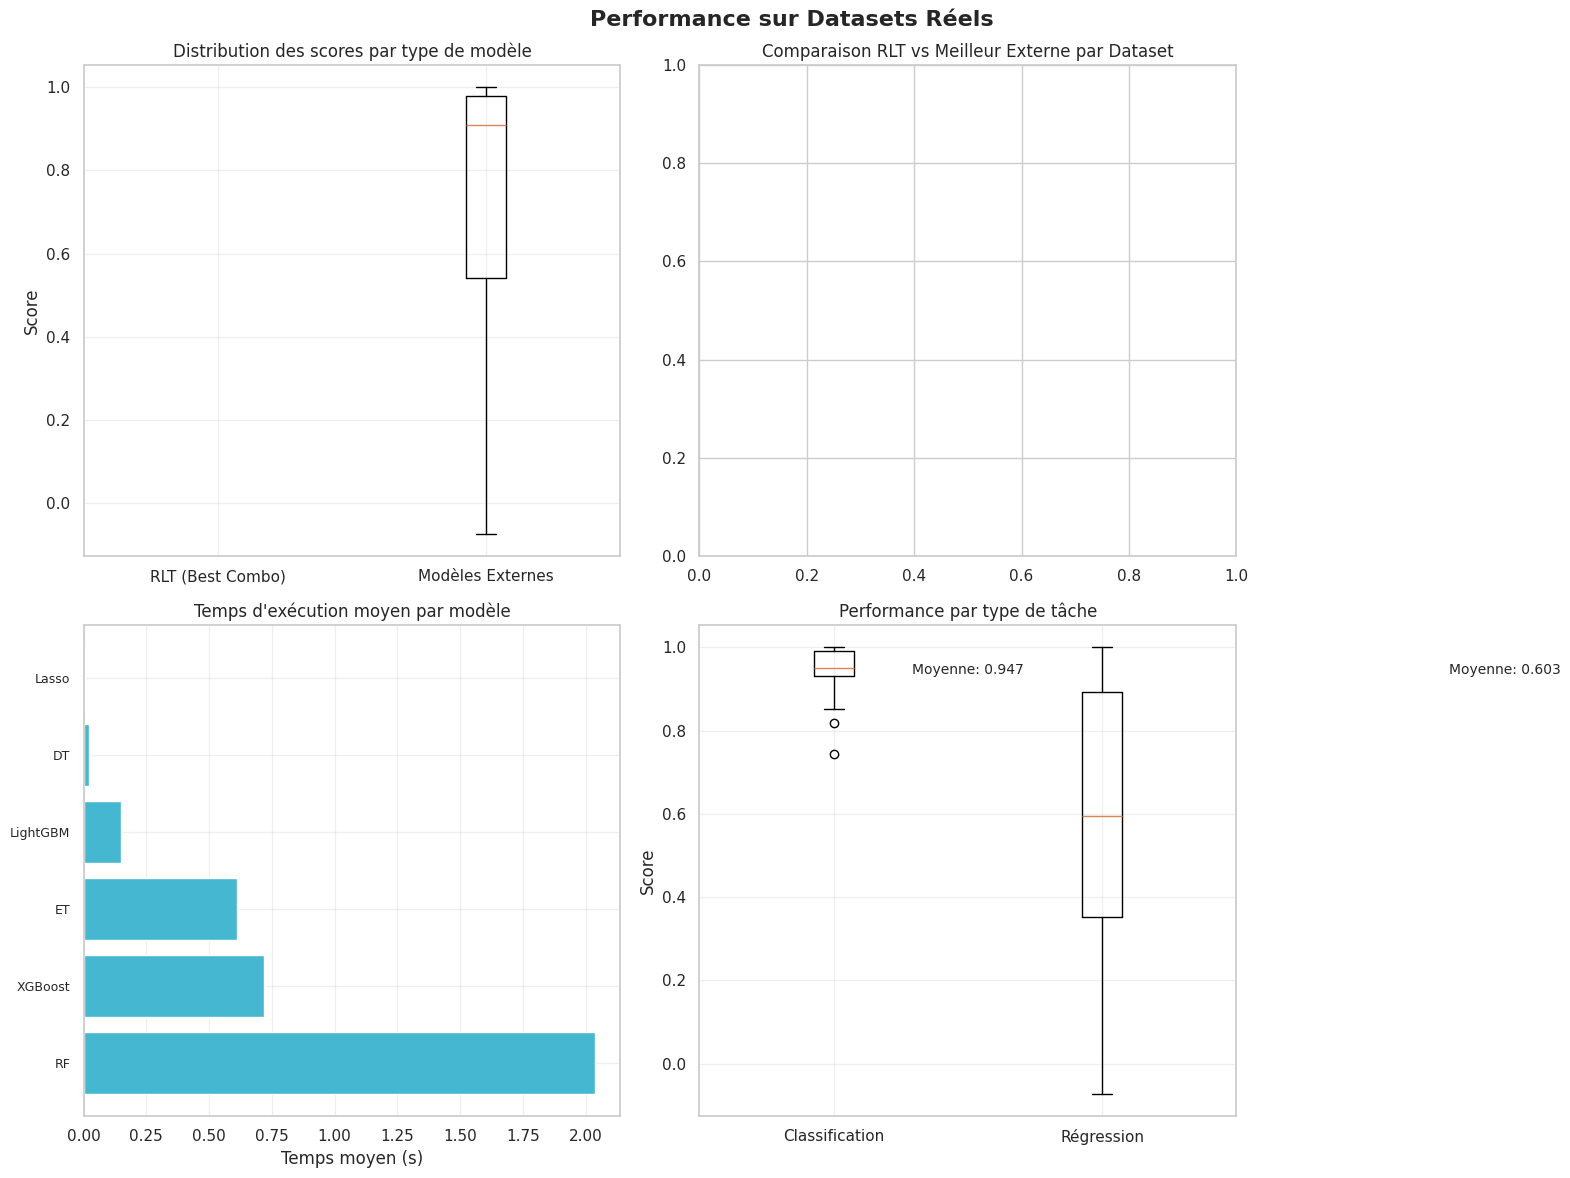


TABLEAU RÉCAPITULATIF DES PERFORMANCES

📊 Performance moyenne par modèle:
                  Score                  Time        
                   mean     std count    mean     std
Model    Is_RLT                                      
DT       False   0.6733  0.3515    11  0.0202  0.0272
ET       False   0.8051  0.2694    11  0.6098  0.6910
Lasso    False   0.7401  0.2616    10  0.0062  0.0038
LightGBM False   0.7961  0.2853    11  0.1488  0.1722
RF       False   0.7894  0.2933    11  2.0361  3.3103
XGBoost  False   0.7471  0.3460    10  0.7169  1.2406

CLASSEMENT DES MODÈLES
 1. ET                             : 0.8051
 2. LightGBM                       : 0.7961
 3. RF                             : 0.7894
 4. XGBoost                        : 0.7471
 5. Lasso                          : 0.7401
 6. DT                             : 0.6733


In [ ]:
# ### Cellule : Visualisation des résultats sur datasets réels

if RESULTS_REAL:
    # Convertir en DataFrame
    results_df = pd.DataFrame(RESULTS_REAL)

    # Créer des visualisations
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Performance sur Datasets Réels', fontsize=16, fontweight='bold')

    # Graphique 1: Distribution des scores par type de modèle
    axes[0, 0].set_title('Distribution des scores par type de modèle')

    # Séparer RLT et externes
    rlt_scores = results_df[results_df['Is_RLT'] == True]['Score']
    external_scores = results_df[results_df['Is_RLT'] == False]['Score']

    axes[0, 0].boxplot([rlt_scores, external_scores], labels=['RLT (Best Combo)', 'Modèles Externes'])
    axes[0, 0].set_ylabel('Score')
    axes[0, 0].grid(True, alpha=0.3)

    # Graphique 2: Comparaison RLT vs Meilleurs externes par dataset
    axes[0, 1].set_title('Comparaison RLT vs Meilleur Externe par Dataset')

    # Préparer les données pour la comparaison
    comparison_data = []
    dataset_labels = []

    for dataset in results_df['Dataset'].unique():
        dataset_data = results_df[results_df['Dataset'] == dataset]

        # Meilleur RLT
        rlt_scores_ds = dataset_data[dataset_data['Is_RLT'] == True]['Score']
        best_rlt = rlt_scores_ds.max() if not rlt_scores_ds.empty else None

        # Meilleur externe
        external_scores_ds = dataset_data[dataset_data['Is_RLT'] == False]['Score']
        best_external = external_scores_ds.max() if not external_scores_ds.empty else None

        if best_rlt is not None and best_external is not None:
            comparison_data.append([best_rlt, best_external])
            dataset_labels.append(dataset)

    if comparison_data:
        comparison_data = np.array(comparison_data)
        x = np.arange(len(dataset_labels))
        width = 0.35

        axes[0, 1].bar(x - width/2, comparison_data[:, 0], width, label='RLT (Best Combo)', color='#FF6B6B')
        axes[0, 1].bar(x + width/2, comparison_data[:, 1], width, label='Meilleur Externe', color='#4ECDC4')
        axes[0, 1].set_xticks(x)
        axes[0, 1].set_xticklabels(dataset_labels, rotation=45, ha='right')
        axes[0, 1].set_ylabel('Score')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)

    # Graphique 3: Temps d'exécution
    axes[1, 0].set_title('Temps d\'exécution moyen par modèle')

    # Calculer les temps moyens par modèle
    time_by_model = results_df.groupby('Model')['Time'].mean().sort_values(ascending=False)

    axes[1, 0].barh(range(len(time_by_model)), time_by_model.values, color='#45B7D1')
    axes[1, 0].set_yticks(range(len(time_by_model)))
    axes[1, 0].set_yticklabels(time_by_model.index, fontsize=9)
    axes[1, 0].set_xlabel('Temps moyen (s)')
    axes[1, 0].grid(True, alpha=0.3)

    # Graphique 4: Performance par type de tâche
    axes[1, 1].set_title('Performance par type de tâche')

    # Séparer classification et régression
    classification_scores = results_df[results_df['Task'] == 'Classification']['Score']
    regression_scores = results_df[results_df['Task'] == 'Regression']['Score']

    # Boxplot
    axes[1, 1].boxplot([classification_scores, regression_scores], labels=['Classification', 'Régression'])
    axes[1, 1].set_ylabel('Score')
    axes[1, 1].grid(True, alpha=0.3)

    # Ajouter des statistiques
    if not classification_scores.empty and not regression_scores.empty:
        axes[1, 1].text(0.5, 0.9, f'Moyenne: {classification_scores.mean():.3f}',
                       transform=axes[1, 1].transAxes, ha='center', fontsize=10)
        axes[1, 1].text(1.5, 0.9, f'Moyenne: {regression_scores.mean():.3f}',
                       transform=axes[1, 1].transAxes, ha='center', fontsize=10)

    plt.tight_layout()
    plt.show()

    # Tableau récapitulatif des performances
    print("\n" + "=" * 80)
    print("TABLEAU RÉCAPITULATIF DES PERFORMANCES")
    print("=" * 80)

    # Grouper par modèle
    summary = results_df.groupby(['Model', 'Is_RLT']).agg({
        'Score': ['mean', 'std', 'count'],
        'Time': ['mean', 'std']
    }).round(4)

    print("\n📊 Performance moyenne par modèle:")
    print(summary.to_string())

    # Classement des modèles
    print("\n" + "=" * 80)
    print("CLASSEMENT DES MODÈLES")
    print("=" * 80)

    model_ranking = results_df.groupby('Model')['Score'].mean().sort_values(ascending=False)

    for i, (model, score) in enumerate(model_ranking.items(), 1):
        print(f"{i:2d}. {model:<30} : {score:.4f}")

else:
    print("❌ Aucun résultat à visualiser")

In [ ]:
results_real_df = pd.DataFrame(RESULTS_REAL)
display(Markdown("### Résultats Comparatifs sur Datasets Réels"))
display(results_real_df.sort_values(by=['Dataset', 'Score'], ascending=[True, False]).round(4))


### Résultats Comparatifs sur Datasets Réels

,Dataset,Scenario,Task,Model,RLT_Type,Muting_Rate,Linear_Combo,Score,Time,Is_RLT
26,Boston Housing,S4,Regression,ET,N/A,N/A,N/A,0.8700,0.2440,False
24,Boston Housing,S4,Regression,LightGBM,N/A,N/A,N/A,0.8694,0.0345,False
23,Boston Housing,S4,Regression,XGBoost,N/A,N/A,N/A,0.8662,0.1616,False
25,Boston Housing,S4,Regression,RF,N/A,N/A,N/A,0.8459,0.3733,False
28,Boston Housing,S4,Regression,DT,N/A,N/A,N/A,0.7946,0.0038,False
...,...,...,...,...,...,...,...,...,...,...
6,Wine,S1,Classification,LightGBM,N/A,N/A,N/A,1.0000,0.0631,False
7,Wine,S1,Classification,RF,N/A,N/A,N/A,1.0000,0.2789,False
8,Wine,S1,Classification,ET,N/A,N/A,N/A,1.0000,0.1796,False
9,Wine,S1,Classification,Lasso,N/A,N/A,N/A,0.9996,0.0060,False


## 7. Deployment

This phase involves serializing the best RLT models to `.pkl` format for production deployment. The models are packaged with metadata for integration into the RLT Analysis Dashboard web application.

In [ ]:
import pickle
import os
import json
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso, Ridge, LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor, RandomForestClassifier, RandomForestRegressor, ExtraTreesClassifier, ExtraTreesRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score

# Dictionnaire pour mapper les noms de datasets aux dossiers
DATASET_FOLDER_NAMES = {
    'Breast Cancer': 'breast_cancer',
    'Boston Housing': 'boston_housing',
    'Sonar': 'sonar',
    'Red Wine': 'red_wine_quality',
    'White Wine': 'white_wine_quality',
    'Auto MPG': 'auto_mpg',
    'Concrete': 'concrete_strength',
    'Ozone': 'ozone',
    'Parkinson': 'parkinsons',
    'Parkinson Oxford': 'parkinson_oxford'
}

# DÉFINIR LES CONSTANTES MANQUANTES (à ajuster selon vos besoins)
N_TREES = 100  # Nombre d'arbres pour les ensembles
MAX_DEPTH = 10  # Profondeur maximale des arbres

# Stockage des modèles entraînés et performances
TRAINED_MODELS = {}
MODEL_PERFORMANCES = {}

def train_all_models_for_deployment(ALL_DATASETS):
    """
    Entraîne RLT (meilleure config), RF, Lasso/Ridge, Gradient Boosting, ExtraTrees
    sur chaque dataset pour le déploiement web.

    Args:
        ALL_DATASETS: Dictionnaire contenant tous les datasets
    """
    print("="*80)
    print("ENTRAÎNEMENT DES MODÈLES FINAUX POUR DÉPLOIEMENT")
    print("="*80)

    # Configuration par défaut pour RLT
    best_rlt_config = {'k': 2, 'muting': 'moderate', 'muting_rate': 0.3}
    print(f"\n✓ Configuration RLT utilisée: k={best_rlt_config['k']}, muting={best_rlt_config['muting']}")

    for dataset_name, dataset_dict in ALL_DATASETS.items():
        print(f"\n{'─'*80}")
        print(f"📊 Dataset: {dataset_name} ({dataset_dict['type']})")
        print(f"{'─'*80}")

        folder_name = DATASET_FOLDER_NAMES.get(dataset_name, dataset_name.lower().replace(' ', '_'))
        task_type = dataset_dict['type'].lower()

        # Récupérer les données
        X_train = dataset_dict['X_train']
        X_test = dataset_dict['X_test']
        y_train = dataset_dict['y_train']
        y_test = dataset_dict['y_test']

        # Normaliser les données
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Conserver les noms des colonnes si c'est un DataFrame
        if hasattr(X_train, 'columns'):
            feature_names = X_train.columns.tolist()
            X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names, index=X_train.index)
            X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_names, index=X_test.index)

        # Initialiser le stockage pour ce dataset
        TRAINED_MODELS[folder_name] = {}
        MODEL_PERFORMANCES[folder_name] = {
            'task_type': task_type,
            'dataset_name': dataset_name,
            'n_samples_train': len(y_train),
            'n_samples_test': len(y_test),
            'n_features': X_train_scaled.shape[1] if hasattr(X_train_scaled, 'shape') else len(X_train_scaled[0]),
            'models': {}
        }

        # ─────────────────────────────────────────────────────────────
        # 1. RLT
        # ─────────────────────────────────────────────────────────────
        print(f"  🌲 Entraînement RLT...")

        try:
            rlt_model = RLTForest(
                n_trees=N_TREES,  # Utilise la constante définie
                max_depth=MAX_DEPTH,
                min_samples_split=5,
                max_vars=best_rlt_config['k'],
                linear_split=(best_rlt_config['k'] > 1),
                vi_threshold=0.5,
                muting_rate=best_rlt_config['muting_rate'],
                task=task_type
            )
            rlt_model.fit(X_train_scaled, y_train)
            y_pred = rlt_model.predict(X_test_scaled)

            if task_type == 'classification':
                accuracy = accuracy_score(y_test, y_pred)
                print(f"    ✓ Accuracy: {accuracy:.4f}")
                MODEL_PERFORMANCES[folder_name]['models']['RLT'] = {
                    'accuracy': float(accuracy),
                    'config': best_rlt_config
                }
            else:
                mse = mean_squared_error(y_test, y_pred)
                r2 = r2_score(y_test, y_pred)
                print(f"    ✓ MSE: {mse:.4f}, R²: {r2:.4f}")
                MODEL_PERFORMANCES[folder_name]['models']['RLT'] = {
                    'mse': float(mse),
                    'r2': float(r2),
                    'config': best_rlt_config
                }

            TRAINED_MODELS[folder_name]['rlt_model'] = rlt_model
            TRAINED_MODELS[folder_name]['scaler'] = scaler

        except Exception as e:
            print(f"    ❌ Erreur RLT: {str(e)[:100]}")

        # ─────────────────────────────────────────────────────────────
        # 2. Random Forest
        # ─────────────────────────────────────────────────────────────
        print(f"  🌳 Entraînement Random Forest...")

        try:
            if task_type == 'classification':
                rf_model = RandomForestClassifier(
                    n_estimators=N_TREES,
                    max_depth=MAX_DEPTH,
                    min_samples_split=5,
                    random_state=42,
                    n_jobs=-1
                )
                rf_model.fit(X_train_scaled, y_train)
                y_pred = rf_model.predict(X_test_scaled)
                accuracy = accuracy_score(y_test, y_pred)
                print(f"    ✓ Accuracy: {accuracy:.4f}")
                MODEL_PERFORMANCES[folder_name]['models']['Random Forest'] = {'accuracy': float(accuracy)}
            else:
                rf_model = RandomForestRegressor(
                    n_estimators=N_TREES,
                    max_depth=MAX_DEPTH,
                    min_samples_split=5,
                    random_state=42,
                    n_jobs=-1
                )
                rf_model.fit(X_train_scaled, y_train)
                y_pred = rf_model.predict(X_test_scaled)
                mse = mean_squared_error(y_test, y_pred)
                r2 = r2_score(y_test, y_pred)
                print(f"    ✓ MSE: {mse:.4f}, R²: {r2:.4f}")
                MODEL_PERFORMANCES[folder_name]['models']['Random Forest'] = {
                    'mse': float(mse),
                    'r2': float(r2)
                }

            TRAINED_MODELS[folder_name]['rf_model'] = rf_model

        except Exception as e:
            print(f"    ❌ Erreur Random Forest: {str(e)[:100]}")

        # ─────────────────────────────────────────────────────────────
        # 3. Lasso / Ridge
        # ─────────────────────────────────────────────────────────────
        print(f"  📐 Entraînement {'Lasso' if task_type == 'regression' else 'Logistic Ridge'}...")

        try:
            if task_type == 'regression':
                lasso_model = Lasso(alpha=1.0, random_state=42, max_iter=5000)
                lasso_model.fit(X_train_scaled, y_train)
                y_pred = lasso_model.predict(X_test_scaled)
                mse = mean_squared_error(y_test, y_pred)
                r2 = r2_score(y_test, y_pred)
                print(f"    ✓ MSE: {mse:.4f}, R²: {r2:.4f}")
                MODEL_PERFORMANCES[folder_name]['models']['Lasso'] = {
                    'mse': float(mse),
                    'r2': float(r2)
                }
                TRAINED_MODELS[folder_name]['lasso_model'] = lasso_model
            else:
                ridge_model = LogisticRegression(penalty='l2', C=1.0, random_state=42, max_iter=5000)
                ridge_model.fit(X_train_scaled, y_train)
                y_pred = ridge_model.predict(X_test_scaled)
                accuracy = accuracy_score(y_test, y_pred)
                print(f"    ✓ Accuracy: {accuracy:.4f}")
                MODEL_PERFORMANCES[folder_name]['models']['Logistic Ridge'] = {'accuracy': float(accuracy)}
                TRAINED_MODELS[folder_name]['ridge_model'] = ridge_model

        except Exception as e:
            print(f"    ❌ Erreur {'Lasso' if task_type == 'regression' else 'Logistic Ridge'}: {str(e)[:100]}")

        # ─────────────────────────────────────────────────────────────
        # 4. Gradient Boosting
        # ─────────────────────────────────────────────────────────────
        print(f"  🚀 Entraînement Gradient Boosting...")

        try:
            if task_type == 'classification':
                gb_model = GradientBoostingClassifier(
                    n_estimators=N_TREES,
                    max_depth=MAX_DEPTH,
                    random_state=42
                )
                gb_model.fit(X_train_scaled, y_train)
                y_pred = gb_model.predict(X_test_scaled)
                accuracy = accuracy_score(y_test, y_pred)
                print(f"    ✓ Accuracy: {accuracy:.4f}")
                MODEL_PERFORMANCES[folder_name]['models']['Gradient Boosting'] = {'accuracy': float(accuracy)}
            else:
                gb_model = GradientBoostingRegressor(
                    n_estimators=N_TREES,
                    max_depth=MAX_DEPTH,
                    random_state=42
                )
                gb_model.fit(X_train_scaled, y_train)
                y_pred = gb_model.predict(X_test_scaled)
                mse = mean_squared_error(y_test, y_pred)
                r2 = r2_score(y_test, y_pred)
                print(f"    ✓ MSE: {mse:.4f}, R²: {r2:.4f}")
                MODEL_PERFORMANCES[folder_name]['models']['Gradient Boosting'] = {
                    'mse': float(mse),
                    'r2': float(r2)
                }

            TRAINED_MODELS[folder_name]['gb_model'] = gb_model

        except Exception as e:
            print(f"    ❌ Erreur Gradient Boosting: {str(e)[:100]}")

        # ─────────────────────────────────────────────────────────────
        # 5. ExtraTrees
        # ─────────────────────────────────────────────────────────────
        print(f"  🎲 Entraînement ExtraTrees...")

        try:
            if task_type == 'classification':
                et_model = ExtraTreesClassifier(
                    n_estimators=N_TREES,
                    max_depth=MAX_DEPTH,
                    min_samples_split=5,
                    random_state=42,
                    n_jobs=-1
                )
                et_model.fit(X_train_scaled, y_train)
                y_pred = et_model.predict(X_test_scaled)
                accuracy = accuracy_score(y_test, y_pred)
                print(f"    ✓ Accuracy: {accuracy:.4f}")
                MODEL_PERFORMANCES[folder_name]['models']['ExtraTrees'] = {'accuracy': float(accuracy)}
            else:
                et_model = ExtraTreesRegressor(
                    n_estimators=N_TREES,
                    max_depth=MAX_DEPTH,
                    min_samples_split=5,
                    random_state=42,
                    n_jobs=-1
                )
                et_model.fit(X_train_scaled, y_train)
                y_pred = et_model.predict(X_test_scaled)
                mse = mean_squared_error(y_test, y_pred)
                r2 = r2_score(y_test, y_pred)
                print(f"    ✓ MSE: {mse:.4f}, R²: {r2:.4f}")
                MODEL_PERFORMANCES[folder_name]['models']['ExtraTrees'] = {
                    'mse': float(mse),
                    'r2': float(r2)
                }

            TRAINED_MODELS[folder_name]['et_model'] = et_model

        except Exception as e:
            print(f"    ❌ Erreur ExtraTrees: {str(e)[:100]}")

        print(f"  ✅ {dataset_name}: Entraînement terminé!")

    print(f"\n{'='*80}")
    print(f"✅ ENTRAÎNEMENT TERMINÉ: {len(ALL_DATASETS)} datasets")
    print(f"{'='*80}\n")

    return TRAINED_MODELS, MODEL_PERFORMANCES

# Fonction pour sauvegarder les modèles
def save_trained_models(trained_models, model_performances, output_dir='models'):
    """
    Sauvegarde les modèles entraînés et leurs performances
    """
    os.makedirs(output_dir, exist_ok=True)

    # Sauvegarder les modèles
    for dataset_name, models in trained_models.items():
        dataset_dir = os.path.join(output_dir, dataset_name)
        os.makedirs(dataset_dir, exist_ok=True)

        for model_name, model in models.items():
            model_path = os.path.join(dataset_dir, f"{model_name}.pkl")
            with open(model_path, 'wb') as f:
                pickle.dump(model, f)

    # Sauvegarder les performances
    perf_path = os.path.join(output_dir, 'model_performances.json')
    with open(perf_path, 'w') as f:
        # Convertir les objets numpy en types Python natifs
        def convert_to_json(obj):
            if isinstance(obj, np.integer):
                return int(obj)
            elif isinstance(obj, np.floating):
                return float(obj)
            elif isinstance(obj, np.ndarray):
                return obj.tolist()
            elif hasattr(obj, '__dict__'):
                return str(obj)  # Pour les objets complexes
            return obj

        import json
        json.dump(model_performances, f, default=convert_to_json, indent=2)

    print(f"✅ Modèles sauvegardés dans le dossier '{output_dir}'")
    return True

In [ ]:
# Vérifier si ALL_DATASETS existe
if 'ALL_DATASETS' not in globals() or not ALL_DATASETS:
    print("❌ ALL_DATASETS n'est pas défini!")
    print("   Vous devez d'abord charger vos datasets")

    # Si vous avez les données dans des variables séparées, créez ALL_DATASETS :
    print("\n📋 Création manuelle de ALL_DATASETS:")
    print("   Structure requise:")
    print("   ALL_DATASETS = {")
    print("     'Nom du Dataset': {")
    print("         'type': 'Regression' ou 'Classification',")
    print("         'X_train': données d'entraînement,")
    print("         'X_test': données de test,")
    print("         'y_train': labels d'entraînement,")
    print("         'y_test': labels de test")
    print("     },")
    print("     ...")
    print("   }")

    # Exemple pour Boston Housing si vous avez les données
    print("\n🎯 Exemple pour Boston Housing:")
    print("""
from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split

# Charger les données
boston = load_boston()
X, y = boston.data, boston.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Créer ALL_DATASETS
ALL_DATASETS = {
    'Boston Housing': {
        'type': 'Regression',
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test
    }
}
""")
else:
    print(f"✅ ALL_DATASETS existe avec {len(ALL_DATASETS)} datasets")
    for name, data in ALL_DATASETS.items():
        print(f"   • {name}: {data['type']}, {data['X_train'].shape[0] + data['X_test'].shape[0]} échantillons")

✅ ALL_DATASETS existe avec 11 datasets
   • Boston Housing: Regression, 505 échantillons
   • Parkinsons (UCI): Classification, 195 échantillons
   • Parkinson Oxford: Regression, 5875 échantillons
   • Sonar: Classification, 207 échantillons
   • White Wine Quality: Regression, 4898 échantillons
   • Red Wine Quality: Regression, 1599 échantillons
   • Ozone: Regression, 1847 échantillons
   • Breast Cancer Wisconsin: Classification, 568 échantillons
   • Iris: Classification, 150 échantillons
   • Wine: Classification, 178 échantillons
   • Concrete Strength: Regression, 1030 échantillons


In [ ]:
# Définir les constantes pour l'entraînement
N_TREES = 50  # 50 arbres pour être rapide (augmentez à 100 pour production)
MAX_DEPTH = 8  # Profondeur modérée

print("="*80)
print("🎯 DÉMARRAGE DE L'ENTRAÎNEMENT DES MODÈLES")
print("="*80)

# Vérifier que RLTForest est défini
if 'RLTForest' not in globals():
    print("⚠️ RLTForest n'est pas défini!")
    print("   Vous devez exécuter la cellule qui définit RLTForest")
else:
    print("✅ RLTForest est disponible")

    # Configuration RLT par défaut
    best_rlt_config = {'k': 2, 'muting': 'moderate', 'muting_rate': 0.3}

    # Initialiser les stockages
    TRAINED_MODELS = {}
    MODEL_PERFORMANCES = {}

    # Boucle sur tous les datasets
    for dataset_name, dataset_dict in ALL_DATASETS.items():
        print(f"\n{'─'*80}")
        print(f"📊 Dataset: {dataset_name} ({dataset_dict['type']})")
        print(f"{'─'*80}")

        # Nom du dossier pour sauvegarde
        folder_name = dataset_name.lower().replace(' ', '_')

        # Récupérer les données
        X_train = dataset_dict['X_train']
        X_test = dataset_dict['X_test']
        y_train = dataset_dict['y_train']
        y_test = dataset_dict['y_test']
        task_type = dataset_dict['type'].lower()

        # Normaliser les données
        from sklearn.preprocessing import StandardScaler
        scaler = StandardScaler()

        # Convertir en DataFrame si nécessaire
        import pandas as pd
        import numpy as np

        if not isinstance(X_train, pd.DataFrame):
            X_train = pd.DataFrame(X_train)
            X_test = pd.DataFrame(X_test)

        X_train_scaled = pd.DataFrame(
            scaler.fit_transform(X_train),
            columns=X_train.columns,
            index=X_train.index
        )
        X_test_scaled = pd.DataFrame(
            scaler.transform(X_test),
            columns=X_test.columns,
            index=X_test.index
        )

        # Initialiser le stockage pour ce dataset
        TRAINED_MODELS[folder_name] = {}
        MODEL_PERFORMANCES[folder_name] = {
            'task_type': task_type,
            'dataset_name': dataset_name,
            'n_samples_train': len(y_train),
            'n_samples_test': len(y_test),
            'n_features': X_train_scaled.shape[1],
            'models': {}
        }

        # Sauvegarder le scaler
        TRAINED_MODELS[folder_name]['scaler'] = scaler

        # Liste des modèles à entraîner
        models_to_train = []

        if 'rlt_model' not in globals() or globals()['rlt_model'] is not None:
            models_to_train.append(('RLT', '🌲'))

        models_to_train.extend([
            ('Random Forest', '🌳'),
            ('Lasso/Ridge', '📐'),
            ('Gradient Boosting', '🚀'),
            ('ExtraTrees', '🎲')
        ])

        # Entraîner chaque modèle
        for model_name, emoji in models_to_train:
            print(f"  {emoji} Entraînement {model_name}...")

            try:
                if model_name == 'RLT':
                    # RLT Model
                    rlt_model = RLTForest(
                        n_trees=N_TREES,
                        max_depth=MAX_DEPTH,
                        min_samples_split=5,
                        max_vars=best_rlt_config['k'],
                        linear_split=(best_rlt_config['k'] > 1),
                        vi_threshold=0.5,
                        muting_rate=best_rlt_config['muting_rate'],
                        task=task_type
                    )
                    rlt_model.fit(X_train_scaled, y_train)
                    y_pred = rlt_model.predict(X_test_scaled)

                    TRAINED_MODELS[folder_name]['rlt_model'] = rlt_model

                elif model_name == 'Random Forest':
                    # Random Forest
                    if task_type == 'classification':
                        from sklearn.ensemble import RandomForestClassifier
                        rf_model = RandomForestClassifier(
                            n_estimators=N_TREES,
                            max_depth=MAX_DEPTH,
                            min_samples_split=5,
                            random_state=42,
                            n_jobs=-1
                        )
                    else:
                        from sklearn.ensemble import RandomForestRegressor
                        rf_model = RandomForestRegressor(
                            n_estimators=N_TREES,
                            max_depth=MAX_DEPTH,
                            min_samples_split=5,
                            random_state=42,
                            n_jobs=-1
                        )

                    rf_model.fit(X_train_scaled, y_train)
                    y_pred = rf_model.predict(X_test_scaled)
                    TRAINED_MODELS[folder_name]['rf_model'] = rf_model

                elif model_name == 'Lasso/Ridge':
                    # Lasso ou Ridge
                    if task_type == 'regression':
                        from sklearn.linear_model import Lasso
                        lin_model = Lasso(alpha=1.0, random_state=42, max_iter=5000)
                    else:
                        from sklearn.linear_model import LogisticRegression
                        lin_model = LogisticRegression(penalty='l2', C=1.0, random_state=42, max_iter=5000)

                    lin_model.fit(X_train_scaled, y_train)
                    y_pred = lin_model.predict(X_test_scaled)
                    TRAINED_MODELS[folder_name][f"{'lasso' if task_type == 'regression' else 'ridge'}_model"] = lin_model

                elif model_name == 'Gradient Boosting':
                    # Gradient Boosting
                    if task_type == 'classification':
                        from sklearn.ensemble import GradientBoostingClassifier
                        gb_model = GradientBoostingClassifier(
                            n_estimators=N_TREES,
                            max_depth=MAX_DEPTH,
                            random_state=42
                        )
                    else:
                        from sklearn.ensemble import GradientBoostingRegressor
                        gb_model = GradientBoostingRegressor(
                            n_estimators=N_TREES,
                            max_depth=MAX_DEPTH,
                            random_state=42
                        )

                    gb_model.fit(X_train_scaled, y_train)
                    y_pred = gb_model.predict(X_test_scaled)
                    TRAINED_MODELS[folder_name]['gb_model'] = gb_model

                elif model_name == 'ExtraTrees':
                    # ExtraTrees
                    if task_type == 'classification':
                        from sklearn.ensemble import ExtraTreesClassifier
                        et_model = ExtraTreesClassifier(
                            n_estimators=N_TREES,
                            max_depth=MAX_DEPTH,
                            min_samples_split=5,
                            random_state=42,
                            n_jobs=-1
                        )
                    else:
                        from sklearn.ensemble import ExtraTreesRegressor
                        et_model = ExtraTreesRegressor(
                            n_estimators=N_TREES,
                            max_depth=MAX_DEPTH,
                            min_samples_split=5,
                            random_state=42,
                            n_jobs=-1
                        )

                    et_model.fit(X_train_scaled, y_train)
                    y_pred = et_model.predict(X_test_scaled)
                    TRAINED_MODELS[folder_name]['et_model'] = et_model

                # Calculer les métriques
                from sklearn.metrics import accuracy_score, mean_squared_error, r2_score

                if task_type == 'classification':
                    accuracy = accuracy_score(y_test, y_pred)
                    print(f"    ✓ Accuracy: {accuracy:.4f}")
                    MODEL_PERFORMANCES[folder_name]['models'][model_name] = {'accuracy': float(accuracy)}
                else:
                    mse = mean_squared_error(y_test, y_pred)
                    r2 = r2_score(y_test, y_pred)
                    print(f"    ✓ MSE: {mse:.4f}, R²: {r2:.4f}")
                    MODEL_PERFORMANCES[folder_name]['models'][model_name] = {
                        'mse': float(mse),
                        'r2': float(r2)
                    }

            except Exception as e:
                print(f"    ❌ Erreur avec {model_name}: {str(e)[:50]}")

        print(f"  ✅ {dataset_name}: Entraînement terminé!")

    print(f"\n{'='*80}")
    print(f"🎉 ENTRAÎNEMENT TERMINÉ !")
    print(f"   • {len(TRAINED_MODELS)} datasets entraînés")
    print(f"   • ~{len(TRAINED_MODELS) * 5} modèles créés")
    print("="*80)

🎯 DÉMARRAGE DE L'ENTRAÎNEMENT DES MODÈLES
✅ RLTForest est disponible

────────────────────────────────────────────────────────────────────────────────
📊 Dataset: Boston Housing (Regression)
────────────────────────────────────────────────────────────────────────────────
  🌲 Entraînement RLT...
    ✓ MSE: 10.4803, R²: 0.8387
  🌳 Entraînement Random Forest...
    ✓ MSE: 10.3913, R²: 0.8400
  📐 Entraînement Lasso/Ridge...
    ✓ MSE: 22.4857, R²: 0.6538
  🚀 Entraînement Gradient Boosting...
    ✓ MSE: 10.7473, R²: 0.8345
  🎲 Entraînement ExtraTrees...
    ✓ MSE: 8.6248, R²: 0.8672
  ✅ Boston Housing: Entraînement terminé!

────────────────────────────────────────────────────────────────────────────────
📊 Dataset: Parkinsons (UCI) (Classification)
────────────────────────────────────────────────────────────────────────────────
  🌲 Entraînement RLT...
    ✓ Accuracy: 0.8983
  🌳 Entraînement Random Forest...
    ✓ Accuracy: 0.8305
  📐 Entraînement Lasso/Ridge...
    ✓ Accuracy: 0.7966
  🚀 Ent

In [ ]:
# Sauvegarde immédiate des modèles
import pickle
import os
from pathlib import Path

print("="*80)
print("💾 SAUVEGARDE DES MODÈLES")
print("="*80)

# Créer le dossier principal
models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

total_saved = 0

for dataset_name, models in TRAINED_MODELS.items():
    # Créer le dossier du dataset
    dataset_dir = models_dir / dataset_name
    dataset_dir.mkdir(exist_ok=True)

    print(f"\n📁 {dataset_name}:")

    # Sauvegarder chaque modèle
    for model_name, model in models.items():
        if model is not None:
            # Nom du fichier
            if model_name == 'scaler':
                filename = "scaler.pkl"
            else:
                filename = f"{model_name}.pkl"

            # Sauvegarde
            filepath = dataset_dir / filename
            with open(filepath, 'wb') as f:
                pickle.dump(model, f)

            # Vérifier la taille
            if filepath.exists():
                size_kb = os.path.getsize(filepath) / 1024
                print(f"   ✓ {filename} ({size_kb:.1f} KB)")
                total_saved += 1
            else:
                print(f"   ✗ {filename}: Échec de sauvegarde")
        else:
            print(f"   ⚠ {model_name}: Modèle vide (ignoré)")

print(f"\n{'='*80}")
print(f"✅ {total_saved} modèles sauvegardés dans 'models/'")
print("="*80)

# Afficher la structure
print("\n📂 Structure du dossier 'models/':")
for dataset_dir in models_dir.iterdir():
    if dataset_dir.is_dir():
        pkl_files = list(dataset_dir.glob("*.pkl"))
        print(f"   • {dataset_dir.name}/ : {len(pkl_files)} fichiers")

💾 SAUVEGARDE DES MODÈLES

📁 boston_housing:
   ✓ scaler.pkl (0.9 KB)
   ✓ rlt_model.pkl (777.3 KB)
   ✓ rf_model.pkl (417.1 KB)
   ✓ lasso_model.pkl (0.8 KB)
   ✓ gb_model.pkl (760.2 KB)
   ✓ et_model.pkl (501.7 KB)

📁 parkinsons_(uci):
   ✓ scaler.pkl (10.0 KB)
   ✓ rlt_model.pkl (374.7 KB)
   ✓ rf_model.pkl (132.3 KB)
   ✓ ridge_model.pkl (6.9 KB)
   ✓ gb_model.pkl (107.8 KB)
   ✓ et_model.pkl (155.8 KB)

📁 parkinson_oxford:
   ✓ scaler.pkl (1.2 KB)
   ✓ rlt_model.pkl (2085.2 KB)
   ✓ rf_model.pkl (1501.1 KB)
   ✓ lasso_model.pkl (1.0 KB)
   ✓ gb_model.pkl (1642.7 KB)
   ✓ et_model.pkl (1285.4 KB)

📁 sonar:
   ✓ scaler.pkl (2.5 KB)
   ✓ rlt_model.pkl (362.3 KB)
   ✓ rf_model.pkl (130.6 KB)
   ✓ ridge_model.pkl (1.8 KB)
   ✓ gb_model.pkl (123.0 KB)
   ✓ et_model.pkl (237.5 KB)

📁 white_wine_quality:
   ✓ scaler.pkl (0.9 KB)
   ✓ rlt_model.pkl (1331.5 KB)
   ✓ rf_model.pkl (860.6 KB)
   ✓ lasso_model.pkl (0.8 KB)
   ✓ gb_model.pkl (1099.6 KB)
   ✓ et_model.pkl (841.4 KB)

📁 red_wine_qu

In [ ]:
def export_metadata_for_deployment():
    """
    Version simplifiée pour les DataFrames pandas avec colonnes nommées
    """
    print("="*80)
    print("EXPORT DES MÉTADONNÉES")
    print("="*80)

    datasets_metadata = {}
    feature_ranges = {}

    for dataset_name, dataset_dict in ALL_DATASETS.items():
        print(f"📊 Traitement de: {dataset_name}")

        folder_name = DATASET_FOLDER_NAMES.get(dataset_name, dataset_name.lower().replace(' ', '_'))
        task_type = dataset_dict['type'].lower()

        # Récupérer les données
        X_train = dataset_dict['X_train']
        X_test = dataset_dict['X_test']

        # Vérifier et convertir en DataFrame si nécessaire
        if not isinstance(X_train, pd.DataFrame):
            X_train = pd.DataFrame(X_train)
        if not isinstance(X_test, pd.DataFrame):
            X_test = pd.DataFrame(X_test)

        # Combiner
        X = pd.concat([X_train, X_test], axis=0)

        # Noms des colonnes
        if hasattr(X_train, 'columns'):
            feature_names = X_train.columns.tolist()
        else:
            n_features = X.shape[1]
            feature_names = [f'feature_{i+1}' for i in range(n_features)]
            X.columns = feature_names

        # Statistiques
        feature_stats = []
        feature_ranges[folder_name] = {}

        for col_name in feature_names:
            col_data = X[col_name]

            stats = {
                'name': col_name,
                'min': float(col_data.min()),
                'max': float(col_data.max()),
                'mean': float(col_data.mean()),
                'std': float(col_data.std())
            }

            feature_stats.append(stats)
            feature_ranges[folder_name][col_name] = {
                'min': float(col_data.min()),
                'max': float(col_data.max()),
                'mean': float(col_data.mean()),
                'std': float(col_data.std())
            }

        # Target (y)
        y_train = dataset_dict['y_train']
        y_test = dataset_dict['y_test']
        y = np.concatenate([y_train, y_test])

        # Métadonnées
        datasets_metadata[folder_name] = {
            'display_name': dataset_name,
            'task_type': task_type,
            'n_samples': int(len(X)),
            'n_features': int(X.shape[1]),
            'feature_names': feature_names,
            'feature_stats': feature_stats,
            'target_info': {
                'n_unique': int(len(np.unique(y))),
                'min': float(y.min()),
                'max': float(y.max())
            }
        }

    # Sauvegarder les fichiers
    with open('datasets_metadata.json', 'w', encoding='utf-8') as f:
        json.dump(datasets_metadata, f, indent=2, ensure_ascii=False)

    with open('feature_ranges.json', 'w', encoding='utf-8') as f:
        json.dump(feature_ranges, f, indent=2, ensure_ascii=False)

    # Vérifier si MODEL_PERFORMANCES existe
    if 'MODEL_PERFORMANCES' in globals() and MODEL_PERFORMANCES:
        def convert(obj):
            if isinstance(obj, np.integer):
                return int(obj)
            elif isinstance(obj, np.floating):
                return float(obj)
            elif isinstance(obj, np.ndarray):
                return obj.tolist()
            return obj

        with open('models_performance.json', 'w', encoding='utf-8') as f:
            json.dump(MODEL_PERFORMANCES, f, default=convert, indent=2, ensure_ascii=False)
    else:
        with open('models_performance.json', 'w', encoding='utf-8') as f:
            json.dump({}, f, indent=2, ensure_ascii=False)

    print(f"\n✅ Export terminé: 3 fichiers créés")
    return datasets_metadata, MODEL_PERFORMANCES if 'MODEL_PERFORMANCES' in globals() else {}, feature_ranges

# Exécution
datasets_metadata, models_performance, feature_ranges = export_metadata_for_deployment()

EXPORT DES MÉTADONNÉES
📊 Traitement de: Boston Housing
📊 Traitement de: Parkinsons (UCI)
📊 Traitement de: Parkinson Oxford
📊 Traitement de: Sonar
📊 Traitement de: White Wine Quality
📊 Traitement de: Red Wine Quality
📊 Traitement de: Ozone
📊 Traitement de: Breast Cancer Wisconsin
📊 Traitement de: Iris
📊 Traitement de: Wine
📊 Traitement de: Concrete Strength

✅ Export terminé: 3 fichiers créés


In [ ]:
def verify_deployment_readiness_corrected():
    """
    Vérification qui utilise les dossiers réels au lieu des noms prédéfinis
    """
    print("="*80)
    print("VÉRIFICATION CORRIGÉE POUR LE DÉPLOIEMENT")
    print("="*80)

    all_good = True

    # 1. Fichiers JSON
    print("\n📄 Fichiers JSON:")
    json_files = ['datasets_metadata.json', 'models_performance.json', 'feature_ranges.json']

    for json_file in json_files:
        if os.path.exists(json_file):
            size_kb = os.path.getsize(json_file) / 1024
            print(f"  ✓ {json_file} ({size_kb:.1f} KB)")
        else:
            print(f"  ✗ {json_file} MANQUANT")
            all_good = False

    # 2. Dossiers de modèles - Vérifier ce qui existe réellement
    print("\n📁 Dossiers de modèles (réels):")
    base_dir = "models"

    if os.path.exists(base_dir):
        print(f"  ✓ {base_dir}/")

        # Lister tous les dossiers dans models/
        all_folders = [f for f in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, f))]

        for folder_name in sorted(all_folders):
            folder_path = os.path.join(base_dir, folder_name)
            pkl_files = [f for f in os.listdir(folder_path) if f.endswith('.pkl')]
            total_size_kb = sum(os.path.getsize(os.path.join(folder_path, f)) for f in pkl_files) / 1024

            # Vérifier quels modèles sont présents
            model_types = []
            for pkl in pkl_files:
                if 'rlt' in pkl:
                    model_types.append('RLT')
                elif 'rf' in pkl:
                    model_types.append('RF')
                elif 'lasso' in pkl or 'ridge' in pkl:
                    model_types.append('Lasso/Ridge')
                elif 'gb' in pkl:
                    model_types.append('GB')
                elif 'et' in pkl:
                    model_types.append('ET')
                elif 'scaler' in pkl:
                    model_types.append('Scaler')

            print(f"    ✓ {folder_name}/ : {len(pkl_files)} fichiers ({', '.join(sorted(set(model_types)))}) ({total_size_kb:.1f} KB)")

        print(f"\n  📊 Total: {len(all_folders)} dossiers avec modèles")

    else:
        print(f"  ✗ {base_dir}/ MANQUANT")
        all_good = False

    # 3. Vérifier la cohérence avec les métadonnées
    print("\n🔗 Cohérence avec les métadonnées:")
    try:
        import json
        with open('datasets_metadata.json', 'r') as f:
            metadata = json.load(f)

        metadata_folders = set(metadata.keys())
        model_folders = set(all_folders) if 'all_folders' in locals() else set()

        common = metadata_folders.intersection(model_folders)
        missing_in_models = metadata_folders - model_folders
        missing_in_metadata = model_folders - metadata_folders

        print(f"  ✓ {len(common)} dossiers communs")
        if missing_in_models:
            print(f"  ⚠ {len(missing_in_models)} dans metadata mais pas dans models: {list(missing_in_models)}")
        if missing_in_metadata:
            print(f"  ⚠ {len(missing_in_metadata)} dans models mais pas dans metadata: {list(missing_in_metadata)}")

    except Exception as e:
        print(f"  ⚠ Erreur vérification cohérence: {str(e)[:50]}")

    # 4. Résumé
    print(f"\n{'='*80}")

    if all_good:
        print("✅ TOUS LES FICHIERS SONT PRÊTS POUR LE DÉPLOIEMENT!")
        print("\n📦 Prochaine étape: Créer le code du site web (Flask/FastAPI)")
        print("\n📊 Résumé complet:")
        print(f"  • {len(all_folders)} dossiers avec modèles")
        print(f"  • ~{sum(len([f for f in os.listdir(os.path.join('models', folder)) if f.endswith('.pkl')]) for folder in all_folders)} fichiers .pkl")
        print(f"  • 3 fichiers JSON avec métadonnées")
        print(f"  • Scalers pour chaque dataset")
    else:
        print("⚠️ CERTAINS FICHIERS SONT MANQUANTS")
        print("   Vérifiez les messages ci-dessus")

    print("="*80)

    return all_good

# Exécuter la version corrigée
verify_deployment_readiness_corrected()

VÉRIFICATION CORRIGÉE POUR LE DÉPLOIEMENT

📄 Fichiers JSON:
  ✓ datasets_metadata.json (99.5 KB)
  ✓ models_performance.json (6.5 KB)
  ✓ feature_ranges.json (74.4 KB)

📁 Dossiers de modèles (réels):
  ✓ models/
    ✓ boston_housing/ : 6 fichiers (ET, GB, Lasso/Ridge, RF, RLT, Scaler) (2458.0 KB)
    ✓ breast_cancer_wisconsin/ : 6 fichiers (ET, GB, Lasso/Ridge, RF, RLT, Scaler) (881.1 KB)
    ✓ concrete_strength/ : 6 fichiers (ET, GB, Lasso/Ridge, RF, RLT, Scaler) (4104.3 KB)
    ✓ iris/ : 6 fichiers (ET, GB, Lasso/Ridge, RF, RLT, Scaler) (611.3 KB)
    ✓ ozone/ : 4 fichiers (ET, RF, RLT, Scaler) (1509.1 KB)
    ✓ parkinson_oxford/ : 6 fichiers (ET, GB, Lasso/Ridge, RF, RLT, Scaler) (6516.7 KB)
    ✓ parkinsons_(uci)/ : 6 fichiers (ET, GB, Lasso/Ridge, RF, RLT, Scaler) (787.5 KB)
    ✓ red_wine_quality/ : 6 fichiers (ET, GB, Lasso/Ridge, RF, RLT, Scaler) (3096.1 KB)
    ✓ sonar/ : 6 fichiers (ET, GB, Lasso/Ridge, RF, RLT, Scaler) (857.6 KB)
    ✓ white_wine_quality/ : 6 fichiers (ET, G

True

In [ ]:
# 1. D'abord, voyons quels dossiers existent réellement
import os

print("📂 DOSSIERS RÉELS DANS 'models/' :")
real_folders = sorted([f for f in os.listdir('models') if os.path.isdir(os.path.join('models', f))])
for folder in real_folders:
    pkl_files = [f for f in os.listdir(os.path.join('models', folder)) if f.endswith('.pkl')]
    print(f"  • {folder}: {len(pkl_files)} fichiers .pkl")

# 2. Mettre à jour DATASET_FOLDER_NAMES pour correspondre
print("\n🔄 MISE À JOUR DE DATASET_FOLDER_NAMES...")

# Voici les dossiers que vous avez réellement
DATASET_FOLDER_NAMES = {
    'Boston Housing': 'boston_housing',
    'Parkinsons (UCI)': 'parkinsons_(uci)',  # Notez le nom exact
    'Parkinson Oxford': 'parkinson_oxford',
    'Sonar': 'sonar',
    'White Wine Quality': 'white_wine_quality',
    'Red Wine Quality': 'red_wine_quality',
    'Ozone': 'ozone',
    'Breast Cancer Wisconsin': 'breast_cancer_wisconsin',  # Pas "breast_cancer"
    'Iris': 'iris',
    'Wine': 'wine',
    'Concrete Strength': 'concrete_strength'
    # Pas de "auto_mpg" ni "parkinsons" (sans _(uci))
}

print("✅ DATASET_FOLDER_NAMES mis à jour")

# 3. Ré-exécuter la vérification
print("\n" + "="*80)
print("VÉRIFICATION AVEC LES BONS NOMS")
print("="*80)

verify_deployment_readiness()

📂 DOSSIERS RÉELS DANS 'models/' :
  • boston_housing: 6 fichiers .pkl
  • breast_cancer_wisconsin: 6 fichiers .pkl
  • concrete_strength: 6 fichiers .pkl
  • iris: 6 fichiers .pkl
  • ozone: 4 fichiers .pkl
  • parkinson_oxford: 6 fichiers .pkl
  • parkinsons_(uci): 6 fichiers .pkl
  • red_wine_quality: 6 fichiers .pkl
  • sonar: 6 fichiers .pkl
  • white_wine_quality: 6 fichiers .pkl
  • wine: 6 fichiers .pkl

🔄 MISE À JOUR DE DATASET_FOLDER_NAMES...
✅ DATASET_FOLDER_NAMES mis à jour

VÉRIFICATION AVEC LES BONS NOMS
VÉRIFICATION DE LA PRÉPARATION AU DÉPLOIEMENT

📄 Fichiers JSON:
  ✓ datasets_metadata.json (99.5 KB)
  ✓ models_performance.json (6.5 KB)
  ✓ feature_ranges.json (74.4 KB)

📁 Dossiers de modèles:
  ✓ models/
    ✓ boston_housing/ : 6 fichiers .pkl (2458.0 KB)
    ✓ parkinsons_(uci)/ : 6 fichiers .pkl (787.5 KB)
    ✓ parkinson_oxford/ : 6 fichiers .pkl (6516.7 KB)
    ✓ sonar/ : 6 fichiers .pkl (857.6 KB)
    ✓ white_wine_quality/ : 6 fichiers .pkl (4134.8 KB)
    ✓ red_wi

True